# GPM-NINT-III-V30
## Global Housing Infrastructure — 30-Country Full-Scenario Run
### Version 30 — GDP-Responsive Debt with Aging Fiscal Pressure

**Notebook structure:** Cells 0–7 define data, model, and run all 30 × 6.
Cells 8–33 produce tables and publication figures for NS_MSS_PPH_V30.


In [1]:
# ── CELL 1: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gzip
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("✓ Libraries loaded")


✓ Libraries loaded


In [2]:
# ── CELL 2: Configuration ─────────────────────────────────────────────────────

CONFIG = {
    'year_start':     2025,
    'year_end':       2100,
    'extrapolate_to': 2130,
    'version':        'GPM-NINT-III-V30',
    'scenarios':      'S1–S6 (all six)',
}

import os as _os
_NB_DIR = _os.path.dirname(_os.path.abspath(
    globals().get('__vsc_ipynb_file__',
    globals().get('__file__', '.'))))
DATA_DIR = _NB_DIR

UN_FILES = {
    'population': _os.path.join(DATA_DIR,
                     'WPP2024_PopulationBySingleAgeSex_Medium_2024-2100.csv.gz'),
    'indicators': _os.path.join(DATA_DIR,
                     'WPP2024_Demographic_Indicators_Medium.csv.gz'),
}
for _key, _fp in UN_FILES.items():
    if not _os.path.exists(_fp):
        print(f'  ⚠ UN file not found: {_fp}')
    else:
        print(f'  ✓ {_key}: {_os.path.basename(_fp)}')

KEY_YEARS = [2025, 2050, 2075, 2100, 2130]
print(f"✓ Configuration loaded  [{CONFIG['version']}]")
print(f"  Scenarios: {CONFIG['scenarios']}")
print(f"  Period   : {CONFIG['year_start']}–{CONFIG['extrapolate_to']}")
print(f"  Countries: 30  (29 original + South Korea)")


  ✓ population: WPP2024_PopulationBySingleAgeSex_Medium_2024-2100.csv.gz
  ✓ indicators: WPP2024_Demographic_Indicators_Medium.csv.gz
✓ Configuration loaded  [GPM-NINT-III-V30]
  Scenarios: S1–S6 (all six)
  Period   : 2025–2130
  Countries: 30  (29 original + South Korea)


In [3]:
# ── CELL 3: Country Parameter Database (V25 — 30 countries) ─────────────────
import numpy as np

ARCHETYPE_DEFAULTS = {
    'developed': {
        'TFR0': 1.4, 'life_exp0': 82,
        'GDP_growth_rate': 0.020, 'growth_decay': 0.50, 'labor_elasticity': 1.5,
        'D_arch': 0.80, 'debt_adjustment': 0.03, 'D_max': 1.50,
        'h_young': 0.15, 'h_mid': 0.67, 'h_elderly': 0.60,
        'zeta_young': 0.22, 'zeta_mid': 0.06, 'zeta_elderly': 0.30,
        'Palma0': 1.0, 'Eg_E_ratio': 0.90, 's_inf': 0.05,
        'palma_turning_gdppc': 35000, 'alpha_u': 0.05, 'alpha_d': 0.08, 'palma_floor': 0.50,
        'phi0': 1.02, 'delta_base': 0.015, 'delta_age': 0.008,
        'rho': 0.45, 'chi0': 0.001, 'chi1': 0.003,
        'beta_H': 0.035, 'C_u': 120000,
        'v_base': 0.05, 'v_floor': 0.02, 'v_max': 0.30,
        'v_sensitivity': 0.10, 'v_deficit_sensitivity': 0.04,
    },
    'middle_income': {
        'TFR0': 2.0, 'life_exp0': 74,
        'GDP_growth_rate': 0.040, 'growth_decay': 0.50, 'labor_elasticity': 1.5,
        'D_arch': 0.60, 'debt_adjustment': 0.02, 'D_max': 1.00,
        'h_young': 0.20, 'h_mid': 0.65, 'h_elderly': 0.58,
        'zeta_young': 0.18, 'zeta_mid': 0.08, 'zeta_elderly': 0.23,
        'Palma0': 2.0, 'Eg_E_ratio': 1.18, 's_inf': 0.25,
        'palma_turning_gdppc': 15000, 'alpha_u': 0.10, 'alpha_d': 0.06, 'palma_floor': 0.50,
        'phi0': 0.92, 'delta_base': 0.015, 'delta_age': 0.008,
        'rho': 0.25, 'chi0': 0.002, 'chi1': 0.005,
        'beta_H': 0.051, 'C_u': 55000,
        'v_base': 0.05, 'v_floor': 0.02, 'v_max': 0.30,
        'v_sensitivity': 0.10, 'v_deficit_sensitivity': 0.04,
    },
    'low_income': {
        'TFR0': 4.5, 'life_exp0': 65,
        'GDP_growth_rate': 0.055, 'growth_decay': 0.50, 'labor_elasticity': 1.5,
        'D_arch': 0.50, 'debt_adjustment': 0.02, 'D_max': 0.90,
        'h_young': 0.15, 'h_mid': 0.60, 'h_elderly': 0.52,
        'zeta_young': 0.12, 'zeta_mid': 0.06, 'zeta_elderly': 0.15,
        'Palma0': 3.0, 'Eg_E_ratio': 1.35, 's_inf': 0.45,
        'palma_turning_gdppc': 8000, 'alpha_u': 0.10, 'alpha_d': 0.05, 'palma_floor': 0.50,
        'phi0': 0.75, 'delta_base': 0.022, 'delta_age': 0.010,
        'rho': 0.15, 'chi0': 0.002, 'chi1': 0.008,
        'beta_H': 0.062, 'C_u': 35000,
        'v_base': 0.05, 'v_floor': 0.02, 'v_max': 0.30,
        'v_sensitivity': 0.10, 'v_deficit_sensitivity': 0.05,
    },
}

COUNTRIES = {
    # ── DEVELOPED ──────────────────────────────────────────────────────────
    'Japan':        {'un_name':'Japan','archetype':'developed',
                     'TFR0':1.20,'life_exp0':84.8,'GDP0':4.21e12,'Debt_GDP0':2.55,
                     'Palma0':0.95,'LH0':92,'phi0':0.97,'palma_turning_gdppc':38000,'s_inf':0.03},
    'Germany':      {'un_name':'Germany','archetype':'developed',
                     'TFR0':1.50,'life_exp0':81.9,'GDP0':4.45e12,'Debt_GDP0':0.636,
                     'Palma0':0.90,'LH0':96,'phi0':1.01,'s_inf':0.03},
    'USA':          {'un_name':'United States of America','archetype':'developed',
                     'TFR0':1.60,'life_exp0':79.1,'GDP0':27.0e12,'Debt_GDP0':1.223,
                     'Palma0':1.50,'LH0':95,'phi0':1.00,'palma_turning_gdppc':40000,'s_inf':0.04},
    'Norway':       {'un_name':'Norway','archetype':'developed',
                     'TFR0':1.40,'life_exp0':83.2,'GDP0':550e9,'Debt_GDP0':0.443,
                     'Palma0':0.80,'LH0':97,'phi0':1.02,'s_inf':0.02},
    'Italy':        {'un_name':'Italy','archetype':'developed',
                     'TFR0':1.20,'life_exp0':83.8,'GDP0':2.20e12,'Debt_GDP0':1.402,
                     'Palma0':1.10,'LH0':93,'phi0':0.98,'s_inf':0.04},
    'Australia':    {'un_name':'Australia','archetype':'developed',
                     'TFR0':1.60,'life_exp0':84.1,'GDP0':1.74e12,'Debt_GDP0':0.405,
                     'Palma0':1.10,'LH0':95,'phi0':1.00,'s_inf':0.03},
    'South Korea':  {'un_name':'Republic of Korea','archetype':'developed',
                     'TFR0':0.72,'life_exp0':83.6,'GDP0':1.71e12,'Debt_GDP0':0.540,
                     'Palma0':1.00,'LH0':92,'phi0':0.97,'palma_turning_gdppc':40000,'s_inf':0.03},
    # ── MIDDLE-INCOME ──────────────────────────────────────────────────────
    'Colombia':          {'un_name':'Colombia','archetype':'middle_income',
                          'TFR0':1.70,'life_exp0':77.3,'GDP0':360e9,'Debt_GDP0':0.548,
                          'Palma0':2.27,'LH0':73,'phi0':0.77,'s_inf':0.30},
    'Brazil':            {'un_name':'Brazil','archetype':'middle_income',
                          'TFR0':1.60,'life_exp0':76.2,'GDP0':2.13e12,'Debt_GDP0':0.881,
                          'Palma0':2.80,'LH0':75,'phi0':0.79,'s_inf':0.32},
    'Mexico':            {'un_name':'Mexico','archetype':'middle_income',
                          'TFR0':1.80,'life_exp0':75.3,'GDP0':1.50e12,'Debt_GDP0':0.497,
                          'Palma0':2.40,'LH0':72,'phi0':0.76,'s_inf':0.28},
    'China':             {'un_name':'China','archetype':'middle_income',
                          'TFR0':1.10,'life_exp0':78.6,'GDP0':18.5e12,'Debt_GDP0':0.836,
                          'Palma0':1.80,'LH0':82,'phi0':0.86,'palma_turning_gdppc':18000,'s_inf':0.20},
    'Chile':             {'un_name':'Chile','archetype':'middle_income',
                          'TFR0':1.50,'life_exp0':80.5,'GDP0':330e9,'Debt_GDP0':0.395,
                          'Palma0':2.20,'LH0':90,'phi0':0.95,'s_inf':0.22},
    'Argentina':         {'un_name':'Argentina','archetype':'middle_income',
                          'TFR0':1.90,'life_exp0':77.0,'GDP0':443e9,'Debt_GDP0':0.895,
                          'Palma0':2.50,'LH0':92,'phi0':0.97,'s_inf':0.28},
    'South Africa':      {'un_name':'South Africa','archetype':'middle_income',
                          'TFR0':2.30,'life_exp0':65.5,'GDP0':403e9,'Debt_GDP0':0.739,
                          'Palma0':7.00,'Eg_E_ratio':1.40,'LH0':70,'phi0':0.74,
                          'palma_turning_gdppc':12000,'s_inf':0.38},
    'Vietnam':           {'un_name':'Viet Nam','archetype':'middle_income',
                          'TFR0':1.90,'life_exp0':74.3,'GDP0':430e9,'Debt_GDP0':0.340,
                          'Palma0':1.60,'LH0':68,'phi0':0.72,'s_inf':0.20},
    'Indonesia':         {'un_name':'Indonesia','archetype':'middle_income',
                          'TFR0':2.10,'life_exp0':72.3,'GDP0':1.42e12,'Debt_GDP0':0.391,
                          'Palma0':1.80,'LH0':62,'phi0':0.65,'s_inf':0.23},
    'Iran':              {'un_name':'Iran (Islamic Republic of)','archetype':'middle_income',
                          'TFR0':1.60,'life_exp0':77.1,'GDP0':400e9,'Debt_GDP0':0.306,
                          'Palma0':2.00,'LH0':78,'phi0':0.82,'s_inf':0.20},
    'Malaysia':          {'un_name':'Malaysia','archetype':'middle_income',
                          'TFR0':1.70,'life_exp0':76.2,'GDP0':430e9,'Debt_GDP0':0.612,
                          'Palma0':2.10,'LH0':85,'phi0':0.89,'s_inf':0.18},
    'India':             {'un_name':'India','archetype':'middle_income',
                          'TFR0':2.00,'life_exp0':71.2,'GDP0':3.75e12,'Debt_GDP0':0.819,
                          'Palma0':1.80,'LH0':45,'phi0':0.47,'palma_turning_gdppc':10000,'s_inf':0.35},
    'Peru':              {'un_name':'Peru','archetype':'middle_income',
                          'TFR0':2.20,'life_exp0':76.5,'GDP0':260e9,'Debt_GDP0':0.331,
                          'Palma0':2.10,'LH0':77,'phi0':0.81,'s_inf':0.30},
    'Morocco':           {'un_name':'Morocco','archetype':'middle_income',
                          'TFR0':2.10,'life_exp0':75.0,'GDP0':196e9,'Debt_GDP0':0.702,
                          'Palma0':2.20,'LH0':65,'phi0':0.68,'s_inf':0.28},
    'El Salvador':       {'un_name':'El Salvador','archetype':'middle_income',
                          'TFR0':1.90,'life_exp0':71.5,'GDP0':34e9,'Debt_GDP0':0.762,
                          'Palma0':2.00,'LH0':62,'phi0':0.65,'s_inf':0.30},
    'Panama':            {'un_name':'Panama','archetype':'middle_income',
                          'TFR0':2.30,'life_exp0':78.4,'GDP0':85e9,'Debt_GDP0':0.541,
                          'Palma0':3.00,'LH0':75,'phi0':0.79,'s_inf':0.25},
    'Costa Rica':        {'un_name':'Costa Rica','archetype':'middle_income',
                          'TFR0':1.50,'life_exp0':80.2,'GDP0':86e9,'Debt_GDP0':0.611,
                          'Palma0':2.60,'LH0':95,'phi0':1.00,'s_inf':0.20},
    'Dominican Republic':{'un_name':'Dominican Republic','archetype':'middle_income',
                          'TFR0':2.20,'life_exp0':74.3,'GDP0':121e9,'Debt_GDP0':0.595,
                          'Palma0':2.10,'LH0':70,'phi0':0.74,'s_inf':0.28},
    'Guatemala':         {'un_name':'Guatemala','archetype':'middle_income',
                          'TFR0':2.30,'life_exp0':73.0,'GDP0':102e9,'Debt_GDP0':0.302,
                          'Palma0':2.80,'LH0':45,'phi0':0.47,'s_inf':0.35},
    # ── LOW-INCOME ─────────────────────────────────────────────────────────
    'Nigeria':    {'un_name':'Nigeria','archetype':'low_income',
                   'TFR0':5.10,'life_exp0':54.1,'GDP0':400e9,'Debt_GDP0':0.388,
                   'Palma0':2.90,'LH0':30,'phi0':0.32,'s_inf':0.55},
    'Ethiopia':   {'un_name':'Ethiopia','archetype':'low_income',
                   'TFR0':3.90,'life_exp0':67.5,'GDP0':160e9,'Debt_GDP0':0.352,
                   'Palma0':1.80,'LH0':25,'phi0':0.26,'s_inf':0.50},
    'Mozambique': {'un_name':'Mozambique','archetype':'low_income',
                   'TFR0':4.70,'life_exp0':60.5,'GDP0':22e9,'Debt_GDP0':0.924,
                   'Palma0':4.20,'LH0':20,'phi0':0.21,'s_inf':0.60},
    'Egypt':      {'un_name':'Egypt','archetype':'low_income',
                   'TFR0':2.80,'life_exp0':70.2,'GDP0':380e9,'Debt_GDP0':0.925,
                   'Palma0':1.80,'LH0':60,'phi0':0.63,'s_inf':0.38},
}

print(f"✓ Database loaded: {len(COUNTRIES)} countries across 3 archetypes")
n_dev = sum(1 for c in COUNTRIES.values() if c['archetype']=='developed')
n_mid = sum(1 for c in COUNTRIES.values() if c['archetype']=='middle_income')
n_low = sum(1 for c in COUNTRIES.values() if c['archetype']=='low_income')
print(f"  Developed: {n_dev}  |  Middle-income: {n_mid}  |  Low-income: {n_low}")
assert len(COUNTRIES) == 30, f"Expected 30 countries, got {len(COUNTRIES)}"
assert 'South Korea' in COUNTRIES, "South Korea missing!"
print("  ✓ South Korea present")

# ── CONTINENT / GEOGRAPHIC REGION MAPPING ────────────────────────────────────
CONTINENT = {
    'Japan':'Asia', 'Germany':'Europe', 'USA':'North America',
    'Norway':'Europe', 'Italy':'Europe', 'Australia':'Oceania / Asia-Pacific',
    'South Korea':'Asia', 'Colombia':'Latin America', 'Brazil':'Latin America',
    'Mexico':'Latin America', 'China':'Asia', 'Chile':'Latin America',
    'Argentina':'Latin America', 'South Africa':'Africa', 'Vietnam':'Asia',
    'Indonesia':'Asia', 'Iran':'Asia', 'Malaysia':'Asia', 'India':'Asia',
    'Peru':'Latin America', 'Morocco':'Africa', 'Nigeria':'Africa',
    'Ethiopia':'Africa', 'Mozambique':'Africa', 'Egypt':'Africa',
    'El Salvador':'Latin America', 'Panama':'Latin America',
    'Costa Rica':'Latin America', 'Dominican Republic':'Latin America',
    'Guatemala':'Latin America',
}
print(f"  CONTINENT mapping: {len(CONTINENT)} entries")


✓ Database loaded: 30 countries across 3 archetypes
  Developed: 7  |  Middle-income: 19  |  Low-income: 4
  ✓ South Korea present
  CONTINENT mapping: 30 entries


In [4]:
# ── CELL 4: All Six Scenario Definitions ─────────────────────────────────────
#
# V27 three-dimensional scenario design:
#   Dimension 1 — Fertility path (tfr_mode / tfr_modifier)
#   Dimension 2 — GDP path (gdp_lambda / gdp_ceiling)
#   Dimension 3 — Fiscal path (gamma = aging fiscal pressure coefficient)
#
# γ_A = 0.005 → Fiscal Discipline:   strong consolidation, debt ratio stable
# γ_B = 0.015 → Baseline pressure:   aging raises debt ~1.5 % GDP per unit OAD
# γ_C = 0.030 → Fiscal Stress:       aging raises debt ~3 % GDP per unit OAD
#
# Calibration source: IMF Fiscal Monitor 2025 documents structural deficits of
# 4–6 % GDP in aging advanced economies; Clements et al. (2015) quantify
# age-related spending growth at 1–3 % GDP per 10 pp rise in OAD.
#
# Scenario table (matches manuscript Table S1):
# ┌────┬─────────────────┬──────────────────────┬───────────────┐
# │    │ Fertility path  │ GDP path             │ Fiscal path   │
# ├────┼─────────────────┼──────────────────────┼───────────────┤
# │ S1 │ UN medium       │ Moderate deceleration│ Baseline B    │
# │ S2 │ Pro-natalist    │ Strong growth         │ Discipline A  │
# │ S3 │ Frozen low      │ Weak growth           │ Stress C      │
# │ S4 │ UN medium       │ Moderate growth       │ Discipline A  │
# │ S5 │ UN min floor    │ Moderate-low growth   │ Baseline B    │
# │ S6 │ Permanent floor │ Weak growth           │ Stress C      │
# └────┴─────────────────┴──────────────────────┴───────────────┘

# Fiscal pressure coefficients (γ)
GAMMA_A = 0.005   # Discipline:  ~0.5 % GDP pressure per unit OAD increase
GAMMA_B = 0.015   # Baseline:    ~1.5 % GDP pressure per unit OAD increase
GAMMA_C = 0.030   # Stress:      ~3.0 % GDP pressure per unit OAD increase

SCENARIOS = [
    {
        'id': 'S1', 'name': 'Baseline',
        'label': 'S1: UN TFR · moderate GDP · baseline fiscal',
        'tfr_mode': 'un_baseline', 'tfr_modifier': 1.0,
        'gdp_lambda': 0.50, 'gdp_ceiling': 5.0,
        'gamma': GAMMA_B,         # Baseline aging fiscal pressure
        'color': '#2166ac', 'ls': '-',
        'fiscal_label': 'Baseline B',
    },
    {
        'id': 'S2', 'name': 'Optimistic',
        'label': 'S2: +15% TFR · strong GDP · fiscal discipline',
        'tfr_mode': 'optimistic', 'tfr_modifier': 1.15,
        'gdp_lambda': 0.30, 'gdp_ceiling': 6.0,
        'gamma': GAMMA_A,         # Fiscal discipline — debt ratio stabilises
        'color': '#4dac26', 'ls': '--',
        'fiscal_label': 'Discipline A',
    },
    {
        'id': 'S3', 'name': 'Pessimistic',
        'label': 'S3: frozen TFR · weak GDP · fiscal stress',
        'tfr_mode': 'flat', 'tfr_modifier': 1.0,
        'gdp_lambda': 0.80, 'gdp_ceiling': 3.0,
        'gamma': GAMMA_C,         # Fiscal stress — rapid debt accumulation
        'color': '#d01c8b', 'ls': '-.',
        'fiscal_label': 'Stress C',
    },
    {
        'id': 'S4', 'name': 'GDP optimistic',
        'label': 'S4: UN TFR · moderate growth · fiscal discipline',
        'tfr_mode': 'un_baseline', 'tfr_modifier': 1.0,
        'gdp_lambda': 0.40, 'gdp_ceiling': 5.5,
        'gamma': GAMMA_A,         # Discipline — isolates GDP path effect
        'color': '#f1b006', 'ls': ':',
        'fiscal_label': 'Discipline A',
    },
    {
        'id': 'S5', 'name': 'Fertility floor recovery',
        'label': 'S5: decline to 0.75 · moderate-low GDP · baseline fiscal',
        'tfr_mode': 'forced_decline', 'tfr_modifier': 1.0,
        'tfr_floor': 0.75, 'tfr_recovery_rate': 0.008,
        'tfr_recovery_target': 1.4,
        'gdp_lambda': 0.65, 'gdp_ceiling': 3.5,
        'gamma': GAMMA_B,         # Baseline pressure
        'color': '#e66101', 'ls': '--',
        'fiscal_label': 'Baseline B',
    },
    {
        'id': 'S6', 'name': 'Permanent decline, fiscal stress',
        'label': 'S6: permanent floor 0.75 · weak GDP · fiscal stress',
        'tfr_mode': 'forced_decline', 'tfr_modifier': 1.0,
        'tfr_floor': 0.75, 'tfr_recovery_rate': 0.0,
        'tfr_recovery_target': 0.75,
        'gdp_lambda': 0.80, 'gdp_ceiling': 2.5,
        'gamma': GAMMA_C,         # Maximum fiscal stress
        'color': '#b2182b', 'ls': '-',
        'fiscal_label': 'Stress C',
    },
]

S1_BASELINE = SCENARIOS[0]

print(f'✓ {len(SCENARIOS)} scenarios defined (V27 three-dimensional design)')
print(f'  {"ID":<4} {"Fertility":<20} {"GDP λ":>6} {"Ceil":>5} {"γ":>6}  {"Fiscal path"}')
print(f'  {"─"*70}')
for sc in SCENARIOS:
    print(f'  {sc["id"]:<4} {sc["tfr_mode"]:<20} {sc["gdp_lambda"]:>6.2f} '
          f'{sc["gdp_ceiling"]:>5.1f}× {sc["gamma"]:>6.3f}  {sc["fiscal_label"]}')


✓ 6 scenarios defined (V27 three-dimensional design)
  ID   Fertility             GDP λ  Ceil      γ  Fiscal path
  ──────────────────────────────────────────────────────────────────────
  S1   un_baseline            0.50   5.0×  0.015  Baseline B
  S2   optimistic             0.30   6.0×  0.005  Discipline A
  S3   flat                   0.80   3.0×  0.030  Stress C
  S4   un_baseline            0.40   5.5×  0.005  Discipline A
  S5   forced_decline         0.65   3.5×  0.015  Baseline B
  S6   forced_decline         0.80   2.5×  0.030  Stress C


In [5]:
# ── CELL 5: UN Data Loading Functions ────────────────────────────────────────

def load_un_population_data(country, year_start, year_end, pop_file):
    """
    Load UN WPP 2024 population by single year of age.
    Returns (age_distributions [n_years × 101], total_population, years).
    Age groups in UN file are strings; converted to numeric explicitly.
    """
    try:
        with gzip.open(pop_file, 'rt') as f:
            chunks = []
            for chunk in pd.read_csv(f, chunksize=50000, low_memory=False):
                cf = chunk[
                    (chunk['Location'] == country) &
                    (chunk['Time'] >= year_start) &
                    (chunk['Time'] <= year_end)
                ]
                if not cf.empty:
                    chunks.append(cf)
        if not chunks:
            raise ValueError(f"No data found for '{country}'")
        pop_data = pd.concat(chunks, ignore_index=True)
    except FileNotFoundError:
        raise FileNotFoundError(f"File not found: {pop_file}")

    years = np.arange(year_start, year_end + 1)
    age_distributions = np.zeros((len(years), 101))

    for yi, yr in enumerate(years):
        yd = pop_data[pop_data['Time'] == yr].copy()
        # Normalise age column to string for matching
        yd['AgeGrp'] = yd['AgeGrp'].astype(str).str.strip()
        for age in range(101):
            key = '100+' if age == 100 else str(age)
            row = yd[yd['AgeGrp'] == key]
            if not row.empty:
                age_distributions[yi, age] = float(row['PopTotal'].values[0]) * 1000

    total_population = age_distributions.sum(axis=1)
    return age_distributions, total_population, years


def load_un_indicators(country, year_start, year_end, ind_file):
    """Load TFR and life expectancy from UN indicators file."""
    try:
        with gzip.open(ind_file, 'rt') as f:
            df = pd.read_csv(f, low_memory=False)
    except FileNotFoundError:
        return {}

    df = df[
        (df['Location'] == country) &
        (df['Time'] >= year_start) &
        (df['Time'] <= year_end)
    ].sort_values('Time').copy()

    if df.empty:
        return {}

    indicators = {}
    if 'TFR' in df.columns:
        indicators['tfr']       = df['TFR'].values.astype(float)
        indicators['tfr_years'] = df['Time'].values
    if 'LEx' in df.columns:
        indicators['life_expectancy'] = df['LEx'].values.astype(float)

    return indicators


def extrapolate_to_2130(age_dist, total_pop, tfr, life_exp, years, target=2130):
    """
    Extend UN projections (2025–2100) forward to target year using
    trend extrapolation:
      - Population: decelerating trend from final 10 years
      - Age shares:  held at 2100 proportions (no further structural shift assumed)
      - TFR:         linear trend from final 10 years, clamped [1.0, 2.1]
      - Life exp:    linear trend from final 10 years, capped at 92
    """
    n_add = target - int(years[-1])
    if n_add <= 0:
        return age_dist, total_pop, tfr, life_exp, years

    new_years = np.arange(int(years[-1]) + 1, target + 1)

    # Population
    recent_growth = (total_pop[-1] / total_pop[-10]) ** (1.0 / 10) - 1
    ext_pop = [total_pop[-1]]
    for i in range(n_add):
        g = recent_growth * (0.90 ** i)
        ext_pop.append(ext_pop[-1] * (1.0 + g))
    ext_pop = np.array(ext_pop[1:])

    # Age shares (frozen at 2100)
    shares_2100 = age_dist[-1] / total_pop[-1]
    ext_age = np.outer(ext_pop, shares_2100)

    # TFR
    tfr_trend = (tfr[-1] - tfr[-10]) / 10.0
    ext_tfr = tfr[-1] + tfr_trend * np.arange(1, n_add + 1)
    ext_tfr = np.clip(ext_tfr, 1.0, 2.1)

    # Life expectancy
    le_trend = (life_exp[-1] - life_exp[-10]) / 10.0
    ext_le = life_exp[-1] + le_trend * np.arange(1, n_add + 1)
    ext_le = np.clip(ext_le, life_exp[-1], 92.0)

    return (
        np.vstack([age_dist, ext_age]),
        np.concatenate([total_pop, ext_pop]),
        np.concatenate([tfr, ext_tfr]),
        np.concatenate([life_exp, ext_le]),
        np.concatenate([years, new_years]),
    )


print("✓ UN data functions defined (load_un_population_data, load_un_indicators,")
print("  extrapolate_to_2130)")


✓ UN data functions defined (load_un_population_data, load_un_indicators,
  extrapolate_to_2130)


In [6]:
# ── CELL 6: Model Functions ───────────────────────────────────────────────────
#
# V35 changes vs V30:
#   6B  GDP:  g(t) now includes working-age population factor (Pw/Pw0)^η  [Eq. 16]
#             GDP ceiling uses scenario parameter ψ                        [Eq. 15]
#   6B  Debt: blended D* = θ·D*_arch + (1−θ)·D0, θ=0.30                  [Eq. 19]
#   6C  σ:    calibrated analytically from s_inf                           [Eq.  5]
#   6E  LH:   denominator changed from H*_r to H_r                        [Eq. 24]
#   6E  Tinv: demand inversion defined against H_r                        [Eq. 25]
#   All equations annotated with paper reference numbers.

# ─────────────────────────────────────────────────────────────────────────────
# 6A. TFR SCENARIO FUNCTIONS
#     Paper: Eqs. 26–28 (scenario TFR construction), Eq. 27 (forced decline)
# ─────────────────────────────────────────────────────────────────────────────

def _find_tfr_min_and_rate(tfr_un):
    """
    Locate the UN TFR global minimum and estimate the preceding decline rate.
    Used by S5/S6 (forced-decline scenarios, Eqs. 27–28).
    10-year window for slope stability (paper text, Section 'Scenario construction').
    """
    t_min = int(np.argmin(tfr_un))
    window_start = max(0, t_min - 10)   # 10-yr window (Section Scenarios)
    if t_min > window_start:
        dec_rate = (tfr_un[t_min] - tfr_un[window_start]) / (t_min - window_start)
    else:
        dec_rate = -0.008
    dec_rate = min(dec_rate, -0.008)   # enforce minimum pace for S5/S6 distinction
    return t_min, dec_rate


def apply_tfr_scenario(tfr_un, sc):
    """
    Build scenario TFR trajectory.

    Modes (paper Section 'Scenario construction'):
      'un_baseline'    — S1: UN WPP Phase-III AR(1) mean reversion (Eq. 26)
      'optimistic'     — S2: boost sub-replacement TFR × modifier, cap 2.1
      'flat'           — S3/S4: TFR held constant at 2025 value (fertility trap)
      'forced_decline' — S5/S6: follow UN to minimum, then forced decline to
                         floor 0.75; S5 recovers, S6 holds (Eqs. 27–28)
    """
    mode = sc['tfr_mode']
    n    = len(tfr_un)

    if mode == 'un_baseline':                       # Eq. 26 — S1
        return tfr_un.copy()

    elif mode == 'optimistic':                       # S2
        out = tfr_un.copy()
        mask = out < 2.0
        out[mask] = np.minimum(out[mask] * sc['tfr_modifier'], 2.1)
        return out

    elif mode == 'flat':                             # S3 / S4
        return np.full(n, tfr_un[0])

    elif mode == 'forced_decline':                   # Eqs. 27–28 — S5 / S6
        floor      = sc['tfr_floor']
        rec_rate   = sc['tfr_recovery_rate']
        rec_target = sc['tfr_recovery_target']
        t_min, dec_rate = _find_tfr_min_and_rate(tfr_un)

        out = np.zeros(n)
        out[:t_min + 1] = tfr_un[:t_min + 1]   # follow UN to minimum — Eq. 27 line 1

        floor_reached = False
        floor_t = n
        for t in range(t_min + 1, n):            # decline phase — Eq. 27 line 2
            projected = out[t - 1] + dec_rate
            if projected <= floor:
                out[t] = floor
                if not floor_reached:
                    floor_reached = True
                    floor_t = t
            else:
                out[t] = projected

        if floor_reached and rec_rate > 0:       # S5 recovery — Eq. 27 line 3
            for t in range(floor_t + 1, n):
                out[t] = min(out[t - 1] + rec_rate, rec_target)
        # S6: floor held permanently — Eq. 28 line 3

        return out

    raise ValueError(f"Unknown tfr_mode: {mode!r}")


# ─────────────────────────────────────────────────────────────────────────────
# 6B. GDP AND DEBT
#     Paper: Eq. 15 (GDP ceiling), Eq. 16 (growth rate with Pw factor),
#            Eq. 17 (credit multiplier), Eq. 18 (debt mean reversion),
#            Eq. 19 (blended debt target)  ← NEW in V35
# ─────────────────────────────────────────────────────────────────────────────

def project_gdp_scenario(n_years, P, sc, age_dist, total_pop):
    """
    GDP(t) = min[GDP(t−1)·(1+g(t)),  ψ·GDP(0)]                 [Eq. 15]

    g(t) = g₀·exp(−λ·t/100)·(Pw(t)/Pw(0))^η                   [Eq. 16]

    V35 change: the working-age population ratio (Pw(t)/Pw(0))^η
    is now applied, making fiscal capacity explicitly endogenous to
    demographic change.  η = labor_elasticity (default 1.5, Bloom et al. 2010).

    Parameters updated every year t = 1 … n_years−1.
    """
    gdp    = np.zeros(n_years)
    gdp[0] = P['GDP0']
    lam    = sc['gdp_lambda']
    ceil   = P['GDP0'] * sc['gdp_ceiling']          # ψ·GDP(0) — Eq. 15
    eta    = P['labor_elasticity']                  # η — Eq. 16

    # Pw(0): working-age population at baseline (ages 15–64)
    Pw0 = age_dist[0, 15:65].sum()                 # Eq. 16 denominator

    for t in range(1, n_years):                     # update every year — Eq. 16
        Pw_t   = age_dist[t, 15:65].sum()          # Pw(t) — Eq. 16
        pw_factor = (Pw_t / Pw0) ** eta if Pw0 > 0 else 1.0
        g_t    = P['GDP_growth_rate'] * np.exp(-lam * t / 100.0) * pw_factor
        gdp[t] = min(gdp[t - 1] * (1.0 + g_t), ceil)

    return gdp


def compute_debt_target(P):
    """
    Blended country-specific debt target:
    D* = θ·D*_arch + (1−θ)·D₀,  θ = 0.30                      [Eq. 19]

    V35 change: V30 used D_arch directly; V35 blends D_arch with the
    country's own initial debt ratio.  This preserves fiscal heterogeneity
    (Japan D0=2.55 ≠ Germany D0=0.636) while imposing structural
    mean-reversion toward the archetype equilibrium.
    """
    theta = 0.30                                    # θ = 0.30 — Eq. 19
    return theta * P['D_arch'] + (1.0 - theta) * P['Debt_GDP0']


def project_debt(n_years, P, gdp=None, age_dist=None, gamma=0.0):
    """
    Debt-to-GDP ratio dynamics — V27 (Improvement 2).

    Nominal debt N(t) evolves as:

        N(t) = N(t−1) + κ_D·(N* − N(t−1)) + γ·ΔOAD(t)·GDP(t−1)  [Eq. 18b V27]
        D(t) = N(t) / GDP(t)                                        [Eq. 18c]

    where:
      N*  = D*·GDP(0) — nominal debt target, fixed in real terms
            (primary balance: no systematic repayment or accumulation
             beyond age-related pressure)
      ΔOAD(t) = OAD(t) − OAD(0) — change in old-age dependency ratio
                (population 65+ / population 20–64)
      γ   — fiscal pressure coefficient (scenario-specific):
             γ_A = 0.005  Discipline:  consolidation offsets most pressure
             γ_B = 0.015  Baseline:    aging raises nominal debt ~1.5%/yr per unit ΔOAD
             γ_C = 0.030  Stress:      rapid debt accumulation under aging

    Motivation: Clements et al. (2015) document that age-related spending
    (pensions + healthcare) rises by 1–3% of GDP per 10 pp increase in OAD
    in OECD countries. The V26 primary-balance assumption underestimated
    nominal debt growth in aging economies; V27 corrects this by making
    nominal debt growth explicitly dependent on the demographic trajectory.

    GDP must be supplied (computed before debt in the main loop).
    age_dist must be supplied for OAD calculation.
    If either is None, falls back to V25 ratio mean-reversion [Eq. 18].
    """
    D_star  = compute_debt_target(P)                # Eq. 19 — blended target
    kappa   = P['debt_adjustment']
    debt    = np.zeros(n_years)
    debt[0] = P['Debt_GDP0']

    if gdp is not None and age_dist is not None:
        # V27: GDP-responsive + aging fiscal pressure (Improvement 2)
        GDP0         = P['GDP0']
        NomDebt_star = D_star * GDP0                # N* — fixed nominal target [Eq. 18b]

        # OAD(t) = pop_65+ / pop_20–64
        pop_65plus = age_dist[:, 65:].sum(axis=1)
        pop_2064   = age_dist[:, 20:65].sum(axis=1)
        OAD        = np.where(pop_2064 > 0, pop_65plus / pop_2064, 0.0)
        OAD0       = OAD[0]
        delta_OAD  = np.maximum(0.0, OAD - OAD0)   # only increases count [Eq. 18b]

        NomDebt    = np.zeros(n_years)
        NomDebt[0] = P['Debt_GDP0'] * GDP0

        for t in range(1, n_years):
            # Mean-reversion toward nominal target
            adjustment  = kappa * (NomDebt_star - NomDebt[t - 1])
            # Aging fiscal pressure: γ·ΔOAD(t)·GDP(t−1)
            aging_press = gamma * delta_OAD[t] * gdp[t - 1]
            NomDebt[t]  = NomDebt[t - 1] + adjustment + aging_press

        debt = NomDebt / np.maximum(gdp, 1.0)       # D(t) = N(t)/GDP(t) [Eq. 18c]

    else:
        # Fallback: V25 ratio mean-reversion [Eq. 18]
        for t in range(1, n_years):
            debt[t] = debt[t - 1] + kappa * (D_star - debt[t - 1])

    return debt


# ─────────────────────────────────────────────────────────────────────────────
# 6C. ACCESSIBILITY COEFFICIENT — KUZNETS-LINKED
#     Paper: Eq. 4 (ξ), Eq. 5 (σ calibration from s_inf), Eq. 6 (A(t)),
#            Eq. 7 (Palma Kuznets curve)
# ─────────────────────────────────────────────────────────────────────────────

def calibrate_sigma(P):
    """
    Calibrate σ from the observed share of informal/inadequate housing:
    σ = −ln(1 − s_inf) / (R₀·A₀)                               [Eq. 5]

    where:
      s_inf = share of households in informal housing (UN-Habitat)
      R₀    = Palma(0)/Palma₀ = 1 (by definition at baseline)
      A₀    = (Eg/E)₀         = Eg_E_ratio (affordability ratio at t=0)

    This single-point calibration ensures ξ(t=0) reproduces the observed
    formal housing access rate without requiring household survey microdata.
    Archetype fallbacks used when UN-Habitat data are unavailable:
      developed: 0.05 · middle-income: 0.25 · low-income: 0.45 (paper text).
    """
    s_inf = P['s_inf']
    R0    = 1.0                       # R(0)/Palma₀ = 1 by construction
    A0    = P['Eg_E_ratio']           # A(0) = Eg/E at baseline — Eq. 6
    # Guard against degenerate inputs
    s_inf = np.clip(s_inf, 1e-4, 0.999)
    sigma = -np.log(1.0 - s_inf) / max(R0 * A0, 1e-6)
    return float(sigma)


def calc_palma_trajectory(gdp, population, P):
    """
    Two-phase Kuznets curve for Palma ratio:

      Phase 1 (y < y*):  Palma(t) = P₀·[1 + α_u·ln(y(t)/y₀)]   [Eq. 7, line 1]
      Phase 2 (y ≥ y*):  Palma(t) = P_peak·[1 − α_d·ln(y(t)/y*)] [Eq. 7, line 2]

    where P_peak = P₀·[1 + α_u·ln(y*/y₀)] evaluated at the turning point.
    Floor: palma_floor = 0.50 (Nordic empirical minimum).

    Updated every year t = 0 … n_years−1.
    """
    y       = gdp / np.maximum(population, 1.0)    # GDP per capita — Eq. 7
    y0      = y[0]
    y_star  = P['palma_turning_gdppc']
    alpha_u = P['alpha_u']
    alpha_d = P['alpha_d']
    floor   = P['palma_floor']
    P0      = P['Palma0']

    palma_peak = P0 * (1.0 + alpha_u * np.log(y_star / y0)) if y0 < y_star else P0

    palma = np.zeros(len(gdp))
    for t in range(len(gdp)):                      # annual update
        if y[t] < y_star:                          # rising phase — Eq. 7 line 1
            palma[t] = P0 * (1.0 + alpha_u * np.log(max(y[t], 1.0) / y0))
        else:                                      # falling phase — Eq. 7 line 2
            val = palma_peak * (1.0 - alpha_d * np.log(y[t] / y_star))
            palma[t] = max(val, floor)
        palma[t] = max(palma[t], floor)

    return palma


def calc_accessibility(gdp, population, P):
    """
    ξ(t) = exp(−σ · R(t) · A(t))                               [Eq. 4]

      R(t) = Palma(t)/Palma₀                (normalised inequality)  [Eq. 4]
      A(t) = (Eg/E)₀ · y₀/y(t)             (Dynamic Affordability)  [Eq. 6]
      σ    = calibrated from s_inf                                    [Eq. 5]

    Both channels are scenario-dependent via gdp and population trajectories.
    Updated every year t = 0 … n_years−1.
    """
    sigma   = calibrate_sigma(P)               # Eq. 5 — V35 (replaces hardcoded)
    palma   = calc_palma_trajectory(gdp, population, P)   # Eq. 7

    gdp_pc0 = gdp[0] / max(population[0], 1.0)
    gdp_pc  = gdp / np.maximum(population, 1.0)

    # Affordability index A(t) = (Eg/E)₀ · y₀/y(t)             — Eq. 6
    A_t = P['Eg_E_ratio'] * gdp_pc0 / np.maximum(gdp_pc, 1.0)

    # Normalised inequality R(t) = Palma(t)/Palma₀
    R_t = palma / P['Palma0']                                   # Eq. 4

    xi  = np.exp(-sigma * R_t * A_t)           # Eq. 4
    xi  = np.clip(xi, 0.0, 1.0)               # ξ ∈ (0,1]
    return xi, palma


# ─────────────────────────────────────────────────────────────────────────────
# 6D. HEADSHIP RATES AND REQUIRED STOCK
#     Paper: Eq. 1 (H_r), Eq. 2 (h(x,t) with atomization)
# ─────────────────────────────────────────────────────────────────────────────

def headship_profile(P):
    """Baseline headship rates h(x,0). Used in Eq. 1.""",
    h = np.zeros(101)
    h[15:25] = np.linspace(0.10, P['h_young'], 10)
    h[25:45] = np.linspace(P['h_young'], P['h_mid'], 20)
    h[45:66] = P['h_mid']
    h[66:75] = np.linspace(P['h_mid'], P['h_elderly'], 9)
    h[75:]   = P['h_elderly']
    return h


def atomization_profile(P):
    """Age-specific social atomization elasticity ζ(x). Used in Eq. 2.""",
    z = np.zeros(101)
    z[25:36] = P['zeta_young']
    z[36:65] = P['zeta_mid']
    z[65:75] = np.linspace(P['zeta_mid'], P['zeta_elderly'], 10)
    z[75:]   = P['zeta_elderly']
    return z


def calc_headship_rates(tfr_traj, tfr0, n_years, P):
    """
    h(x,t) = h(x,0)·[1 + ζ(x)·(1 − f_r(t)/max{f_r(0), 1.5})]  [Eq. 2]

    Saturation floor TFR_ref = max(TFR₀, 1.5) prevents spurious atomization
    for countries already below 1.5 (e.g. Japan, Italy, China) where
    single-person households already dominate (paper text, Eq. 2 footnote).

    Updated every year t = 0 … n_years−1.
    """
    TFR_SAT = 1.5                                 # saturation floor — Eq. 2
    tfr_ref = max(tfr0, TFR_SAT)

    h0 = headship_profile(P)
    z  = atomization_profile(P)
    H  = np.zeros((n_years, 101))
    for t in range(n_years):                      # annual update
        H[t] = h0 * (1.0 + z * (1.0 - tfr_traj[t] / tfr_ref))    # Eq. 2
    return H


def calc_required_stock(age_dist, H, n_years):
    """
    H_r(t) = Σ_{x=15}^{100} P(x,t) · h(x,t)                   [Eq. 1]

    Raw demographic requirement — does NOT include accessibility correction ξ.
    H_r is used as the service-level denominator (Eq. 24) and for demand
    inversion detection (Eq. 25).
    """
    return np.array([np.sum(age_dist[t, 15:] * H[t, 15:]) for t in range(n_years)])


# ─────────────────────────────────────────────────────────────────────────────
# 6E. AVAILABLE STOCK, SERVICE LEVEL, DEMAND INVERSION
#     Paper: Eq. 8 (H_a(0) initialisation), Eq. 9–10 (stock evolution),
#            Eq. 11 (δ_h age-dependent), Eq. 12 (a₇₅₊), Eq. 13 (χ withdrawal),
#            Eq. 14 (I_H investment), Eq. 15 (GDP ceiling), Eq. 17 (C(t)),
#            Eq. 20 (two-sided vacancy), Eq. 21–22 (surplus/deficit),
#            Eq. 23 (H_u usable stock), Eq. 24 (L_H service level),
#            Eq. 25 (T_inv demand inversion)
# ─────────────────────────────────────────────────────────────────────────────

def calc_available_stock(raw_req, eff_req, gdp, debt, age_dist, total_pop, n_years, P):
    """
    H_a(0)  = H*_r(0) · φ₀                                      [Eq.  8]
    H_a(t)  = H_a(t−1)·ν(t) + I_H(t)/C_u                       [Eq.  9]
    ν(t)    = 1 − δ_h(t)·(1−ρ) − χ(t)                          [Eq. 10]
    δ_h(t)  = δ₀ + δ_age·a₇₅₊(t)                               [Eq. 11]
    a₇₅₊(t) = Σ_{x=75}^{100} P(x,t) / P(t)                     [Eq. 12]
    χ(t)    = χ₀ + χ₁·max(0, H_a(t−1)/H*_r(t−1) − 1)          [Eq. 13]
    I_H(t)  = max[0, GDP(t)·β_H·C(t)]                           [Eq. 14]
    C(t)    = max[C_min, min(1, 1 − D(t)/D_max)]                [Eq. 17]

    Note: raw_req = H_r(t) is used for Eq. 8 initialisation (V37 fix).
          eff_req = H*_r(t) is used for Eq. 13 withdrawal trigger and
          investment capacity scaling, consistent with the paper.
    V37 fix: Ha[0] anchored to H_r (not H*_r) so that L_H(0) = phi0*(1-v_base)
             matches the empirically calibrated baseline (Appendix A).  All parameters update
    every year t = 1 … n_years−1.
    """
    Ha     = np.zeros(n_years)
    delta  = np.zeros(n_years)
    invest = np.zeros(n_years)

    # t = 0 initialisation
    # V37 fix: anchor to H_r (raw demographic requirement), not H*_r
    # This ensures L_H(0) = phi0*(1-v_base) = LH0/100 as calibrated (App. A)
    Ha[0]    = raw_req[0] * P['phi0']                   # Eq. 8 — V37 corrected
    s75_0    = age_dist[0, 75:].sum() / max(total_pop[0], 1.0)
    delta[0] = P['delta_base'] + P['delta_age'] * s75_0 # Eq. 11

    C_min = 0.05                                         # soft floor for C(t) — Eq. 17

    for t in range(1, n_years):                          # annual update
        # a₇₅₊(t) — Eq. 12
        s75     = age_dist[t, 75:].sum() / max(total_pop[t], 1.0)
        # δ_h(t) — Eq. 11
        delta_t = P['delta_base'] + P['delta_age'] * s75
        delta[t] = delta_t

        # χ(t) — Eq. 13
        surplus  = max(0.0, Ha[t - 1] / max(eff_req[t - 1], 1.0) - 1.0)
        chi_t    = P['chi0'] + P['chi1'] * surplus

        # Net survival factor ν(t) — Eq. 10
        nu_t = 1.0 - delta_t * (1.0 - P['rho']) - chi_t

        # C(t) credit multiplier — Eq. 17
        credit   = max(C_min, min(1.0, 1.0 - debt[t] / P['D_max']))

        # I_H(t) — Eq. 14
        inv_t    = max(0.0, gdp[t] * P['beta_H'] * credit)
        invest[t] = inv_t

        # H_a(t) — Eq. 9
        Ha[t] = Ha[t - 1] * nu_t + inv_t / P['C_u']

    return Ha, delta, invest


def calc_service_level(Ha, H_req, H_eff, P):
    """
    V35/V37: L_H uses H_r (raw demographic requirement) as denominator (Eq. 24).
    V37: Ha[0] also anchored to H_r so baseline L_H(0) matches calibration.

    Two-sided vacancy:
    v(t) = clip(v_base + v_S·sp − v_D·df,  v_floor, v_max)     [Eq. 20]
    sp   = max(0,  H_a/H*_r − 1)                                [Eq. 21]
    df   = max(0,  1 − H_a/H*_r)                                [Eq. 22]
    H_u(t) = H_a(t)·(1 − v(t))                                  [Eq. 23]
    L_H(t) = H_u(t) / H_r(t) × 100                             [Eq. 24]

    Arguments:
      Ha     — available physical stock H_a(t)
      H_req  — raw required stock H_r(t)  ← denominator in Eq. 24 (V35 change)
      H_eff  — effective required stock H*_r(t) ← used in vacancy ratio Eqs. 21–22

    The vacancy is still driven by the ratio H_a/H*_r (which accounts for
    market accessibility), while the service level is assessed against H_r
    (the total demographic requirement, market-access independent).
    This preserves the inversion-paradox interpretation: L_H > 100 % while
    lower-income deciles remain unserved.
    """
    # Vacancy — Eqs. 21–22
    ratio_eff = Ha / np.maximum(H_eff, 1.0)
    surplus   = np.maximum(0.0, ratio_eff - 1.0)   # Eq. 21
    deficit   = np.maximum(0.0, 1.0 - ratio_eff)   # Eq. 22

    vacancy = np.clip(
        P['v_base']
        + P['v_sensitivity']          * surplus      # v_S — Eq. 20
        - P['v_deficit_sensitivity']  * deficit,      # v_D — Eq. 20
        P['v_floor'],
        P['v_max'],
    )                                                  # Eq. 20

    # Usable stock — Eq. 23
    H_usable = Ha * (1.0 - vacancy)

    # Service level — Eq. 24 (V35: denominator is H_r, not H*_r)
    L_H = H_usable / np.maximum(H_req, 1.0) * 100.0

    return L_H, vacancy, H_usable


def find_demand_inversion(H_req, Ha, years):
    """
    Demand inversion window T_inv:
    T_inv = {t | dH_r(t)/dt < 0  AND  dH_a(t)/dt > 0}          [Eq. 25]

    V35: defined against H_r (demographic requirement), NOT H*_r.
    Returns the first year where H_r is declining and H_a is still growing.
    This marks the demographic threshold at which cohort structure stops
    generating new household formation, independent of market access.
    """
    inv_years = []
    for t in range(1, len(years) - 1):
        dHr = H_req[t] - H_req[t - 1]     # dH_r/dt < 0 — Eq. 25
        dHa = Ha[t]    - Ha[t - 1]         # dH_a/dt > 0 — Eq. 25
        if dHr < 0 and dHa > 0:
            inv_years.append(years[t])
    return int(inv_years[0]) if inv_years else None


def find_lh_crossover(L_H, years):
    """
    T_inv (V12 definition): first year where L_H(t) crosses 100% from below.

    This replaces the original dH_r<0 AND dH_a>0 condition (Eq. 25), which
    failed for countries where H_a is declining but L_H still crosses 100
    (e.g. Japan: H_a falls but H_r falls faster → L_H eventually > 100).
    The crossover definition is directly observable, scenario-independent
    in its logic, and aligns with the paper's framing of T_inv as the
    transition from deficit to surplus service conditions.
    """
    for t in range(1, len(years)):
        if L_H[t - 1] < 100.0 and L_H[t] >= 100.0:
            return int(years[t])
    return None   # never crosses 100%



# ─────────────────────────────────────────────────────────────────────────────
# 6F. SCENARIO-SPECIFIC POPULATION SCALING
#     Paper: Eq. 29 (P^ℓ(t)), Eq. 30 (scalar s^ℓ(t)),
#            Eq. 31 (generational-lag ramp ω(t)), Eq. 32 (age distribution)
# ─────────────────────────────────────────────────────────────────────────────

def scale_population_to_scenario(population, tfr_sc, tfr_un):
    """
    P^(ℓ)(t) = P_UN(t) · s^(ℓ)(t)                              [Eq. 29]

    s^(ℓ)(t) = max(1 − ω(t)·max(0, 1 − f_r^(ℓ)/f_r^UN), s_min) [Eq. 30]

    ω(t) = clip((t−20)/30, 0, 1)                                [Eq. 31]

    P̃(x,t) = P(x,t) · s^(ℓ)(t)                                 [Eq. 32]

    Rationale: births take ~20 years to enter the working-age population;
    the full second-order cohort effect matures over a further 30 years.
    For S1–S4 (TFR_sc ≥ TFR_UN), scale ≥ 1.
    For S5/S6 (TFR_sc < TFR_UN), scale < 1 → smaller population (correct).
    """
    n     = len(population)
    t_idx = np.arange(n)

    # Generational-lag ramp ω(t) — Eq. 31: 0 until t=20, linear to 1 at t=50
    ramp = np.clip((t_idx - 20) / 30.0, 0.0, 1.0)

    # Fractional TFR departure — Eq. 30
    tfr_ratio = np.clip(tfr_sc / np.maximum(tfr_un, 0.01), 0.1, 3.0)
    departure  = 1.0 - tfr_ratio

    # Scale — Eq. 30
    scale = np.maximum(1.0 - ramp * departure, 0.20)   # s_min = 0.20

    return population * scale


print("✓ All V35 model functions defined")
print("  6A  TFR scenarios     : un_baseline | optimistic | flat | forced_decline")
print("  6B  GDP (Eq. 15-16)   : now includes working-age population factor Pw(t)/Pw(0)^η")
print("  6B  Debt (Eq. 18-19)  : blended country-specific D* = θ·D*_arch + (1-θ)·D0")
print("  6C  Accessibility     : σ calibrated from s_inf via Eq. 5")
print("  6D  Headship/Req. stock: Eqs. 1–2")
print("  6E  Stock / SL        : Eqs. 8–14, 17, 20–24")
print("  6E  Demand inversion  : Eq. 25 Demand inversion: first LH crossing from below 100% to ≥100%.")
print("  6F  Pop. scaling      : Eqs. 29–32")


✓ All V35 model functions defined
  6A  TFR scenarios     : un_baseline | optimistic | flat | forced_decline
  6B  GDP (Eq. 15-16)   : now includes working-age population factor Pw(t)/Pw(0)^η
  6B  Debt (Eq. 18-19)  : blended country-specific D* = θ·D*_arch + (1-θ)·D0
  6C  Accessibility     : σ calibrated from s_inf via Eq. 5
  6D  Headship/Req. stock: Eqs. 1–2
  6E  Stock / SL        : Eqs. 8–14, 17, 20–24
  6E  Demand inversion  : Eq. 25 Demand inversion: first LH crossing from below 100% to ≥100%.
  6F  Pop. scaling      : Eqs. 29–32


In [7]:
# ── CELL 7: Main Loop — Run All 30 Countries × All 6 Scenarios ───────────────
#
# ALL_RESULTS[country_name][scenario_id] = result dict
# S1 results also mirrored in ALL_RESULTS[country_name] for backward compat.

ALL_RESULTS = {}   # [country][scenario_id] → result
FAILED      = []

country_list = list(COUNTRIES.keys())
print(f'Running {len(country_list)} countries × {len(SCENARIOS)} scenarios')
print('─'*70)

for country_name in country_list:
    cfg    = COUNTRIES[country_name]
    PARAMS = {**ARCHETYPE_DEFAULTS[cfg['archetype']], **cfg}
    un_name = PARAMS.get('un_name', country_name)

    try:
        age_dist_un, pop_un, years_un = load_un_population_data(
            un_name, CONFIG['year_start'], CONFIG['year_end'],
            UN_FILES['population'])
        ind_un = load_un_indicators(
            un_name, CONFIG['year_start'], CONFIG['year_end'],
            UN_FILES['indicators'])
        tfr_un = ind_un.get('tfr', np.full(len(years_un), PARAMS['TFR0']))
        PARAMS['P0'] = pop_un[0]
        age_dist, population, tfr_base, life_exp, years = extrapolate_to_2130(
            age_dist_un, pop_un, tfr_un,
            ind_un.get('life_expectancy', np.full(len(years_un), PARAMS['life_exp0'])),
            years_un, CONFIG['extrapolate_to'])
        n_years = len(years)
    except Exception as e:
        print(f'  ✗ {country_name}: {e}')
        FAILED.append(country_name)
        continue

    ALL_RESULTS[country_name] = {}
    for sc in SCENARIOS:
        try:
            tfr_sc     = apply_tfr_scenario(tfr_base, sc)
            pop_sc     = scale_population_to_scenario(population, tfr_sc, tfr_base)
            pop_ratio  = (pop_sc / np.maximum(population, 1.0))[:, None]
            age_dist_sc = age_dist * pop_ratio
            gdp_sc     = project_gdp_scenario(n_years, PARAMS, sc, age_dist_sc, pop_sc)
            debt_sc    = project_debt(n_years, PARAMS, gdp=gdp_sc,
                                       age_dist=age_dist_sc,
                                       gamma=sc['gamma'])  # V27: aging fiscal pressure
            xi_sc, palma_sc = calc_accessibility(gdp_sc, pop_sc, PARAMS)
            H_rates    = calc_headship_rates(tfr_sc, PARAMS['TFR0'], n_years, PARAMS)
            H_req      = calc_required_stock(age_dist_sc, H_rates, n_years)
            H_eff      = H_req * xi_sc
            Ha, delta, invest = calc_available_stock(
                H_req, H_eff, gdp_sc, debt_sc, age_dist_sc, pop_sc, n_years, PARAMS)
            L_H, vacancy, H_usable = calc_service_level(Ha, H_req, H_eff, PARAMS)
            tinv = find_lh_crossover(L_H, years)

            res = {
                'PARAMS': PARAMS, 'years': years,
                'population': pop_sc, 'tfr': tfr_sc,
                'gdp': gdp_sc, 'debt': debt_sc,
                'xi': xi_sc, 'palma': palma_sc,
                'Ha': Ha, 'H_req': H_req, 'H_eff': H_eff,
                'L_H': L_H, 'vacancy': vacancy, 'H_usable': H_usable,
                'delta': delta, 'invest': invest,
                'tinv': tinv,
                'archetype': cfg['archetype'],
                'scenario': sc['id'],
            }
            ALL_RESULTS[country_name][sc['id']] = res
        except Exception as e:
            print(f'  ✗ {country_name} / {sc["id"]}: {e}')

    done = len(ALL_RESULTS[country_name])
    print(f'  ✓ {country_name:<22s}  {done}/{len(SCENARIOS)} scenarios')

print(f'\n✓ Completed: {len(ALL_RESULTS)} countries  |  Failed: {FAILED if FAILED else "none"}')

# ── Backward-compatible alias: ALL_RESULTS[country] → S1 result ──────────────
# Cells 8–14 and NS figure cells use ALL_RESULTS[country_name] directly.
# Patch them to use S1 silently.
_FLAT = {}
for cname, sc_dict in ALL_RESULTS.items():
    if 'S1' in sc_dict:
        r = sc_dict['S1']
        _FLAT[cname] = r
# Replace ALL_RESULTS with flat S1 view for backward compat cells
_ALL_RESULTS_BY_SC = ALL_RESULTS   # save full structure
ALL_RESULTS = _FLAT                # cells 8-22 use this (S1 only)
print('✓ ALL_RESULTS patched to S1 view for downstream cells')
print('  Full multi-scenario data in _ALL_RESULTS_BY_SC[country][scenario_id]')


Running 30 countries × 6 scenarios
──────────────────────────────────────────────────────────────────────
  ✓ Japan                   6/6 scenarios
  ✓ Germany                 6/6 scenarios
  ✓ USA                     6/6 scenarios
  ✓ Norway                  6/6 scenarios
  ✓ Italy                   6/6 scenarios
  ✓ Australia               6/6 scenarios
  ✓ South Korea             6/6 scenarios
  ✓ Colombia                6/6 scenarios
  ✓ Brazil                  6/6 scenarios
  ✓ Mexico                  6/6 scenarios
  ✓ China                   6/6 scenarios
  ✓ Chile                   6/6 scenarios
  ✓ Argentina               6/6 scenarios
  ✓ South Africa            6/6 scenarios
  ✓ Vietnam                 6/6 scenarios
  ✓ Indonesia               6/6 scenarios
  ✓ Iran                    6/6 scenarios
  ✓ Malaysia                6/6 scenarios
  ✓ India                   6/6 scenarios
  ✓ Peru                    6/6 scenarios
  ✓ Morocco                 6/6 scenarios
  ✓ El Salva

In [8]:
# ── CELL 8: Summary Table — Key Indicators at Snapshot Years ─────────────────
#
# Columns: Country | Archetype | LH0_cal | phi0 | T_inv |
#          Pop_2025 | Pop_2100 | LH_2025 | LH_2050 | LH_2075 | LH_2100 | LH_2130

rows = []
for cname, res in ALL_RESULTS.items():
    y   = res['years']
    LH  = res['L_H']
    P   = res['PARAMS']
    pop = res['population']

    def lh_at(yr):
        idx = np.searchsorted(y, yr)
        return LH[idx] if idx < len(LH) else np.nan

    def pop_at(yr):
        idx = np.searchsorted(y, yr)
        return pop[idx] / 1e6 if idx < len(pop) else np.nan

    tinv = res['tinv']
    lh0_cal  = P.get('LH0',  '—')
    phi0_cal = P.get('phi0', '—')

    rows.append({
        'Country':    cname,
        'Archetype':  res['archetype'],
        'LH0_cal %':  lh0_cal,
        'φ₀':         phi0_cal,
        'T_inv':      tinv if tinv else '>2130',
        'Pop_2025 M': round(pop_at(2025), 1),
        'Pop_2100 M': round(pop_at(2100), 1),
        'ΔPop %':     round((pop_at(2100)/pop_at(2025) - 1)*100, 1),
        'L_H(2025)%': round(lh_at(2025), 1),
        'L_H(2050)%': round(lh_at(2050), 1),
        'L_H(2075)%': round(lh_at(2075), 1),
        'L_H(2100)%': round(lh_at(2100), 1),
        'L_H(2130)%': round(lh_at(2130), 1),
    })

summary_df = pd.DataFrame(rows)

# Sort by L_H(2100) descending
# Guard: empty DataFrame means all countries failed — raise early with clear message
if summary_df.empty or 'L_H(2100)%' not in summary_df.columns:
    raise RuntimeError(
        'Summary DataFrame is empty — no countries produced results.\n'
        'Check Cell 7 output for per-country errors (UN data path is the most common cause).'
    )
summary_df = summary_df.sort_values('L_H(2100)%', ascending=False).reset_index(drop=True)

print(f"{'═'*110}")
print(f"  SERVICE LEVEL SUMMARY — GPM-NINT-III-V30— S1 Baseline  ({len(ALL_RESULTS)} countries)")
print(f"{'═'*110}")
print(summary_df.to_string(index=False))
print(f"{'─'*110}")
print("  L_H < 95%: persistent deficit  |  95–105%: near-balance  |  L_H > 105%: surplus")
print()

# Cluster counts
n_surplus  = (summary_df['L_H(2100)%'] > 105).sum()
n_balance  = ((summary_df['L_H(2100)%'] >= 95) & (summary_df['L_H(2100)%'] <= 105)).sum()
n_deficit  = (summary_df['L_H(2100)%'] < 95).sum()
print(f"  2100 clusters:  Surplus={n_surplus}  |  Balance={n_balance}  |  Deficit={n_deficit}")
summary_df


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  SERVICE LEVEL SUMMARY — GPM-NINT-III-V30— S1 Baseline  (30 countries)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
           Country     Archetype  LH0_cal %   φ₀ T_inv  Pop_2025 M  Pop_2100 M  ΔPop %  L_H(2025)%  L_H(2050)%  L_H(2075)%  L_H(2100)%  L_H(2130)%
            Norway     developed         97 1.02  2027         5.6         5.4    -3.7        96.5       168.1       239.3       344.6       450.1
             Chile middle_income         90 0.95  2040        19.9        13.4   -32.4        88.2       125.2       215.5       322.7       319.2
        Costa Rica middle_income         95 1.00  2043         5.2         3.8   -26.7        92.5       118.4       210.0       302.2       298.7
             China middle_income         82 0.86  2052      1416.1       633.4   -55.3        81.1        97.6       1

,Country,Archetype,LH0_cal %,φ₀,T_inv,Pop_2025 M,Pop_2100 M,ΔPop %,L_H(2025)%,L_H(2050)%,L_H(2075)%,L_H(2100)%,L_H(2130)%
0,Norway,developed,97,1.02,2027,5.6,5.4,-3.7,96.5,168.1,239.3,344.6,450.1
1,Chile,middle_income,90,0.95,2040,19.9,13.4,-32.4,88.2,125.2,215.5,322.7,319.2
2,Costa Rica,middle_income,95,1.00,2043,5.2,3.8,-26.7,92.5,118.4,210.0,302.2,298.7
3,China,middle_income,82,0.86,2052,1416.1,633.4,-55.3,81.1,97.6,174.8,247.1,262.2
4,Panama,middle_income,75,0.79,2044,4.6,5.9,29.2,74.7,119.9,213.7,242.8,245.0
5,USA,developed,95,1.00,2041,347.3,421.3,21.3,94.6,114.1,175.9,240.0,370.9
6,Australia,developed,95,1.00,2030,27.0,43.1,59.9,94.7,130.3,180.5,234.6,305.1
7,Germany,developed,96,1.01,2029,84.1,70.9,-15.7,95.5,134.1,186.4,229.0,285.0
8,South Korea,developed,92,0.97,2044,51.7,21.8,-57.7,92.2,108.8,162.7,221.2,235.1
9,Mexico,middle_income,72,0.76,2052,131.9,130.2,-1.3,71.8,95.9,179.7,220.4,225.5


Countries in figure: 30


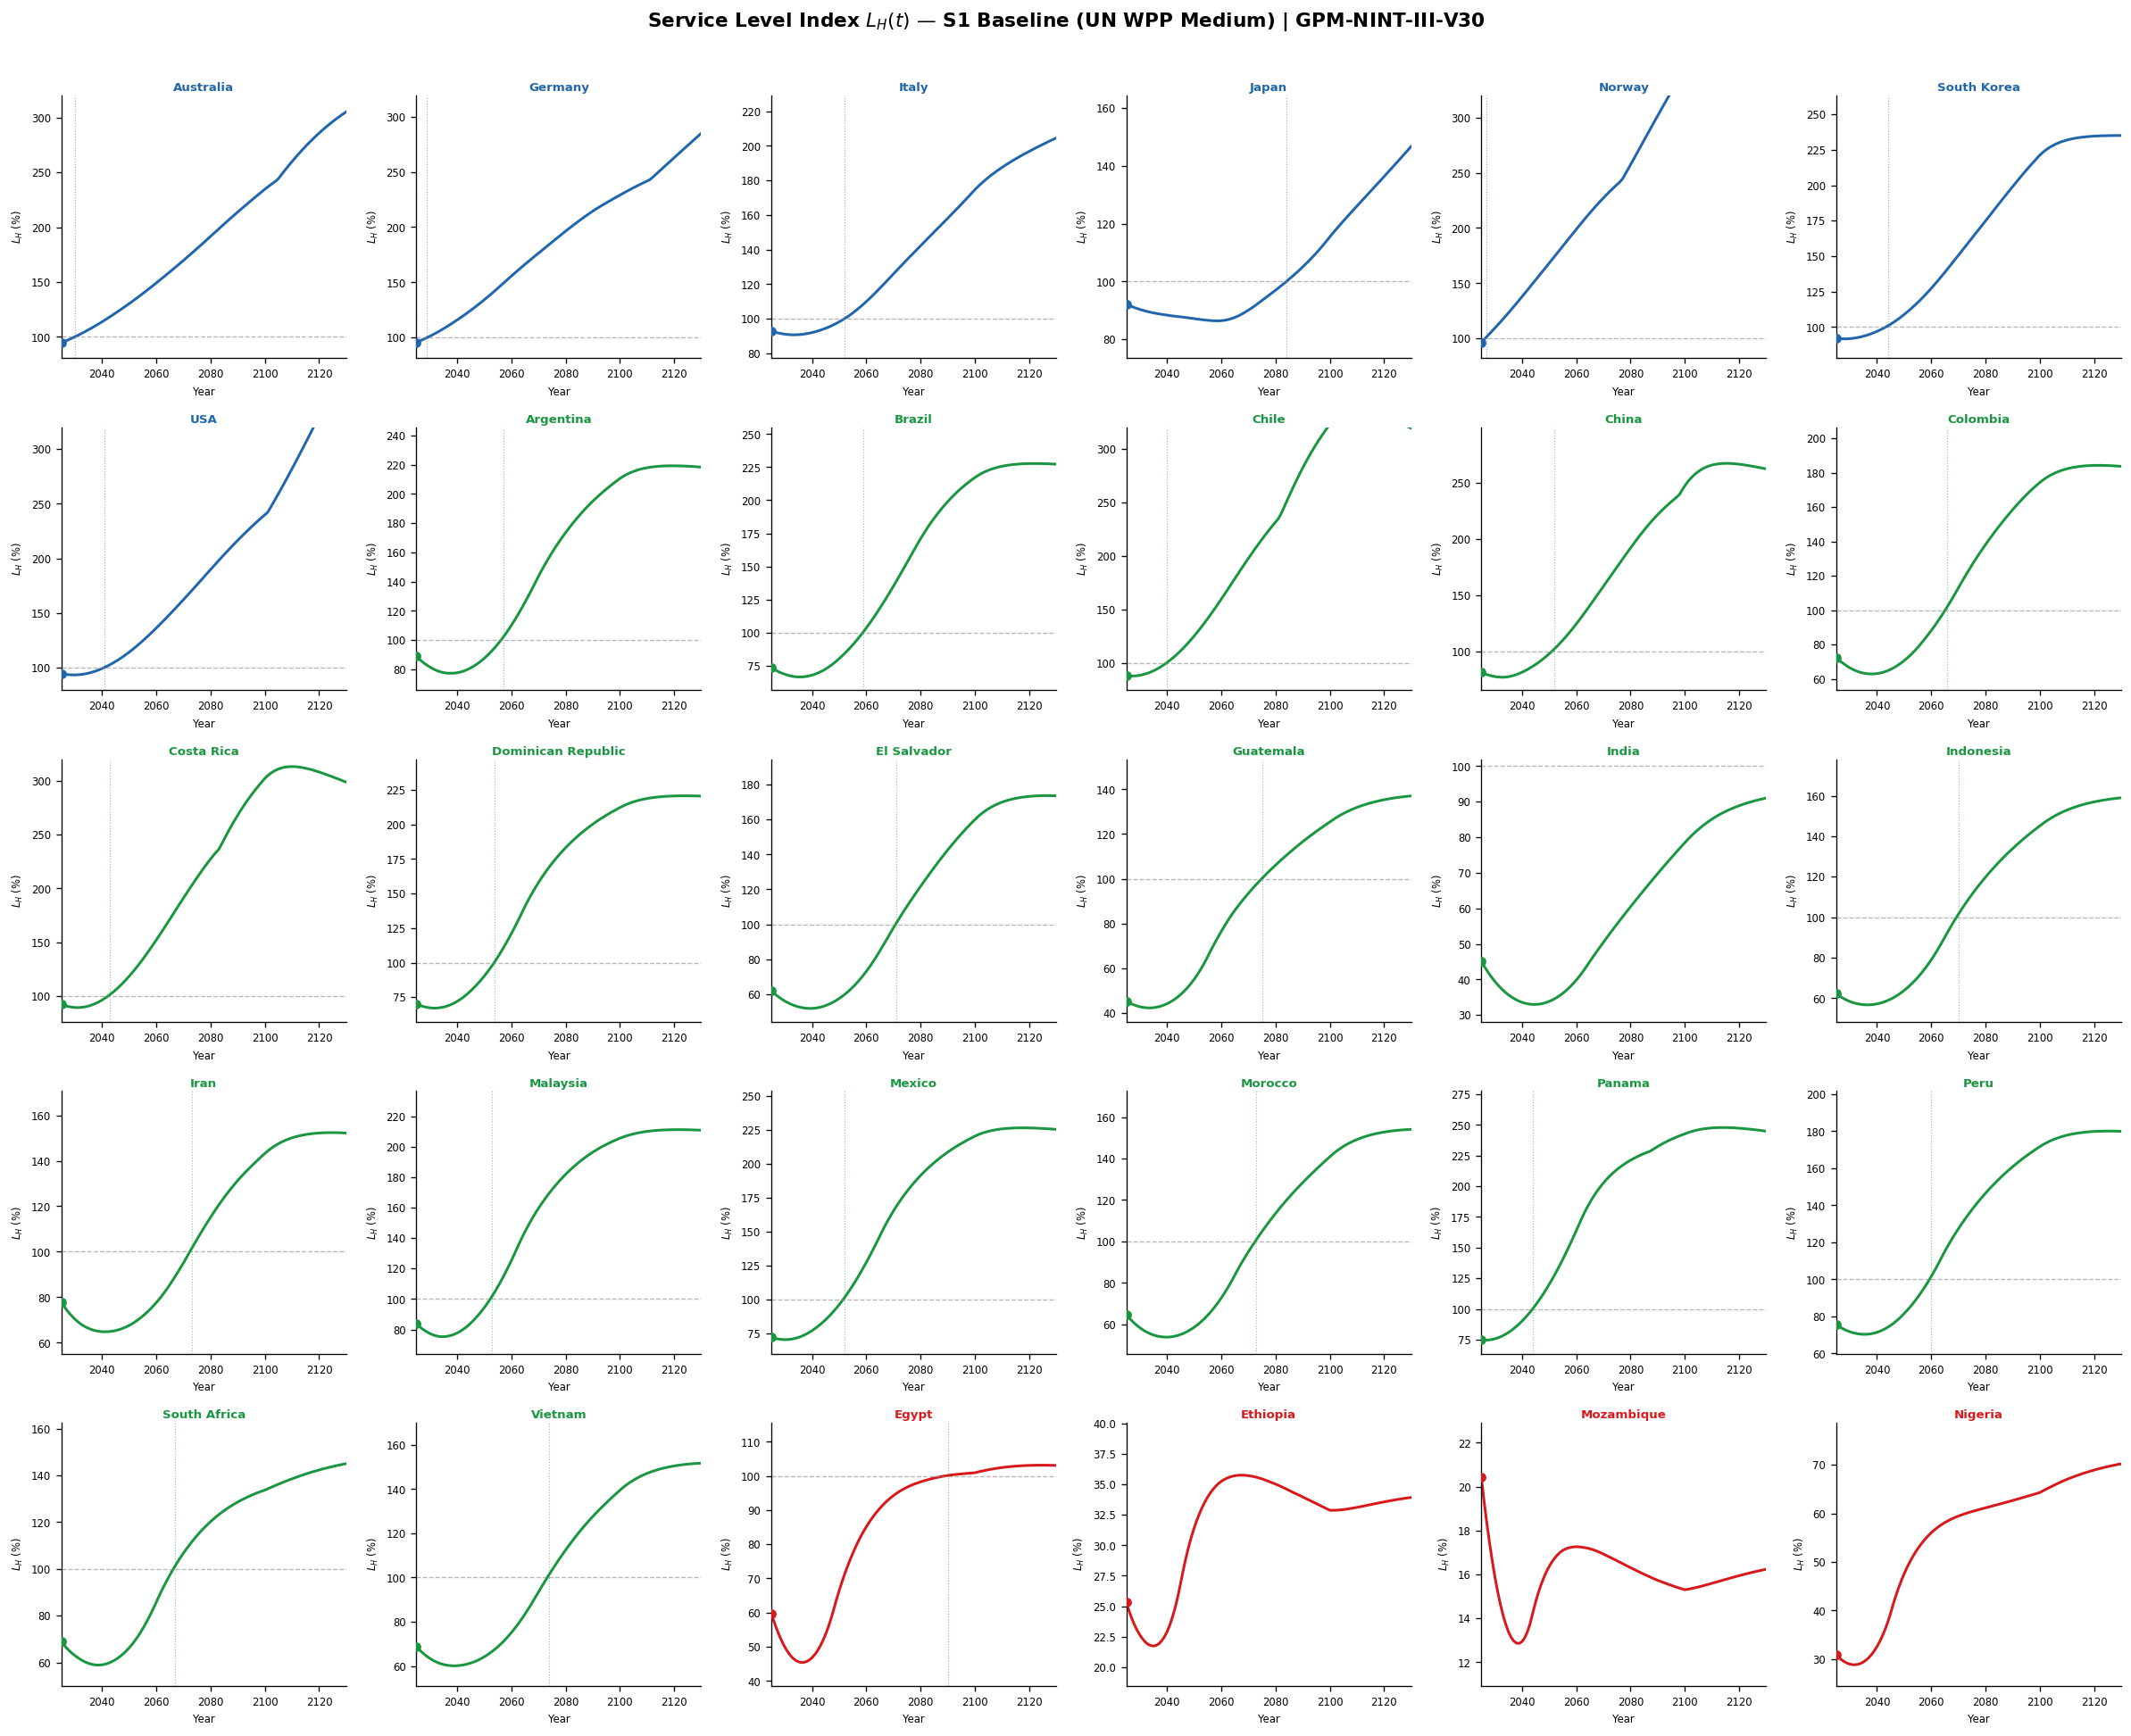

✓ Figure A saved — all 30 countries


In [9]:
# ── CELL 9: Figure A — Service Level L_H(t) All 30 Countries ─────────────────
import matplotlib.pyplot as plt, numpy as np

ARCH_COLORS = {'developed':'#2166ac','middle_income':'#1a9641','low_income':'#d7191c'}

country_order = (
    sorted([c for c,r in ALL_RESULTS.items() if r['archetype']=='developed']) +
    sorted([c for c,r in ALL_RESULTS.items() if r['archetype']=='middle_income']) +
    sorted([c for c,r in ALL_RESULTS.items() if r['archetype']=='low_income'])
)
print(f"Countries in figure: {len(country_order)}")

ncols = 6
nrows = -(-len(country_order) // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.2), squeeze=False)
fig.suptitle('Service Level Index $L_H(t)$ — S1 Baseline (UN WPP Medium) | GPM-NINT-III-V30',
             fontsize=13, fontweight='bold', y=1.01)

for idx, cname in enumerate(country_order):
    ax  = axes[idx // ncols][idx % ncols]
    res = ALL_RESULTS[cname]
    col = ARCH_COLORS[res['archetype']]
    y, LH = res['years'], res['L_H']
    ax.plot(y, LH, color=col, lw=1.8)
    ax.axhline(100, color='#888888', lw=0.8, ls='--', alpha=0.6)
    lh0_cal = res['PARAMS'].get('LH0', None)
    if lh0_cal is not None:
        ax.scatter([y[0]], [LH[0]], color=col, s=30, zorder=5)
    tinv = res['tinv']
    if tinv and y[0] <= tinv <= y[-1]:
        ax.axvline(tinv, color=col, lw=0.7, ls=':', alpha=0.5)
    ax.set_title(cname, fontsize=8, pad=3, color=col, fontweight='bold')
    ax.set_xlim(y[0], y[-1])
    ax.set_ylim(max(0, LH.min() * 0.85), min(LH.max() * 1.12, 320))
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('$L_H$ (%)', fontsize=7)

for idx in range(len(country_order), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('NINT_FigA_ServiceLevel_all30.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure A saved — all 30 countries")


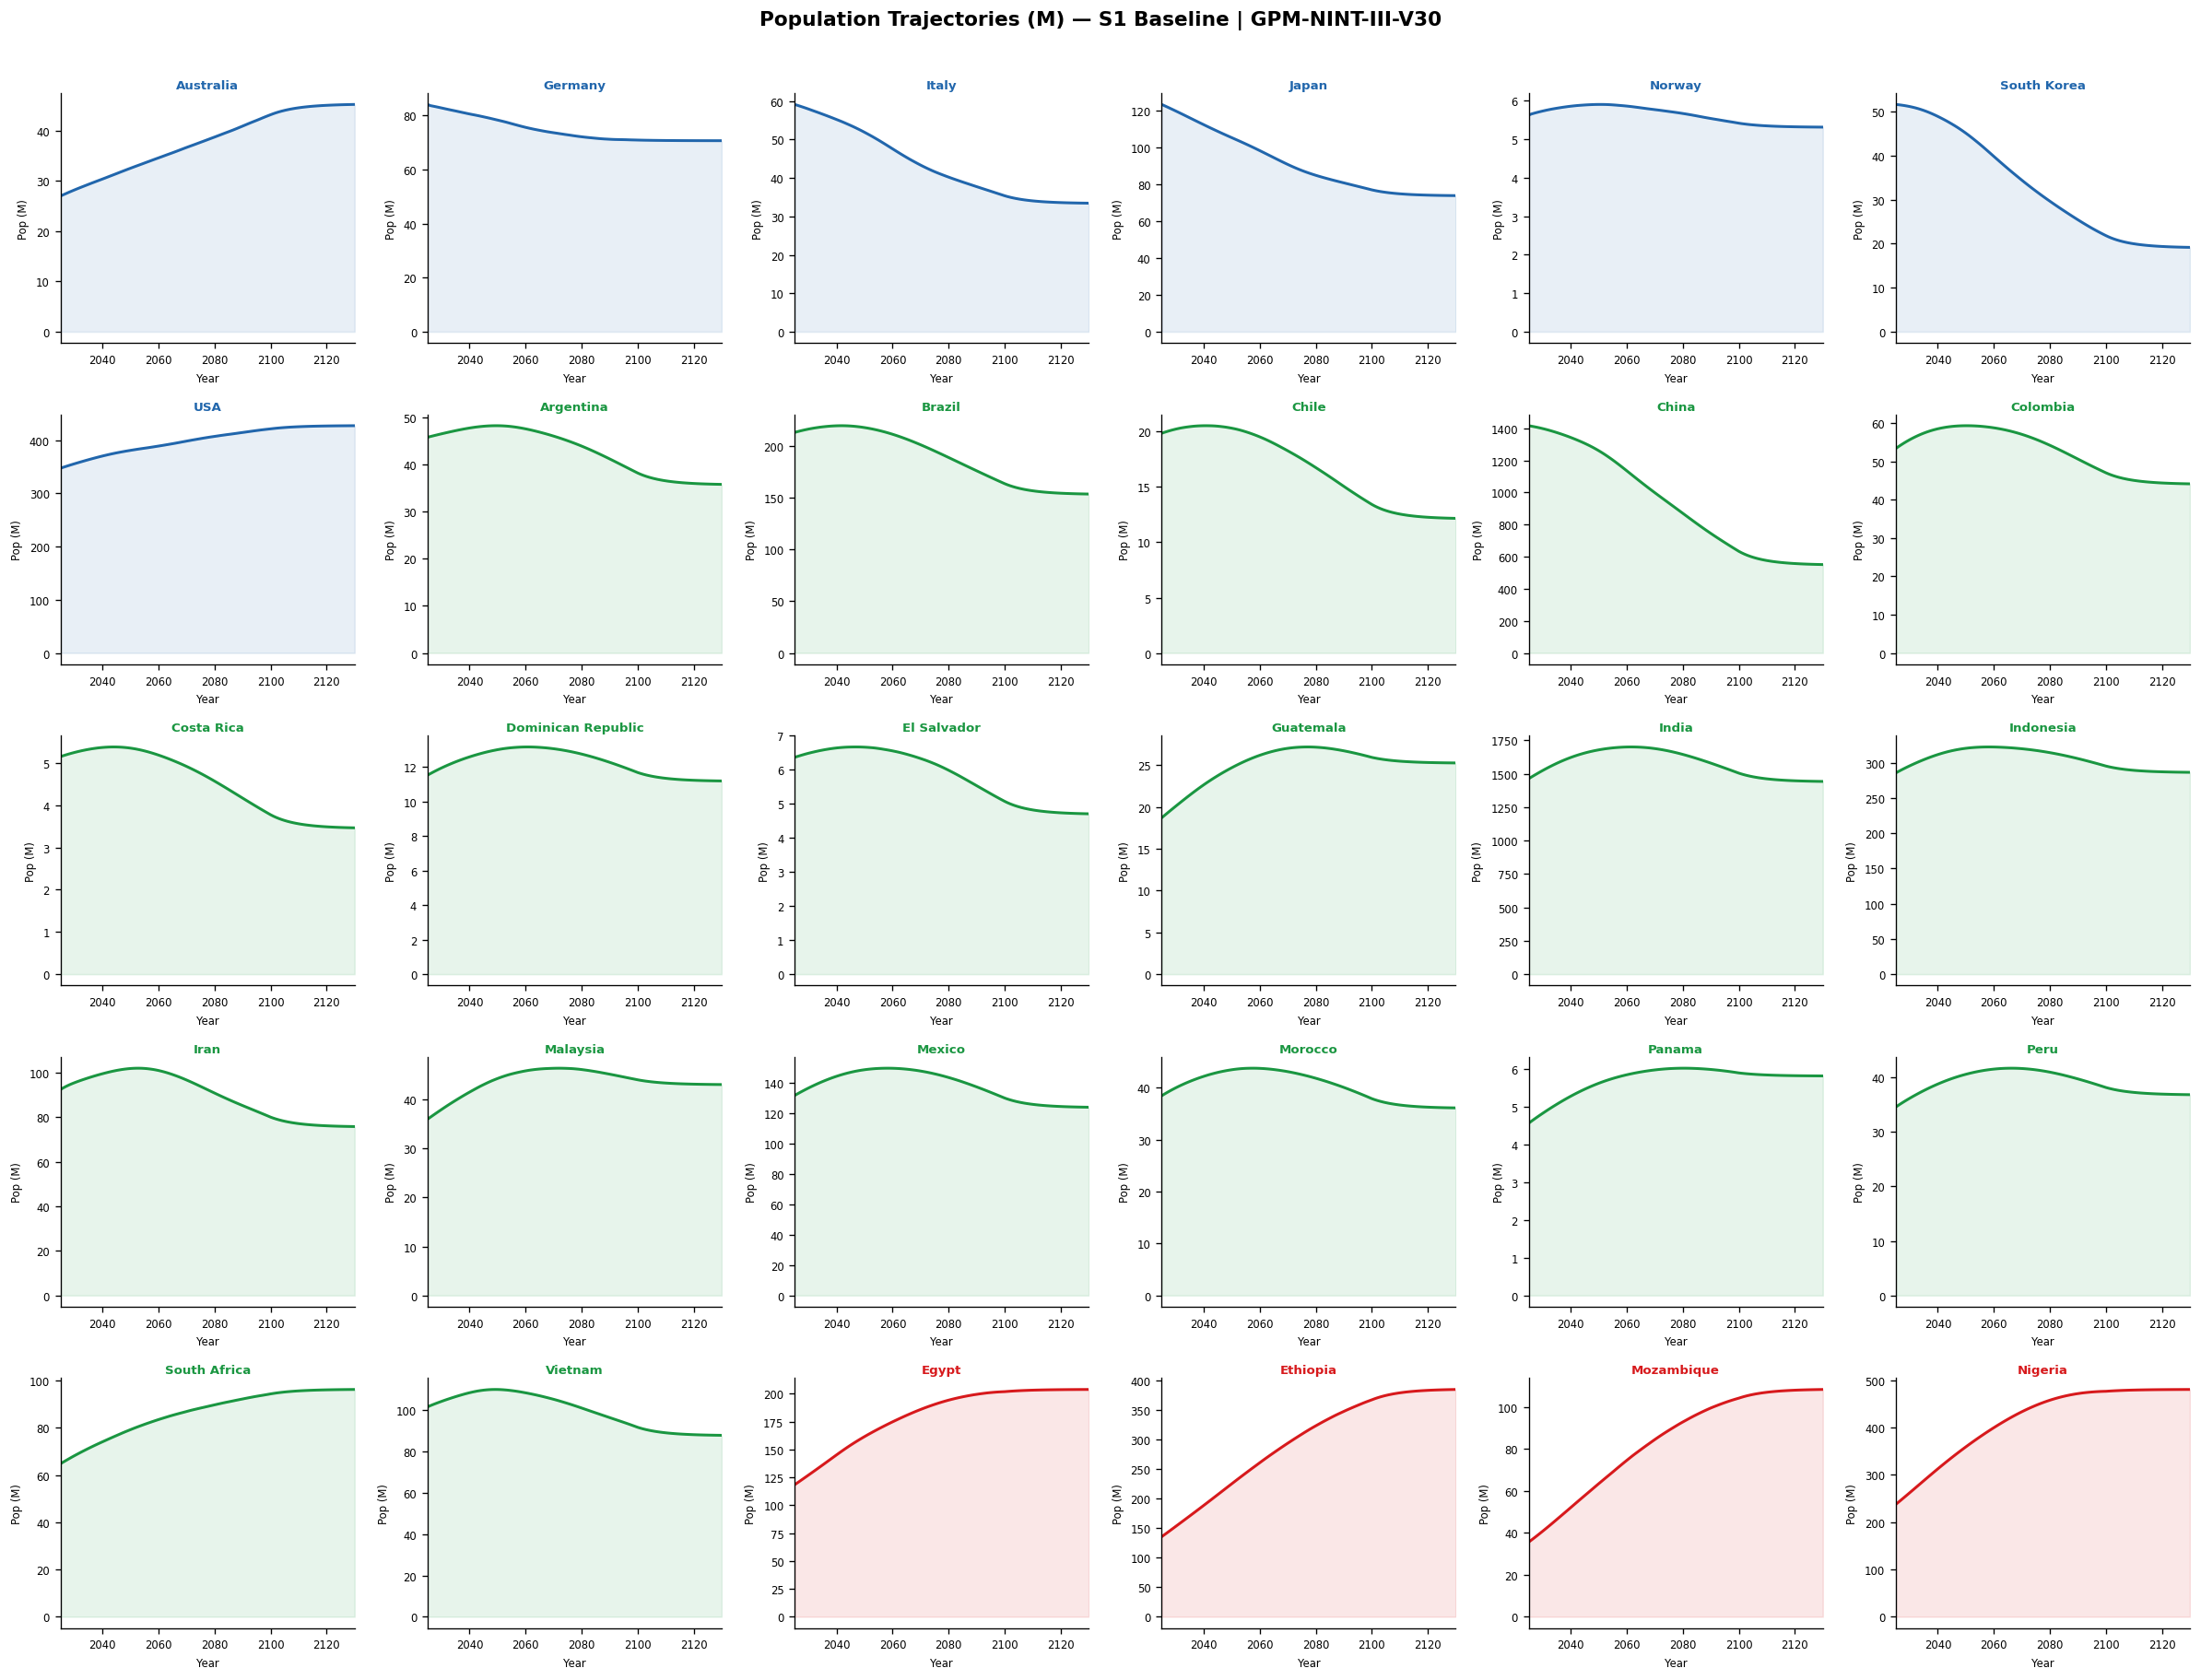

✓ Figure B saved — all 30 countries


In [10]:
# ── CELL 10: Figure B — Population Trajectories All 30 Countries ─────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.0), squeeze=False)
fig.suptitle('Population Trajectories (M) — S1 Baseline | GPM-NINT-III-V30',
             fontsize=13, fontweight='bold', y=1.01)

for idx, cname in enumerate(country_order):
    ax  = axes[idx // ncols][idx % ncols]
    res = ALL_RESULTS[cname]
    col = ARCH_COLORS[res['archetype']]
    y, pop = res['years'], res['population'] / 1e6
    ax.plot(y, pop, color=col, lw=1.8)
    ax.fill_between(y, pop, alpha=0.10, color=col)
    ax.set_title(cname, fontsize=8, pad=3, color=col, fontweight='bold')
    ax.set_xlim(y[0], y[-1])
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('Pop (M)', fontsize=7)

for idx in range(len(country_order), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('NINT_FigB_Population_all30.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure B saved — all 30 countries")


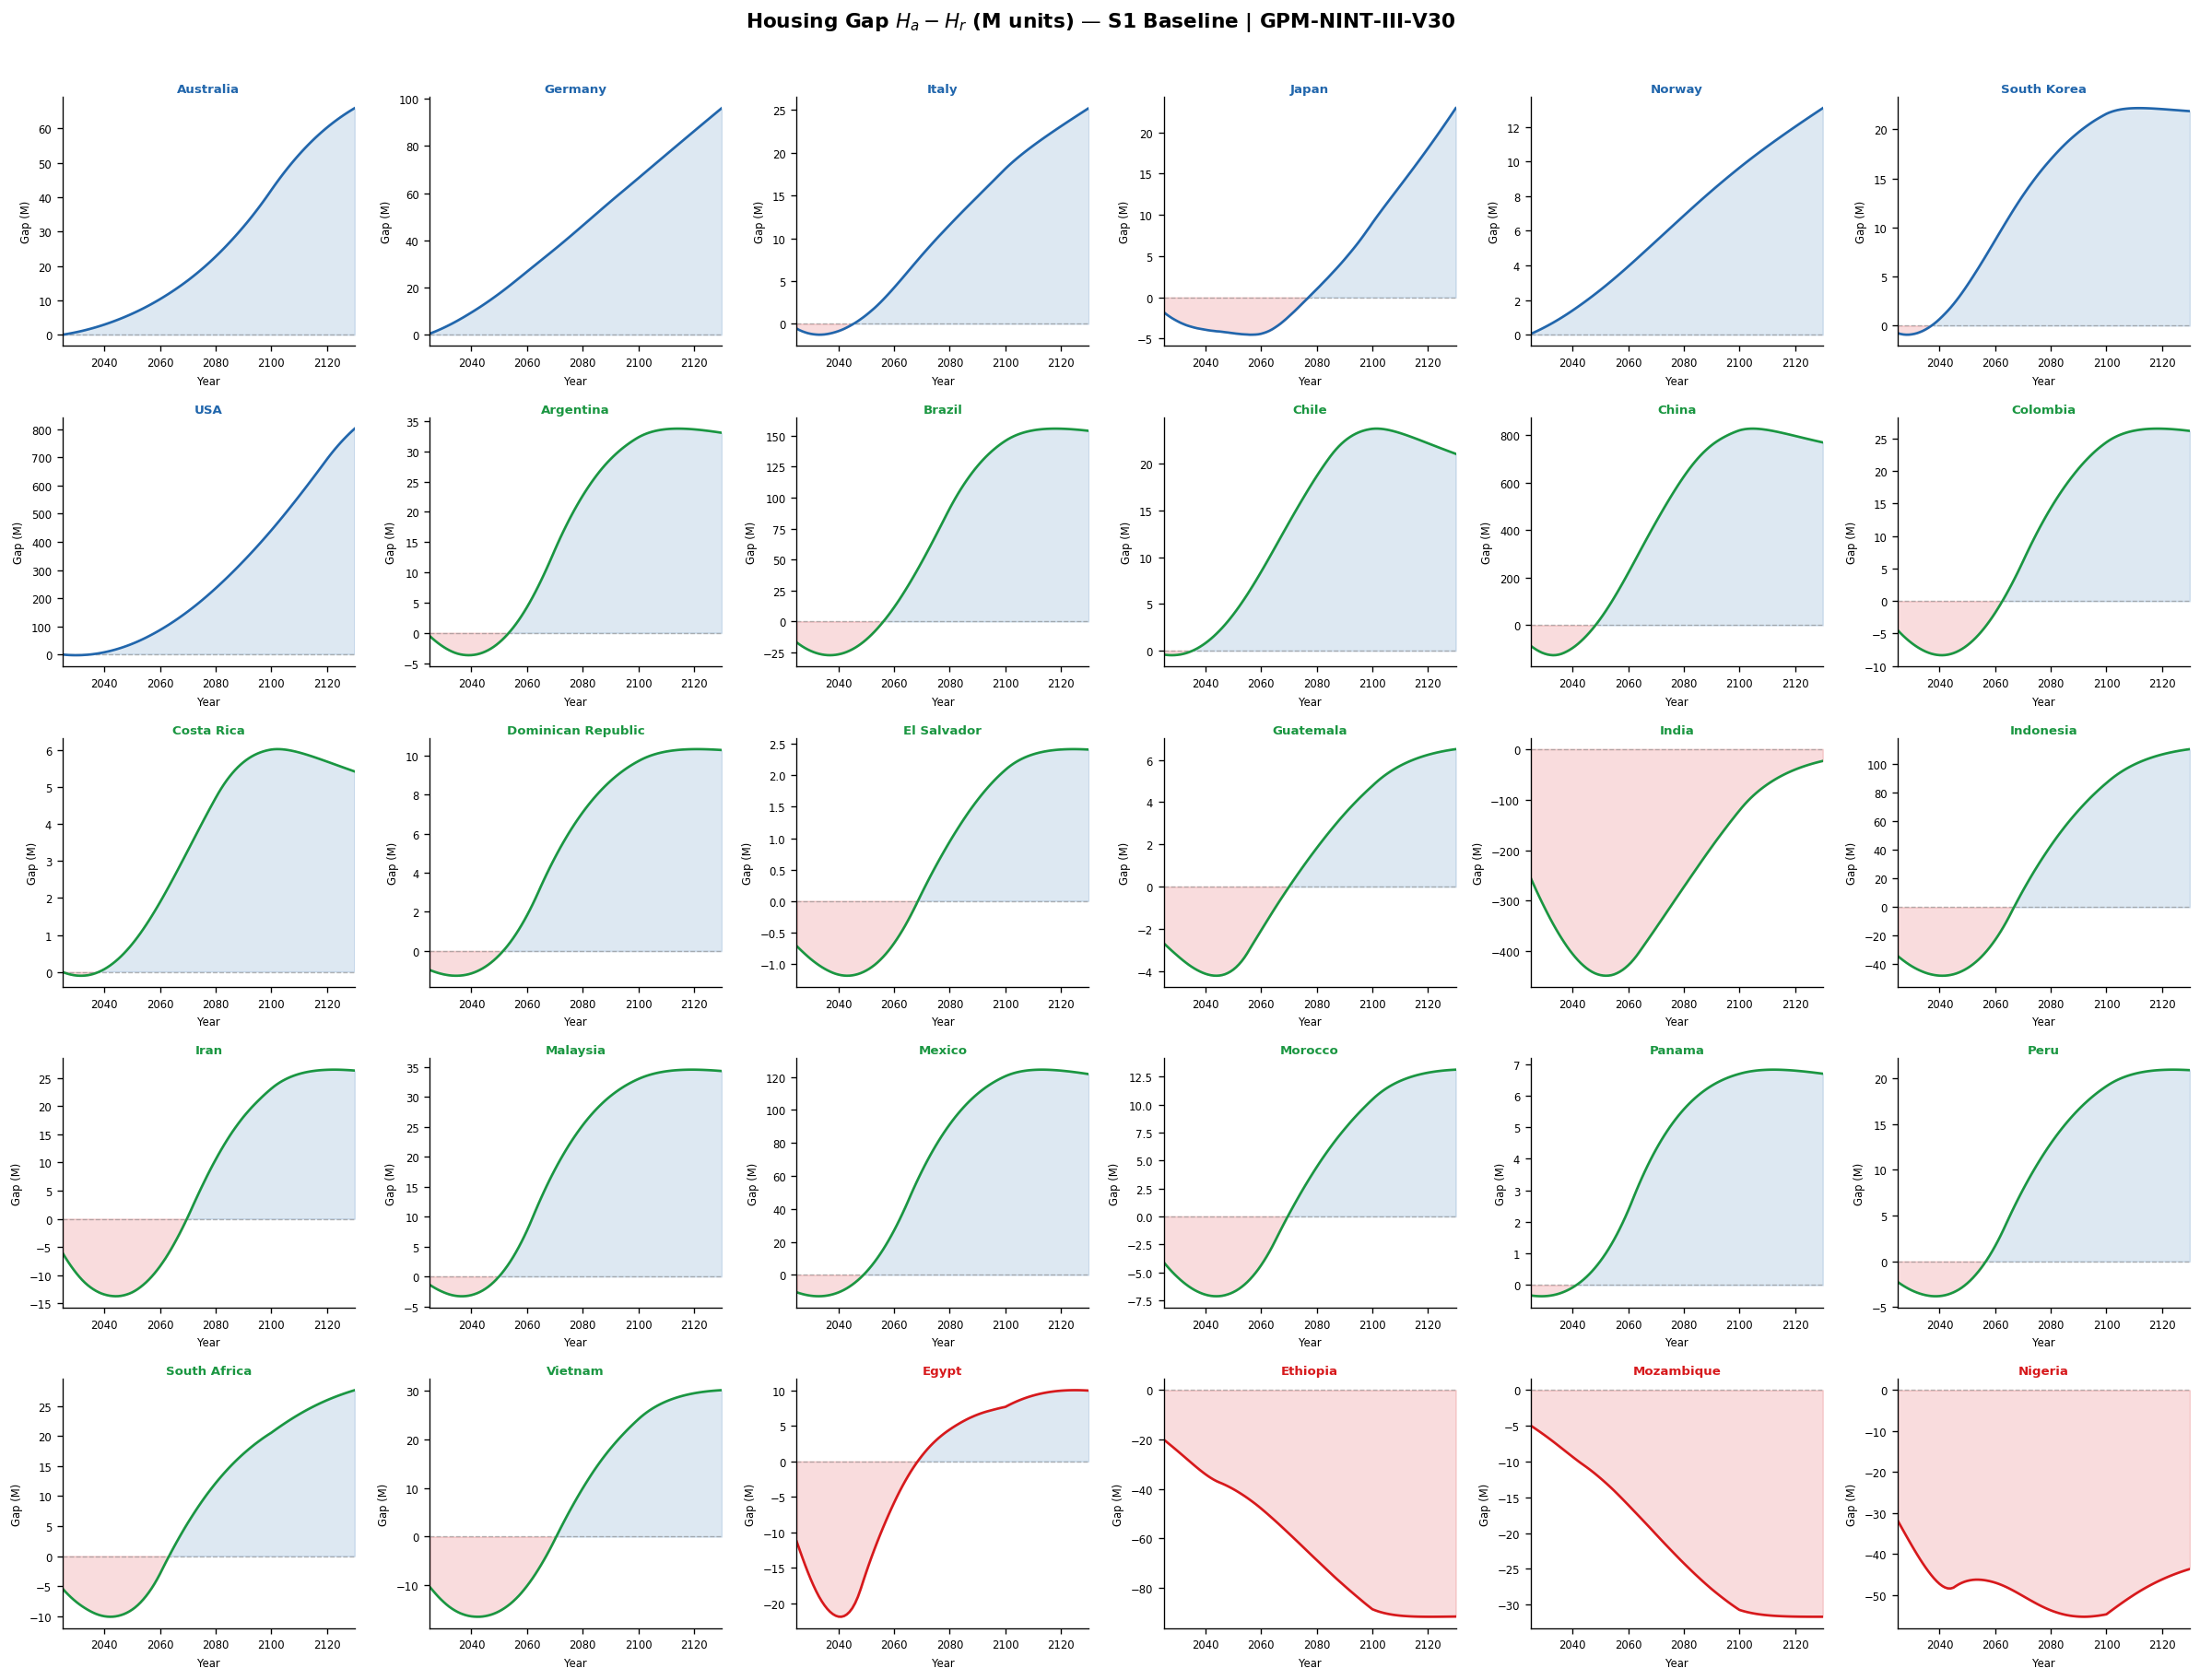

✓ Figure C saved — all 30 countries


In [11]:
# ── CELL 11: Figure C — Housing Gap (H_a − H_r) All 30 Countries ─────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.0), squeeze=False)
fig.suptitle('Housing Gap $H_a - H_r$ (M units) — S1 Baseline | GPM-NINT-III-V30',
             fontsize=13, fontweight='bold', y=1.01)

for idx, cname in enumerate(country_order):
    ax  = axes[idx // ncols][idx % ncols]
    res = ALL_RESULTS[cname]
    col = ARCH_COLORS[res['archetype']]
    y   = res['years']
    gap = (res['Ha'] - res['H_req']) / 1e6
    ax.axhline(0, color='#888888', lw=0.8, ls='--', alpha=0.6)
    ax.plot(y, gap, color=col, lw=1.6)
    ax.fill_between(y, gap, where=(gap >= 0), alpha=0.15, color='#2166ac')
    ax.fill_between(y, gap, where=(gap < 0),  alpha=0.15, color='#d7191c')
    ax.set_title(cname, fontsize=8, pad=3, color=col, fontweight='bold')
    ax.set_xlim(y[0], y[-1])
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('Gap (M)', fontsize=7)

for idx in range(len(country_order), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('NINT_FigC_HousingGap_all30.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure C saved — all 30 countries")


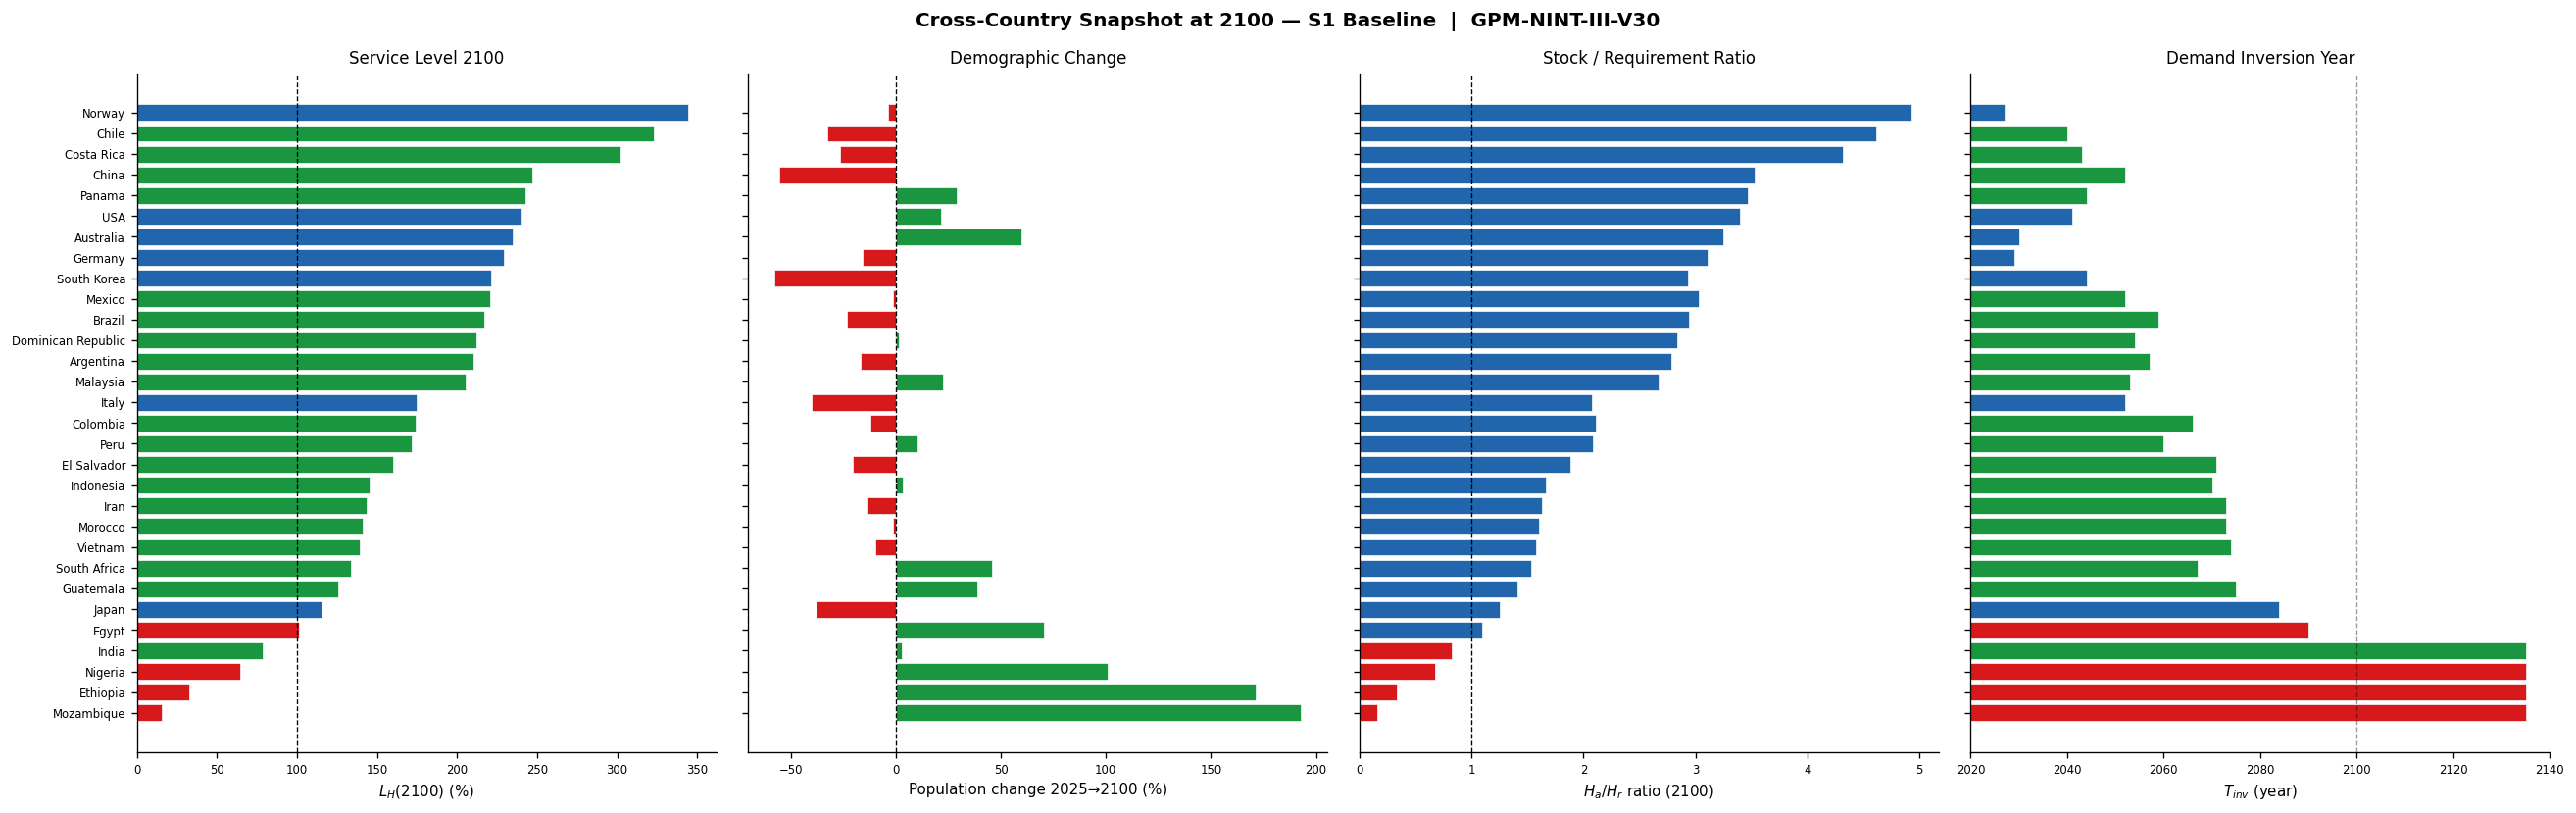

✓ Figure D saved


In [12]:
# ── CELL 12: Figure D — Cross-Country Comparison at 2100 ─────────────────────
#
# 4-panel bar chart:
#   (a) L_H(2100) sorted descending
#   (b) Population change 2025→2100 (%)
#   (c) H_a(2100) / H_r(2100) ratio
#   (d) T_inv (demand inversion year)

fig, axes = plt.subplots(1, 4, figsize=(22, 7))
fig.suptitle('Cross-Country Snapshot at 2100 — S1 Baseline  |  GPM-NINT-III-V30',
             fontsize=12, fontweight='bold')

cnames_sorted = summary_df['Country'].tolist()

colors_bar = [ARCH_COLORS[ALL_RESULTS[c]['archetype']] for c in cnames_sorted]

def get_val_at(cname, key, yr):
    res = ALL_RESULTS[cname]
    idx = np.searchsorted(res['years'], yr)
    return res[key][idx]

# ── Panel (a): L_H(2100)
ax = axes[0]
vals = [get_val_at(c, 'L_H', 2100) for c in cnames_sorted]
bars = ax.barh(cnames_sorted, vals, color=colors_bar, edgecolor='white', linewidth=0.4)
ax.axvline(100, color='k', lw=0.8, ls='--')
ax.set_xlabel('$L_H(2100)$ (%)', fontsize=9)
ax.set_title('Service Level 2100', fontsize=10)
ax.tick_params(labelsize=7)
ax.invert_yaxis()

# ── Panel (b): Population change 2025→2100
ax = axes[1]
vals = [((get_val_at(c,'population',2100) / get_val_at(c,'population',2025)) - 1)*100
        for c in cnames_sorted]
bar_cols = ['#d7191c' if v < 0 else '#1a9641' for v in vals]
ax.barh(cnames_sorted, vals, color=bar_cols, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Population change 2025→2100 (%)', fontsize=9)
ax.set_title('Demographic Change', fontsize=10)
ax.tick_params(labelsize=7, labelleft=False)
ax.invert_yaxis()

# ── Panel (c): Ha/Hr ratio at 2100
ax = axes[2]
vals = [get_val_at(c,'Ha',2100) / max(get_val_at(c,'H_req',2100), 1)
        for c in cnames_sorted]
bar_cols2 = ['#2166ac' if v > 1 else '#d7191c' for v in vals]
ax.barh(cnames_sorted, vals, color=bar_cols2, edgecolor='white', linewidth=0.4)
ax.axvline(1.0, color='k', lw=0.8, ls='--')
ax.set_xlabel('$H_a / H_r$ ratio (2100)', fontsize=9)
ax.set_title('Stock / Requirement Ratio', fontsize=10)
ax.tick_params(labelsize=7, labelleft=False)
ax.invert_yaxis()

# ── Panel (d): T_inv
ax = axes[3]
tinv_vals = []
for c in cnames_sorted:
    tv = ALL_RESULTS[c]['tinv']
    tinv_vals.append(tv if tv else 2135)   # 2135 = ">2130" placeholder
bar_col3 = [ARCH_COLORS[ALL_RESULTS[c]['archetype']] for c in cnames_sorted]
ax.barh(cnames_sorted, tinv_vals, color=bar_col3, edgecolor='white', linewidth=0.4)
ax.axvline(2100, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('$T_{inv}$ (year)', fontsize=9)
ax.set_title('Demand Inversion Year', fontsize=10)
ax.set_xlim(2020, 2140)
ax.tick_params(labelsize=7, labelleft=False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('NINT_FigD_CrossCountry2100.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure D saved")


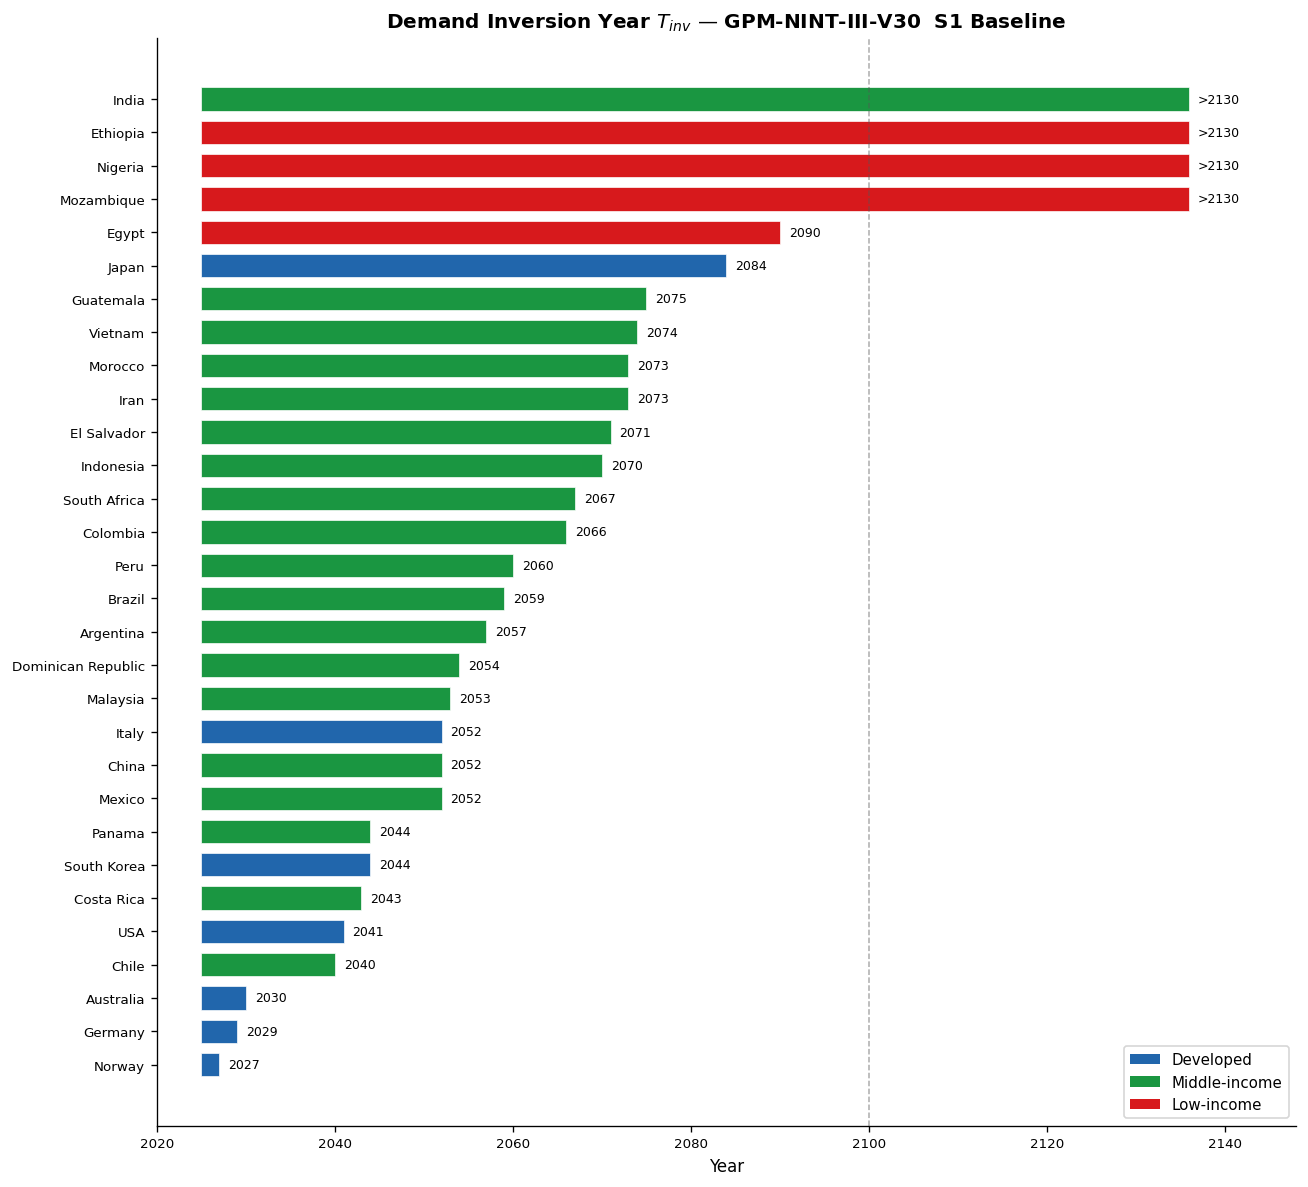

✓ Figure E saved — all 30 countries


In [13]:
# ── CELL 13: Figure E — Demand Inversion Year T_inv Ranked ──────────────────
# All 30 countries (Japan included with '>2130' label). Colour = archetype.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

ARCH_COLORS = {'developed':'#2166ac','middle_income':'#1a9641','low_income':'#d7191c'}

tinv_data = []
for c, res in ALL_RESULTS.items():
    tv   = res['tinv']
    arch = res['archetype']
    tinv_data.append({'Country': c, 'T_inv': tv if tv else 2136,
                      'label': str(tv) if tv else '>2130', 'archetype': arch})

tinv_df = pd.DataFrame(tinv_data).sort_values('T_inv').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 10))
ax.set_title('Demand Inversion Year $T_{inv}$ — GPM-NINT-III-V30  S1 Baseline',
             fontsize=12, fontweight='bold')

for _, row in tinv_df.iterrows():
    col = ARCH_COLORS[row['archetype']]
    ax.barh(row['Country'], row['T_inv'] - 2025, left=2025,
            color=col, edgecolor='white', linewidth=0.4, height=0.7)
    ax.text(row['T_inv'] + 1, row['Country'], row['label'], va='center', fontsize=7.5)

ax.axvline(2100, color='#555555', lw=0.9, ls='--', alpha=0.5)
ax.set_xlim(2020, 2148)
ax.set_xlabel('Year', fontsize=10)
ax.tick_params(labelsize=8)

legend_elements = [Patch(facecolor=ARCH_COLORS['developed'],    label='Developed'),
                   Patch(facecolor=ARCH_COLORS['middle_income'], label='Middle-income'),
                   Patch(facecolor=ARCH_COLORS['low_income'],    label='Low-income')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('NINT_FigE_Tinv_ranked_all30.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure E saved — all 30 countries")


In [14]:
# ── CELL 14: Export Master CSV (30 countries × 106 years × S1) ───────────────
import pandas as pd, numpy as np

frames = []
for cname, res in ALL_RESULTS.items():
    P   = res['PARAMS']
    n   = len(res['years'])
    nan_arr = np.full(n, np.nan)
    df = pd.DataFrame({
        #'Version':       'GPM-NINT-III-V30',
        'Country':        cname,
        'Archetype':      res['archetype'],
        'Scenario':       'S1_Baseline',
        'Year':           res['years'],
        'LH0_cal_pct':    P.get('LH0',  np.nan),
        'phi0_cal':       P.get('phi0', np.nan),
        'Population_M':   res['population'] / 1e6,
        'TFR':            res['tfr'],
        'GDP_trn_USD':    res['gdp']   / 1e12,
        'Debt_GDP_frac':  res['debt'],
        'Palma':          res.get('palma', nan_arr),
        'xi':             res.get('xi',    nan_arr),
        'H_r_M':          res['H_req']  / 1e6,
        'H_eff_M':        res['H_eff']  / 1e6,
        'H_avail_M':      res['Ha']     / 1e6,
        'H_usable_M':     res.get('H_usable', res['Ha'] * (1 - res['vacancy'])) / 1e6,
        'L_H_pct':        res['L_H'],
        'Vacancy_pct':    res['vacancy'] * 100,
        'Delta_pct':      res['delta']  * 100,
        'Invest_bn_USD':  res['invest'] / 1e9,
        'T_inv':          res['tinv'],
    })
    frames.append(df)

master_df = pd.concat(frames, ignore_index=True)
fname = 'GPM_NINT_III_V30_results_all30_S1.csv'
master_df.to_csv(fname, index=False)
print(f"✓ Master CSV exported: {fname}")
print(f"  Rows: {len(master_df):,}  |  Columns: {len(master_df.columns)}")
master_df


✓ Master CSV exported: GPM_NINT_III_V30_results_all30_S1.csv
  Rows: 3,180  |  Columns: 21


,Country,Archetype,Scenario,Year,LH0_cal_pct,phi0_cal,Population_M,TFR,GDP_trn_USD,Debt_GDP_frac,...,xi,H_r_M,H_eff_M,H_avail_M,H_usable_M,L_H_pct,Vacancy_pct,Delta_pct,Invest_bn_USD,T_inv
0,Japan,developed,S1_Baseline,2025,92,0.97,123.103480,1.22500,4.210000,2.550000,...,0.970000,59.843161,58.047866,58.047866,55.145473,92.150000,5.000000,1.641856,0.000000,2084
1,Japan,developed,S1_Baseline,2026,92,0.97,122.427730,1.23150,4.293067,2.485273,...,0.970695,59.588407,57.842163,57.527116,54.663294,91.734779,4.978213,1.645381,7.512868,2084
2,Japan,developed,S1_Baseline,2027,92,0.97,121.732340,1.23960,4.376600,2.423254,...,0.971372,59.307864,57.609994,57.011939,54.185016,91.362279,4.958476,1.648157,7.659050,2084
3,Japan,developed,S1_Baseline,2028,92,0.97,121.024350,1.24610,4.460518,2.363843,...,0.972030,59.021337,57.370503,56.502518,53.711586,91.003677,4.939482,1.650238,7.805907,2084
4,Japan,developed,S1_Baseline,2029,92,0.97,120.308091,1.25380,4.544681,2.306985,...,0.972668,58.713891,57.109120,55.999012,53.242602,90.681440,4.922247,1.651675,7.953192,2084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,Egypt,low_income,S1_Baseline,2126,60,0.63,203.810167,1.72604,1.900000,0.313557,...,0.836709,79.149608,66.225167,89.180602,81.630331,103.134221,8.466271,2.313904,76.758856,2090
3176,Egypt,low_income,S1_Baseline,2127,60,0.63,203.823461,1.72168,1.900000,0.314980,...,0.836698,79.164835,66.237099,89.188711,81.638825,103.125112,8.465069,2.313904,76.572636,2090
3177,Egypt,low_income,S1_Baseline,2128,60,0.63,203.835426,1.71732,1.900000,0.316374,...,0.836689,79.179548,66.248681,89.191493,81.643097,103.111345,8.463135,2.313904,76.390140,2090
3178,Egypt,low_income,S1_Baseline,2129,60,0.63,203.846196,1.71296,1.900000,0.317741,...,0.836681,79.193797,66.259947,89.189236,81.643376,103.093144,8.460505,2.313904,76.211294,2090


---
## Section 5.1 — Publication Figures (Nature Sustainability)

Cells 15–18 produce Table 3 and Figures 3a–3c for manuscript Section 5.1.
Japan is excluded from Figures 3a–3c but retained in Table 3 with a mechanism note.
All figures: no title, panel labels (a/b/c/d), double-column width (183 mm), 300 DPI PDF.


In [15]:

# ── Nature Sustainability style constants ─────────────────────────────────────
import matplotlib as mpl
NS_FONT   = 'Arial'          # NS preferred sans-serif
NS_SMALL  = 7                # axis tick labels
NS_MED    = 8                # axis labels, legend
NS_LARGE  = 9                # panel labels (a,b,c)
NS_DPI    = 300              # submission DPI
NS_FMT    = 'pdf'            # vector format for submission; png for preview
NS_W1     = 89 / 25.4        # single-column width (mm → inches)
NS_W2     = 183 / 25.4       # double-column width
NS_CMAP   = {'developed': '#2166ac',
             'middle_income': '#1a9641',
             'low_income': '#d7191c'}

mpl.rcParams.update({
    'font.family':       NS_FONT,
    'font.size':         NS_MED,
    'axes.labelsize':    NS_MED,
    'axes.titlesize':    NS_MED,
    'xtick.labelsize':   NS_SMALL,
    'ytick.labelsize':   NS_SMALL,
    'legend.fontsize':   NS_SMALL,
    'lines.linewidth':   0.8,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype':      42,   # editable fonts in Illustrator
    'svg.fonttype':      'none',
})
EXCL = {'Japan'}   # excluded from main figures; retained in Table 3

# ── CELL 15: Table 3 — Section 5.1 Summary Statistics (all 29 countries) ─────
#
# Columns (Nature Sustainability Table 3):
#   Country | Archetype | d0 | phi0 | T_inv | L_H_trough | Year_trough |
#   L_H(2050) | L_H(2100) | L_H(2130) | Pop_change_2025_2100
#
# Japan is INCLUDED in the table (note in caption explains >2130 mechanism).

rows3 = []
for cname, res in ALL_RESULTS.items():
    y   = res['years']
    LH  = res['L_H']
    pop = res['population']
    P   = res['PARAMS']

    def lh_at(yr):
        idx = np.searchsorted(y, yr)
        return float(LH[min(idx, len(LH)-1)])

    def pop_at(yr):
        idx = np.searchsorted(y, yr)
        return float(pop[min(idx, len(pop)-1)])

    tinv = res['tinv']

    # Trough: minimum L_H over full horizon
    trough_val  = float(np.min(LH))
    trough_idx  = int(np.argmin(LH))
    trough_year = int(y[trough_idx])

    d0   = round(1 - P.get('LH0', 100)/100, 2)
    phi0 = round(P.get('phi0', float('nan')), 2)

    dpop = round((pop_at(2100)/max(pop_at(2025),1) - 1)*100, 1)

    rows3.append({
        'Country':         cname,
        'Archetype':       res['archetype'].replace('_',' ').title(),
        'd₀':              f"{d0:.2f}",
        'φ₀':              f"{phi0:.2f}",
        'T_inv':           str(tinv) if tinv else '>2130',
        'L_H trough (%)':  f"{trough_val:.1f}",
        'Trough year':     trough_year,
        'L_H(2050) %':     f"{lh_at(2050):.1f}",
        'L_H(2100) %':     f"{lh_at(2100):.1f}",
        'L_H(2130) %':     f"{lh_at(2130):.1f}",
        'ΔPop 2025–2100 %': f"{dpop:+.1f}",
    })

table3 = pd.DataFrame(rows3)

# Sort: archetype order then T_inv
arch_order = {'Developed':1,'Middle Income':2,'Low Income':3}
table3['_ao'] = table3['Archetype'].map(arch_order)

def tinv_sort(v):
    try: return int(v)
    except: return 9999
table3['_ts'] = table3['T_inv'].apply(tinv_sort)
table3 = table3.sort_values(['_ao','_ts']).drop(columns=['_ao','_ts']).reset_index(drop=True)

# Display
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 35)
print()
print("TABLE 3 — Demand inversion and service-level statistics, S1 baseline (all 29 countries)")
print("─"*170)
print(table3.to_string(index=False))
print("─"*170)
print("Notes:")
print("  d₀ = baseline housing deficit share; φ₀ = availability factor (Eq. 8).")
print("  T_inv = demand inversion year (Eq. 25); '>2130' = no inversion within projection horizon.")
print("  Japan '>2130' reflects debt-constrained stock decay (see main text); not aggregate surplus.")
print("  L_H trough = minimum service level reached before inversion.")
print("  ΔPop = population change 2025–2100 under UN WPP 2024 medium variant.")
table3



TABLE 3 — Demand inversion and service-level statistics, S1 baseline (all 29 countries)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
           Country     Archetype   d₀   φ₀ T_inv L_H trough (%)  Trough year L_H(2050) % L_H(2100) % L_H(2130) % ΔPop 2025–2100 %
            Norway     Developed 0.03 1.02  2027           96.5         2025       168.1       344.6       450.1             -3.7
           Germany     Developed 0.04 1.01  2029           95.5         2025       134.1       229.0       285.0            -15.7
         Australia     Developed 0.05 1.00  2030           94.7         2025       130.3       234.6       305.1            +59.9
               USA     Developed 0.05 1.00  2041           93.3         2030       114.1       240.0       370.9            +21.3
       South Korea     Developed 0.08 0.97  2044           91.7         2028       108.8  

,Country,Archetype,d₀,φ₀,T_inv,L_H trough (%),Trough year,L_H(2050) %,L_H(2100) %,L_H(2130) %,ΔPop 2025–2100 %
0,Norway,Developed,0.03,1.02,2027,96.5,2025,168.1,344.6,450.1,-3.7
1,Germany,Developed,0.04,1.01,2029,95.5,2025,134.1,229.0,285.0,-15.7
2,Australia,Developed,0.05,1.00,2030,94.7,2025,130.3,234.6,305.1,+59.9
3,USA,Developed,0.05,1.00,2041,93.3,2030,114.1,240.0,370.9,+21.3
4,South Korea,Developed,0.08,0.97,2044,91.7,2028,108.8,221.2,235.1,-57.7
5,Italy,Developed,0.07,0.98,2052,90.7,2033,98.2,174.6,204.6,-40.2
6,Japan,Developed,0.08,0.97,2084,86.4,2059,87.2,115.4,146.8,-37.6
7,Chile,Middle Income,0.10,0.95,2040,87.9,2027,125.2,322.7,319.2,-32.4
8,Costa Rica,Middle Income,0.05,1.00,2043,89.3,2031,118.4,302.2,298.7,-26.7
9,Panama,Middle Income,0.25,0.79,2044,74.5,2026,119.9,242.8,245.0,+29.2


Saved PDF and PNG


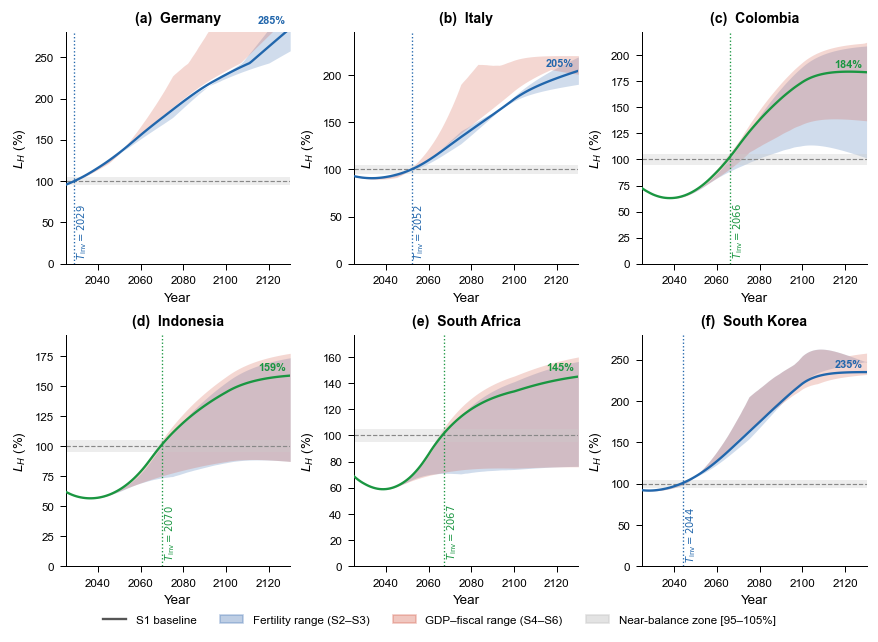

In [16]:
# ── CELL: Figure 1 — Service Level Trajectories L_H(t) for Six Countries ─────
#
# Reproduces manuscript Figure 1 using V27 results (_ALL_RESULTS_BY_SC).
# Six panels: Germany, Italy, Colombia, Brazil, South Africa, Japan.
# S1 baseline (solid line), fertility band S2–S3 (blue), GDP band S4–S6 (red).
# Run after Cell 7. Saves NS_Fig4_Archetypes.pdf and .png.

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams.update({
    'font.family':      'Arial',
    'font.size':         8,
    'axes.labelsize':    8,
    'axes.titlesize':    8.5,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   7,
    'lines.linewidth':   1.2,
    'axes.linewidth':    0.6,
    'pdf.fonttype':      42,
})

NS_W2  = 183 / 25.4   # double-column width (inches)
NS_DPI = 300

# ── Countries to plot and their display config ────────────────────────────────
PANELS = [
    {'name': 'Germany',      'panel': 'a', 'arch': 'developed',     'row': 0, 'col': 0},
    {'name': 'Italy',        'panel': 'b', 'arch': 'developed',     'row': 0, 'col': 1},
    {'name': 'Colombia',     'panel': 'c', 'arch': 'middle_income', 'row': 0, 'col': 2},
    {'name': 'Indonesia',    'panel': 'd', 'arch': 'middle_income', 'row': 1, 'col': 0},
    {'name': 'South Africa', 'panel': 'e', 'arch': 'middle_income', 'row': 1, 'col': 1},
    {'name': 'South Korea',        'panel': 'f', 'arch': 'developed',     'row': 1, 'col': 2},
]

ARCH_COLOR = {
    'developed':     '#2166ac',   # blue  — HI
    'middle_income': '#1a9641',   # green — MI
    'low_income':    '#d7191c',   # red   — LI
}

FERTIL_SCENARIOS = ['S2', 'S3']   # fertility band (blue)
GDP_SCENARIOS    = ['S4', 'S5', 'S6']   # GDP/fiscal band (red)

fig, axes = plt.subplots(2, 3, figsize=(NS_W2, NS_W2 * 0.7),
                         constrained_layout=True)

for cfg in PANELS:
    cname = cfg['name']
    ax    = axes[cfg['row'], cfg['col']]
    color = ARCH_COLOR[cfg['arch']]

    # ── Extract data ──────────────────────────────────────────────────────────
    sc_dict = _ALL_RESULTS_BY_SC.get(cname, {})
    if not sc_dict:
        ax.set_title(f"({cfg['panel']}) {cname} — no data", fontsize=8)
        continue

    # Reference: S1
    r_s1  = sc_dict.get('S1', {})
    years = np.array(r_s1.get('years', []))
    LH_s1 = np.array(r_s1.get('L_H',  []))
    tinv  = r_s1.get('tinv', None)

    if len(years) == 0:
        ax.set_title(f"({cfg['panel']}) {cname} — empty", fontsize=8)
        continue

    # Fertility band: S2–S3 envelope
    fert_vals = []
    for sid in FERTIL_SCENARIOS:
        r = sc_dict.get(sid, {})
        if 'L_H' in r:
            fert_vals.append(np.array(r['L_H']))
    if fert_vals:
        fert_lo = np.min(fert_vals, axis=0)
        fert_hi = np.max(fert_vals, axis=0)
        ax.fill_between(years, fert_lo, fert_hi,
                        color='#4575b4', alpha=0.25, lw=0, label='Fertility S2–S3')

    # GDP/fiscal band: S4–S6 envelope
    gdp_vals = []
    for sid in GDP_SCENARIOS:
        r = sc_dict.get(sid, {})
        if 'L_H' in r:
            gdp_vals.append(np.array(r['L_H']))
    if gdp_vals:
        gdp_lo = np.min(gdp_vals, axis=0)
        gdp_hi = np.max(gdp_vals, axis=0)
        ax.fill_between(years, gdp_lo, gdp_hi,
                        color='#d6604d', alpha=0.25, lw=0, label='GDP S4–S6')

    # S1 baseline
    ax.plot(years, LH_s1, color=color, lw=1.4, zorder=4, label='S1 baseline')

    # Near-balance zone [95–105%]
    ax.axhspan(95, 105, color='#cccccc', alpha=0.35, lw=0, zorder=1)
    ax.axhline(100, color='#888888', lw=0.7, ls='--', zorder=2)

    # T_inv vertical dotted line
    if tinv and tinv <= years[-1]:
        ax.axvline(tinv, color=color, lw=0.8, ls=':', zorder=3)
        ax.text(tinv + 0.5, ax.get_ylim()[0] + 3 if ax.get_ylim()[0] < 10 else 5,
                f'$T_{{\\mathrm{{inv}}}}={tinv}$',
                color=color, fontsize=6, rotation=90, va='bottom', ha='left')

    # Final L_H label
    LH_end = float(LH_s1[-1])
    ax.text(years[-1] - 2, LH_end + 3, f'{LH_end:.0f}%',
            color=color, fontsize=6.5, ha='right', va='bottom', fontweight='bold')

    # Axes formatting
    ax.set_xlim(years[0], years[-1])
    ax.set_ylim(0, min(LH_s1.max() * 1.15 + 10, 280))
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('$L_H$ (%)', fontsize=8)
    ax.set_title(f'({cfg["panel"]})  {cname}', fontsize=8.5, fontweight='bold')
    #ax.set_title(f'\\textbf{{({cfg["panel"]})}}\\; {cname}', fontsize=8.5,
                 #fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
leg_handles = [
    plt.Line2D([0], [0], color='#555555', lw=1.4,             label='S1 baseline'),
    mpatches.Patch(color='#4575b4', alpha=0.35,                label='Fertility range (S2–S3)'),
    mpatches.Patch(color='#d6604d', alpha=0.35,                label='GDP–fiscal range (S4–S6)'),
    mpatches.Patch(color='#cccccc', alpha=0.55,                label='Near-balance zone [95–105%]'),
]
fig.legend(handles=leg_handles, loc='lower center',
           ncol=4, fontsize=7, frameon=False,
           bbox_to_anchor=(0.5, -0.04))



# ── Save ──────────────────────────────────────────────────────────────────────
fig.savefig('NS_Fig4_Archetypes.pdf', dpi=NS_DPI, bbox_inches='tight')
fig.savefig('NS_Fig4_Archetypes.png', dpi=NS_DPI, bbox_inches='tight')

print('Saved PDF and PNG')
plt.show()


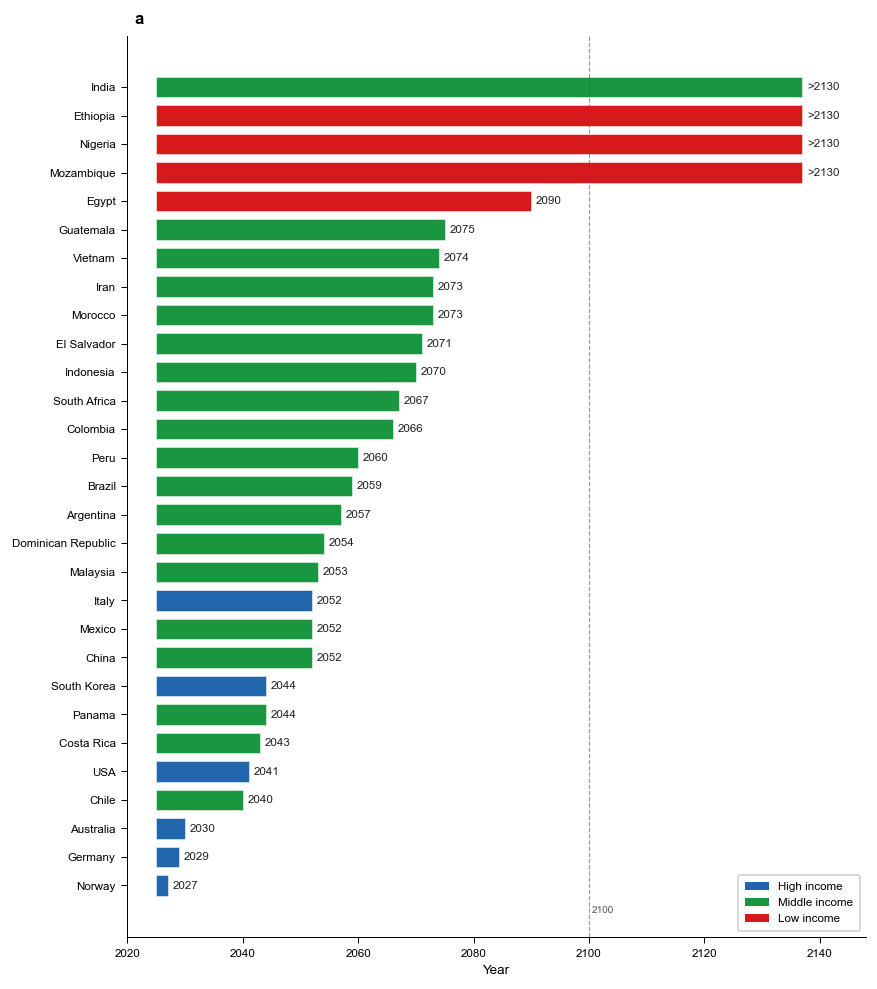

✓ Figure 3a saved → NS_Fig3a_Tinv_ranked.pdf


In [17]:

# ── Nature Sustainability style constants ─────────────────────────────────────
import matplotlib as mpl
NS_FONT   = 'Arial'          # NS preferred sans-serif
NS_SMALL  = 7                # axis tick labels
NS_MED    = 8                # axis labels, legend
NS_LARGE  = 9                # panel labels (a,b,c)
NS_DPI    = 300              # submission DPI
NS_FMT    = 'pdf'            # vector format for submission; png for preview
NS_W1     = 89 / 25.4        # single-column width (mm → inches)
NS_W2     = 183 / 25.4       # double-column width
NS_CMAP   = {'developed': '#2166ac',
             'middle_income': '#1a9641',
             'low_income': '#d7191c'}

mpl.rcParams.update({
    'font.family':       NS_FONT,
    'font.size':         NS_MED,
    'axes.labelsize':    NS_MED,
    'axes.titlesize':    NS_MED,
    'xtick.labelsize':   NS_SMALL,
    'ytick.labelsize':   NS_SMALL,
    'legend.fontsize':   NS_SMALL,
    'lines.linewidth':   0.8,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype':      42,   # editable fonts in Illustrator
    'svg.fonttype':      'none',
})
EXCL = {'Japan'}   # excluded from main figures; retained in Table 3

# ── CELL 16: Figure 3a — Demand Inversion Year T_inv (Section 5.1) ───────────
#
# Nature Sustainability specs:
#   • Double-column width (183 mm)
#   • No figure title (caption carries narrative)
#   • Panel label (a) in upper-left
#   • Japan excluded; all other 28 countries
#   • ">2130" label for countries that never invert within horizon

tinv_data = []
for c, res in ALL_RESULTS.items():
    if c in EXCL:
        continue
    tv   = res['tinv']
    arch = res['archetype']
    tinv_data.append({
        'Country':   c,
        'T_inv_val': tv if tv else 2137,
        'label':     str(tv) if tv else '>2130',
        'archetype': arch,
    })

tinv_df = (pd.DataFrame(tinv_data)
             .sort_values('T_inv_val')
             .reset_index(drop=True))

n = len(tinv_df)
fig_h = max(5.5, n * 0.28)
fig, ax = plt.subplots(figsize=(NS_W2, fig_h))

for _, row in tinv_df.iterrows():
    col = NS_CMAP[row['archetype']]
    ax.barh(row['Country'], row['T_inv_val'] - 2025,
            left=2025, color=col,
            edgecolor='white', linewidth=0.3, height=0.72)
    x_lbl = min(row['T_inv_val'] + 0.8, 2140)
    ax.text(x_lbl, row['Country'], row['label'],
            va='center', ha='left', fontsize=NS_SMALL,
            color='#222222')

# Reference line at 2100
ax.axvline(2100, color='#555555', lw=0.7, ls='--', alpha=0.6)
ax.text(2100.5, -0.7, '2100', fontsize=NS_SMALL-1,
        color='#555555', va='top')

ax.set_xlim(2020, 2148)
ax.set_xlabel('Year', fontsize=NS_MED)
ax.tick_params(axis='x', labelsize=NS_SMALL)
ax.tick_params(axis='y', labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel label
ax.text(0.01, 1.01, 'a', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=NS_CMAP['developed'],     label='High income'),
    Patch(facecolor=NS_CMAP['middle_income'],  label='Middle income'),
    Patch(facecolor=NS_CMAP['low_income'],     label='Low income'),
]
ax.legend(handles=legend_els, fontsize=NS_SMALL,
          loc='lower right', framealpha=0.9,
          edgecolor='#cccccc', borderpad=0.6)

plt.tight_layout(pad=0.4)
fname_3a = 'NS_Fig3a_Tinv_ranked.pdf'
plt.savefig(fname_3a, dpi=NS_DPI, bbox_inches='tight')
plt.savefig(fname_3a.replace('.pdf','.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 3a saved → {fname_3a}")


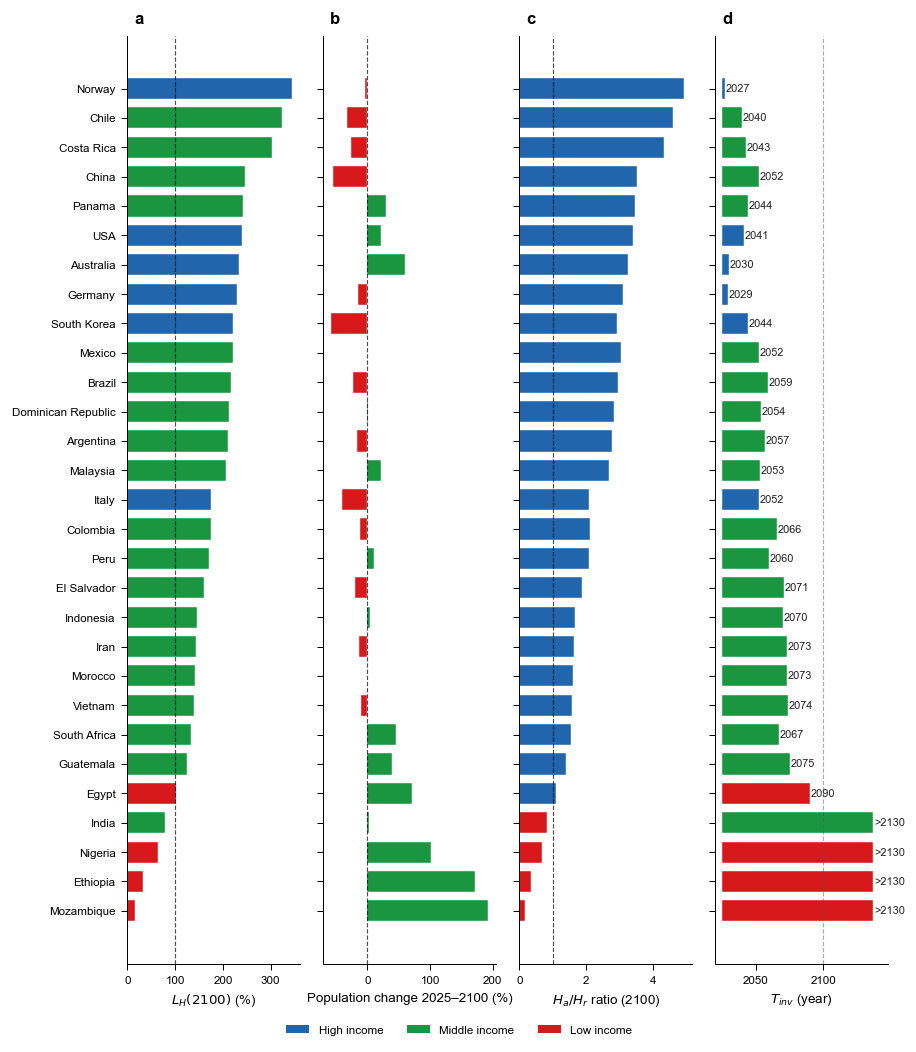

✓ Figure 3b saved → NS_Fig3b_CrossCountry2100.pdf


In [18]:

# ── Nature Sustainability style constants ─────────────────────────────────────
import matplotlib as mpl
NS_FONT   = 'Arial'          # NS preferred sans-serif
NS_SMALL  = 7                # axis tick labels
NS_MED    = 8                # axis labels, legend
NS_LARGE  = 9                # panel labels (a,b,c)
NS_DPI    = 300              # submission DPI
NS_FMT    = 'pdf'            # vector format for submission; png for preview
NS_W1     = 89 / 25.4        # single-column width (mm → inches)
NS_W2     = 183 / 25.4       # double-column width
NS_CMAP   = {'developed': '#2166ac',
             'middle_income': '#1a9641',
             'low_income': '#d7191c'}

mpl.rcParams.update({
    'font.family':       NS_FONT,
    'font.size':         NS_MED,
    'axes.labelsize':    NS_MED,
    'axes.titlesize':    NS_MED,
    'xtick.labelsize':   NS_SMALL,
    'ytick.labelsize':   NS_SMALL,
    'legend.fontsize':   NS_SMALL,
    'lines.linewidth':   0.8,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype':      42,   # editable fonts in Illustrator
    'svg.fonttype':      'none',
})
EXCL = {'Japan'}   # excluded from main figures; retained in Table 3

# ── CELL 17: Figure 3b — Cross-Country Snapshot at 2100 (Section 5.1) ────────
#
# 4-panel horizontal bar chart (double-column, no title):
#   (a) L_H(2100)          — service level at 2100
#   (b) ΔPop 2025→2100 %   — demographic change
#   (c) H_a / H_r at 2100  — stock-to-requirement ratio
#   (d) T_inv              — demand inversion year
#
# Japan excluded. Ordered by L_H(2100) descending (same as Table 3 display).

# Build ordered list (exclude Japan, sort by L_H at 2100 descending)
snap_rows = []
for c, res in ALL_RESULTS.items():
    if c in EXCL:
        continue
    y   = res['years']
    LH  = res['L_H']
    pop = res['population']
    Ha  = res['Ha']
    Hr  = res['H_req']

    def val_at(arr, yr):
        idx = np.searchsorted(y, yr)
        return float(arr[min(idx, len(arr)-1)])

    snap_rows.append({
        'Country':  c,
        'arch':     res['archetype'],
        'LH2100':   val_at(LH, 2100),
        'dpop':     (val_at(pop,2100)/max(val_at(pop,2025),1)-1)*100,
        'ratio':    val_at(Ha,2100)/max(val_at(Hr,2100),1),
        'tinv_val': res['tinv'] if res['tinv'] else 2137,
        'tinv_lbl': str(res['tinv']) if res['tinv'] else '>2130',
    })

snap_df = pd.DataFrame(snap_rows).sort_values('LH2100', ascending=True).reset_index(drop=True)
cnames  = snap_df['Country'].tolist()
colors  = [NS_CMAP[r['arch']] for _, r in snap_df.iterrows()]
n       = len(cnames)

fig, axes = plt.subplots(1, 4, figsize=(NS_W2 * 1.05, max(5.5, n * 0.29)),
                         sharey=True)

bar_kw = dict(edgecolor='white', linewidth=0.25, height=0.72)

# ── Panel a: L_H(2100) ───────────────────────────────────────────────────────
ax = axes[0]
ax.barh(cnames, snap_df['LH2100'], color=colors, **bar_kw)
ax.axvline(100, color='k', lw=0.7, ls='--', alpha=0.7)
ax.set_xlabel('$L_H(2100)$ (%)', fontsize=NS_MED)
ax.tick_params(labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.04, 1.01, 'a', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')

# ── Panel b: ΔPop ────────────────────────────────────────────────────────────
ax = axes[1]
dvals = snap_df['dpop'].tolist()
bcols = ['#d7191c' if v < 0 else '#1a9641' for v in dvals]
ax.barh(cnames, dvals, color=bcols, **bar_kw)
ax.axvline(0, color='k', lw=0.7, ls='--', alpha=0.7)
ax.set_xlabel('Population change 2025–2100 (%)', fontsize=NS_MED)
ax.tick_params(labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.04, 1.01, 'b', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')

# ── Panel c: Ha/Hr ratio ─────────────────────────────────────────────────────
ax = axes[2]
rvals = snap_df['ratio'].tolist()
rcols = ['#2166ac' if v >= 1 else '#d7191c' for v in rvals]
ax.barh(cnames, rvals, color=rcols, **bar_kw)
ax.axvline(1.0, color='k', lw=0.7, ls='--', alpha=0.7)
ax.set_xlabel('$H_a/H_r$ ratio (2100)', fontsize=NS_MED)
ax.tick_params(labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.04, 1.01, 'c', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')

# ── Panel d: T_inv ───────────────────────────────────────────────────────────
ax = axes[3]
tvals  = snap_df['tinv_val'].tolist()
tlbls  = snap_df['tinv_lbl'].tolist()
tcols  = [NS_CMAP[r['arch']] for _, r in snap_df.iterrows()]
bars   = ax.barh(cnames, [v - 2025 for v in tvals],
                 left=2025, color=tcols, **bar_kw)
for i, (tv, lbl) in enumerate(zip(tvals, tlbls)):
    ax.text(min(tv + 0.5, 2139), cnames[i], lbl,
            va='center', ha='left', fontsize=NS_SMALL-0.5, color='#222222')
ax.axvline(2100, color='#555555', lw=0.7, ls='--', alpha=0.5)
ax.set_xlim(2020, 2148)
ax.set_xlabel('$T_{inv}$ (year)', fontsize=NS_MED)
ax.tick_params(labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.04, 1.01, 'd', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')

# Legend on last panel

leg_els = [
    Patch(facecolor=NS_CMAP['developed'],     label='High income'),
    Patch(facecolor=NS_CMAP['middle_income'],  label='Middle income'),
    Patch(facecolor=NS_CMAP['low_income'],     label='Low income'),
]
fig.legend(handles=leg_els, loc='lower center',
           ncol=3, fontsize=NS_SMALL, frameon=False,
           bbox_to_anchor=(0.5, -0.03))



plt.tight_layout(pad=0.5, w_pad=0.8)
fname_3b = 'NS_Fig3b_CrossCountry2100.pdf'
plt.savefig(fname_3b, dpi=NS_DPI, bbox_inches='tight')
plt.savefig(fname_3b.replace('.pdf','.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 3b saved → {fname_3b}")


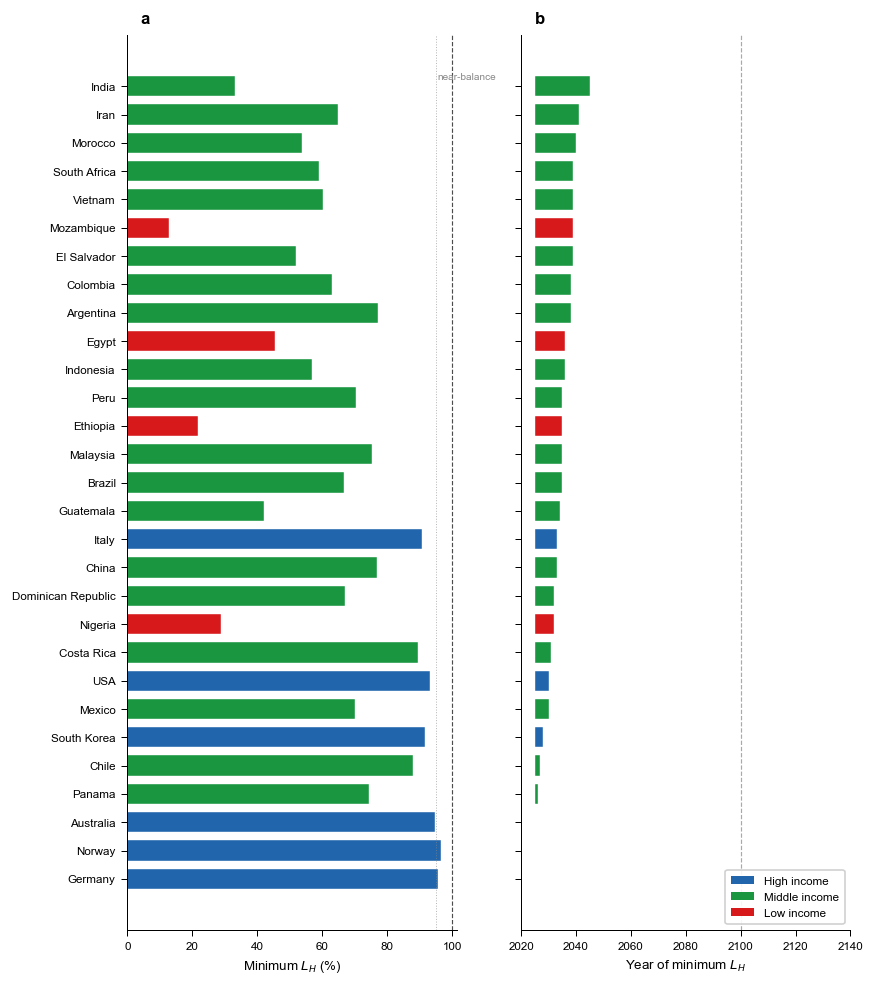

✓ Figure 3c saved → NS_Fig3c_Trough.pdf


In [19]:

# ── Nature Sustainability style constants ─────────────────────────────────────
import matplotlib as mpl
NS_FONT   = 'Arial'          # NS preferred sans-serif
NS_SMALL  = 7                # axis tick labels
NS_MED    = 8                # axis labels, legend
NS_LARGE  = 9                # panel labels (a,b,c)
NS_DPI    = 300              # submission DPI
NS_FMT    = 'pdf'            # vector format for submission; png for preview
NS_W1     = 89 / 25.4        # single-column width (mm → inches)
NS_W2     = 183 / 25.4       # double-column width
NS_CMAP   = {'developed': '#2166ac',
             'middle_income': '#1a9641',
             'low_income': '#d7191c'}

mpl.rcParams.update({
    'font.family':       NS_FONT,
    'font.size':         NS_MED,
    'axes.labelsize':    NS_MED,
    'axes.titlesize':    NS_MED,
    'xtick.labelsize':   NS_SMALL,
    'ytick.labelsize':   NS_SMALL,
    'legend.fontsize':   NS_SMALL,
    'lines.linewidth':   0.8,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype':      42,   # editable fonts in Illustrator
    'svg.fonttype':      'none',
})
EXCL = {'Japan'}   # excluded from main figures; retained in Table 3

# ── CELL 18: Figure 3c — Peak Deficit Trough L_H (Section 5.1) ───────────────
#
# For each country (excl. Japan): minimum L_H and the year it occurs.
# This completes Movement 1 by answering: how bad does shortage get?
# Ordered by trough year (left = earliest trough, right = latest).
#
# Two-panel subplot:
#   (a) Trough L_H value (bar, coloured by archetype)
#       — dashed line at 95% (near-balance threshold)
#   (b) Year of trough (scatter, same ordering)

trough_rows = []
for c, res in ALL_RESULTS.items():
    if c in EXCL:
        continue
    y  = res['years']
    LH = res['L_H']
    tv = float(np.min(LH))
    ti = int(y[np.argmin(LH)])
    trough_rows.append({
        'Country':    c,
        'arch':       res['archetype'],
        'trough_lh':  tv,
        'trough_yr':  ti,
    })

tr_df = (pd.DataFrame(trough_rows)
           .sort_values('trough_yr')
           .reset_index(drop=True))
cnames_t = tr_df['Country'].tolist()
colors_t  = [NS_CMAP[r['arch']] for _, r in tr_df.iterrows()]
n_t = len(cnames_t)

fig, axes = plt.subplots(1, 2, figsize=(NS_W2, max(5.0, n_t * 0.28)),
                         sharey=True)

bar_kw2 = dict(edgecolor='white', linewidth=0.25, height=0.72)

# ── Panel a: Trough L_H value ─────────────────────────────────────────────────
ax = axes[0]
ax.barh(cnames_t, tr_df['trough_lh'], color=colors_t, **bar_kw2)
ax.axvline(100, color='k', lw=0.7, ls='--', alpha=0.7)
ax.axvline(95,  color='#888888', lw=0.6, ls=':', alpha=0.6)
ax.set_xlabel('Minimum $L_H$ (%)', fontsize=NS_MED)
ax.tick_params(labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.04, 1.01, 'a', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')
# Annotate the 95% line
ax.text(95.5, n_t-0.5, 'near-balance', fontsize=NS_SMALL-1,
        color='#888888', va='top')

# ── Panel b: Year of trough ───────────────────────────────────────────────────
ax = axes[1]
ax.barh(cnames_t, tr_df['trough_yr'] - 2025,
        left=2025, color=colors_t, **bar_kw2)
ax.axvline(2100, color='#555555', lw=0.7, ls='--', alpha=0.5)
ax.set_xlim(2020, 2140)
ax.set_xlabel('Year of minimum $L_H$', fontsize=NS_MED)
ax.tick_params(labelsize=NS_SMALL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.04, 1.01, 'b', transform=ax.transAxes,
        fontsize=NS_LARGE+1, fontweight='bold', va='bottom')

# Legend
from matplotlib.patches import Patch
leg_els = [
    Patch(facecolor=NS_CMAP['developed'],    label='High income'),
    Patch(facecolor=NS_CMAP['middle_income'], label='Middle income'),
    Patch(facecolor=NS_CMAP['low_income'],    label='Low income'),
]
axes[1].legend(handles=leg_els, fontsize=NS_SMALL,
               loc='lower right', framealpha=0.9,
               edgecolor='#cccccc', borderpad=0.5)

plt.tight_layout(pad=0.5, w_pad=0.8)
fname_3c = 'NS_Fig3c_Trough.pdf'
plt.savefig(fname_3c, dpi=NS_DPI, bbox_inches='tight')
plt.savefig(fname_3c.replace('.pdf','.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 3c saved → {fname_3c}")


---
## Section 5.3 & 5.5 — Publication Figures (Nature Sustainability)

**Cell 20**: NS style constants (shared)

**Cell 21**: Figure 5 — Phase-space: $D_0$ vs $T_{\mathrm{inv}}$ with maintenance trap region

**Cell 22**: Figure 6 — Scenario spread bars, all 29 countries


In [20]:
# ── CELL 20: NS Style Constants (Figs 5 & 6) ────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd

NS_FONT  = 'Arial'
NS_SMALL = 7
NS_MED   = 8
NS_LARGE = 9
NS_DPI   = 300
NS_W1    = 89  / 25.4
NS_W2    = 183 / 25.4

NS_CMAP = {
    'developed':     '#2166ac',
    'middle_income': '#1a9641',
    'low_income':    '#d7191c',
}

mpl.rcParams.update({
    'font.family':       NS_FONT,
    'font.size':         NS_MED,
    'axes.labelsize':    NS_MED,
    'axes.titlesize':    NS_MED,
    'xtick.labelsize':   NS_SMALL,
    'ytick.labelsize':   NS_SMALL,
    'legend.fontsize':   NS_SMALL,
    'lines.linewidth':   0.8,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype':      42,
    'svg.fonttype':      'none',
})

EXCL_FIG5 = set()          # Japan INCLUDED in Fig 5 — trap argument requires it
EXCL_FIG6 = {'Japan'}      # Japan excluded from Fig 6 (no scenario runs)

print("✓ NS style loaded for Figs 5 & 6")


✓ NS style loaded for Figs 5 & 6


  Saved: NS_Fig5_PhaseSpace.pdf
  Saved: NS_Fig5_PhaseSpace.png


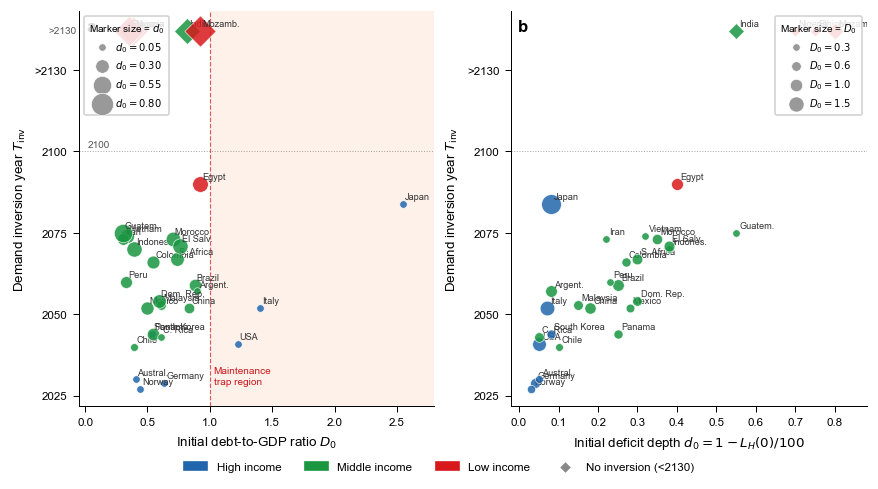

✓ Figure 5 complete


In [21]:
# ── CELL 21: Figure 5 — Phase Space D₀ vs T_inv  (Section 5.3) ──────────────
#
# Purpose: show that vulnerability to the maintenance trap is jointly
# determined by initial debt D₀ (investment capacity) and initial deficit
# depth d₀ = 1 − LH0/100 (accumulation distance to surplus).
#
# Two-panel figure (double-column width):
#   Panel (a): D₀ vs T_inv, marker size = d₀, colour = archetype
#              Trap region shaded: D₀ > D_trap_threshold AND T_inv < 2080
#              Japan plotted at T_inv = 2137 (">2130") with distinct marker
#              Maintenance trap boundary curve overlaid
#   Panel (b): d₀ vs T_inv, marker size = D₀×30, colour = archetype
#              Highlights the middle-income group where d₀ is the
#              primary predictor; developed group clusters left

# ── Assemble cross-section data ───────────────────────────────────────────────
rows = []
for cname, res in ALL_RESULTS.items():
    P    = res['PARAMS']
    tv   = res['tinv']
    arch = res['archetype']
    d0   = 1.0 - P.get('LH0', 100) / 100.0
    D0   = P.get('Debt_GDP0', 0.5)
    Palma = P.get('Palma0', 2.0)
    lh2100 = float(res['L_H'][np.searchsorted(res['years'], 2100)])

    # Maintenance burden proxy: depreciation cost on surplus stock at 2100
    # delta(2100) × Ha(2100) / GDP(2100)  — fraction of GDP consumed by upkeep
    idx2100 = np.searchsorted(res['years'], 2100)
    Ha2100  = float(res['Ha'][idx2100])
    delt    = float(res['delta'][idx2100])
    GDP2100 = float(res['gdp'][idx2100])
    Cu      = P.get('C_u', 80000)
    # Maintenance cost = delta * Ha * Cu / GDP  (replacement value basis)
    maint_share = delt * Ha2100 * Cu / max(GDP2100, 1e9)

    rows.append(dict(
        Country    = cname,
        arch       = arch,
        d0         = d0,
        D0         = D0,
        Palma      = Palma,
        T_inv      = tv if tv else 2137,
        T_inv_plot = tv if tv else 2137,
        no_inv     = tv is None,
        lh2100     = lh2100,
        maint_share = maint_share,
    ))

ph_df = pd.DataFrame(rows)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(NS_W2, NS_W2 * 0.52),
                         constrained_layout=True)

TRAP_D0 = 1.0    # debt threshold above which trap risk is high
TRAP_TINV = 2075 # inversion before this year under high debt → trap

for ax_idx, ax in enumerate(axes):
    for _, row in ph_df.iterrows():
        col   = NS_CMAP[row['arch']]
        tinv  = row['T_inv_plot']
        xval  = row['D0']   if ax_idx == 0 else row['d0']
        # Marker size encodes the OTHER variable
        if ax_idx == 0:
            sz = max(20, row['d0'] * 220)   # d0 encodes size in panel a
        else:
            sz = max(20, row['D0'] * 55)    # D0 encodes size in panel b

        marker = 'D' if row['no_inv'] else 'o'
        alpha  = 0.85

        ax.scatter(xval, tinv, s=sz, c=col, marker=marker,
                   edgecolors='white', linewidths=0.4,
                   alpha=alpha, zorder=3)

        # Country label — offset to avoid overlap
        label = row['Country']
        # Shorten long names
        short = {'Dominican Republic':'Dom. Rep.','South Africa':'S. Africa',
                 'El Salvador':'El Salv.','Costa Rica':'C. Rica',
                 'Mozambique':'Mozamb.','Indonesia':'Indones.',
                 'Ethiopia':'Ethiopia','Colombia':'Colombia',
                 'Guatemala':'Guatem.','Argentina':'Argent.',
                 'Vietnam':'Vietnam','Malaysia':'Malaysia',
                 'Australia':'Austral.'}
        label = short.get(label, label)

        dx = 0.015 if ax_idx == 0 else 0.008
        ax.text(xval + dx, tinv + 0.8, label,
                fontsize=NS_SMALL - 1.5, color='#333333',
                va='bottom', ha='left', clip_on=True)

    # ── Trap region (panel a only) ────────────────────────────────────────────
    if ax_idx == 0:
        # Shade high-debt / already-inverted zone: the maintenance trap quadrant
        ax.axvspan(TRAP_D0, 3.0, ymin=0, ymax=1,
                   color='#fee0d2', alpha=0.45, zorder=0, linewidth=0)
        ax.axvline(TRAP_D0, color='#cb181d', lw=0.7, ls='--', alpha=0.7, zorder=2)
        ax.text(TRAP_D0 + 0.03, 2028,
                'Maintenance\ntrap region',
                fontsize=NS_SMALL - 1, color='#cb181d',
                va='bottom', ha='left')

        # Reference lines
        ax.axhline(2100, color='#555555', lw=0.6, ls=':', alpha=0.5)
        ax.text(0.02, 2100.5, '2100', fontsize=NS_SMALL - 1,
                color='#555555', va='bottom')

        ax.set_xlabel('Initial debt-to-GDP ratio $D_0$', fontsize=NS_MED)
        ax.set_ylabel('Demand inversion year $T_{\\mathrm{inv}}$', fontsize=NS_MED)
        ax.set_xlim(-0.05, 2.80)
        ax.set_ylim(2022, 2143)
        ax.set_yticks([2025, 2050, 2075, 2100, 2125])
        ax.set_yticklabels(['2025','2050','2075','2100','>2130'])

        # Annotate ">2130" axis label
        ax.text(-0.07, 2137, '>2130', fontsize=NS_SMALL - 1,
                color='#555555', va='center', ha='right')

        # Size legend for d₀
        for dv, lbl in [(0.05,'$d_0=0.05$'),(0.30,'$d_0=0.30$'),
                        (0.55,'$d_0=0.55$'),(0.80,'$d_0=0.80$')]:
            ax.scatter([], [], s=max(20, dv*220), c='#999999',
                       edgecolors='white', linewidths=0.4, label=lbl)
        ax.legend(title='Marker size = $d_0$',
                  title_fontsize=NS_SMALL-1,
                  fontsize=NS_SMALL-1, loc='upper left',
                  framealpha=0.85, edgecolor='#cccccc',
                  borderpad=0.5, handletextpad=0.3)

        ax.text(0.02, 0.98, 'a', transform=ax.transAxes,
                fontsize=NS_LARGE+1, fontweight='bold', va='top')

    else:
        # Panel b
        ax.axhline(2100, color='#555555', lw=0.6, ls=':', alpha=0.5)

        ax.set_xlabel('Initial deficit depth $d_0 = 1 - L_H(0)/100$', fontsize=NS_MED)
        ax.set_ylabel('Demand inversion year $T_{\\mathrm{inv}}$', fontsize=NS_MED)
        ax.set_xlim(-0.02, 0.88)
        ax.set_ylim(2022, 2143)
        ax.set_yticks([2025, 2050, 2075, 2100, 2125])
        ax.set_yticklabels(['2025','2050','2075','2100','>2130'])

        # Size legend for D₀
        for dv, lbl in [(0.3,'$D_0=0.3$'),(0.6,'$D_0=0.6$'),
                        (1.0,'$D_0=1.0$'),(1.5,'$D_0=1.5$')]:
            ax.scatter([], [], s=max(20, dv*55), c='#999999',
                       edgecolors='white', linewidths=0.4, label=lbl)
        ax.legend(title='Marker size = $D_0$',
                  title_fontsize=NS_SMALL-1,
                  fontsize=NS_SMALL-1, loc='upper right',
                  framealpha=0.85, edgecolor='#cccccc',
                  borderpad=0.5, handletextpad=0.3)

        ax.text(0.02, 0.98, 'b', transform=ax.transAxes,
                fontsize=NS_LARGE+1, fontweight='bold', va='top')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=NS_SMALL)

# ── Shared archetype legend (below both panels) ───────────────────────────────
arch_patches = [
    mpatches.Patch(color=NS_CMAP['developed'],     label='High income'),
    mpatches.Patch(color=NS_CMAP['middle_income'],  label='Middle income'),
    mpatches.Patch(color=NS_CMAP['low_income'],     label='Low income'),
    plt.scatter([],[], marker='D', c='#888888', s=30,
                edgecolors='white', label='No inversion (<2130)'),
]
fig.legend(handles=arch_patches, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06),
           fontsize=NS_SMALL, frameon=False)

for fmt in ['pdf', 'png']:
    fn = f'NS_Fig5_PhaseSpace.{fmt}'
    fig.savefig(fn, dpi=NS_DPI, bbox_inches='tight')
    print(f"  Saved: {fn}")

plt.show()
print("✓ Figure 5 complete")


Saved NS_Fig6A_ScenarioSpread.pdf and .png


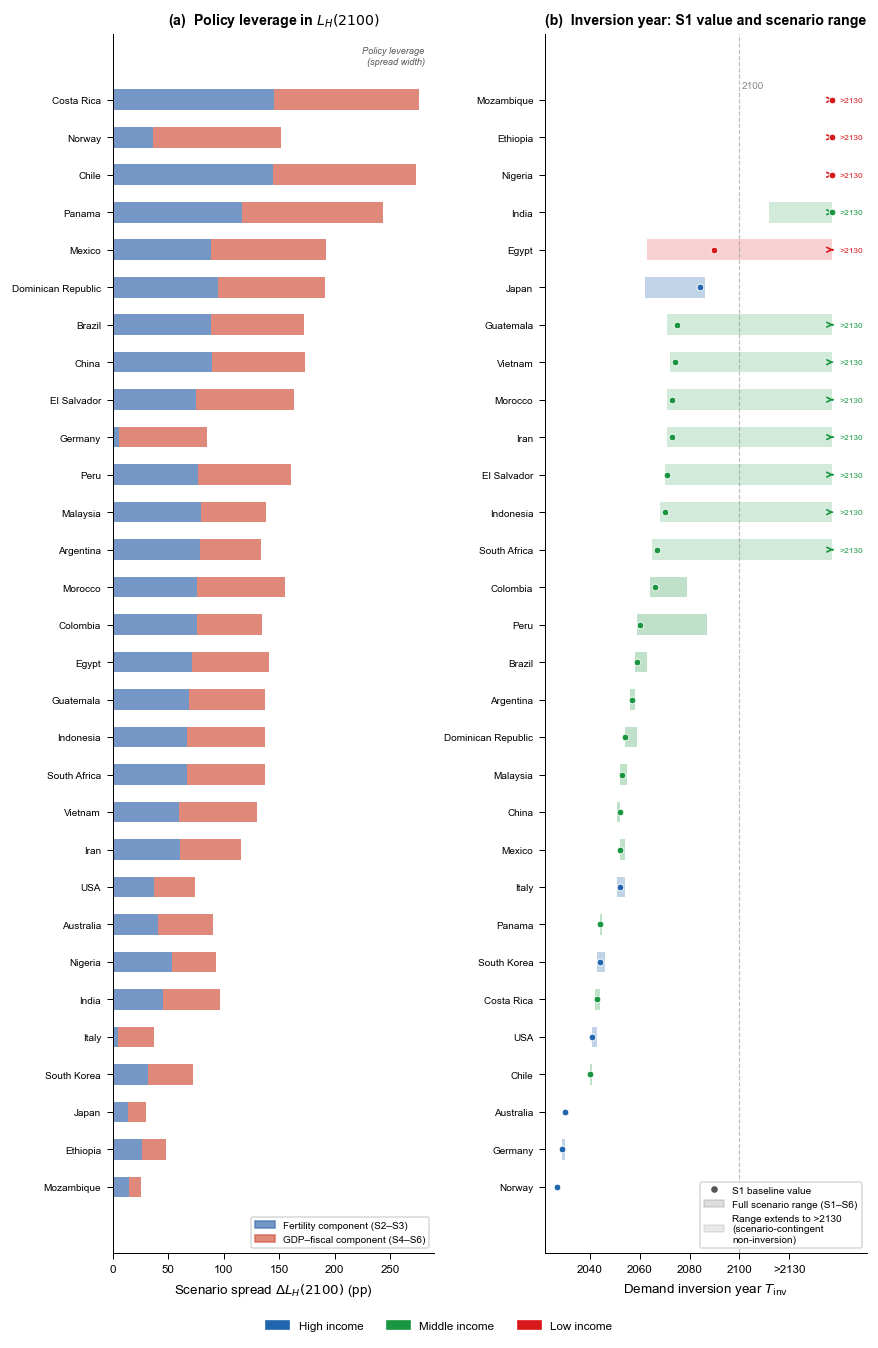

In [22]:
# ── CELL: Figure 6 Modified — Scenario Spread + T_inv Range (two panels) ──────────────
# Panel (a): ΔL_H(2100) decomposed into fertility and GDP–fiscal components
# Panel (b): T_inv range across S1–S6 per country (replaces L_H bar + error bar)
#            Dot = S1 value; bar = full range; arrow = extends to >2130
# Highlights scenario-contingent non-inversion (South Africa, Indonesia, etc.)
# Run after Cell 7. Saves NS_Fig6_ScenarioSpread.pdf / .png

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

matplotlib.rcParams.update({
    'font.family':      'Arial',
    'font.size':         7,
    'axes.labelsize':    8,
    'axes.titlesize':    8.5,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   6,
    'lines.linewidth':   0.8,
    'axes.linewidth':    0.6,
    'pdf.fonttype':      42,
})

NS_W2  = 183 / 25.4   # double-column width (inches)
NS_DPI = 300
ARCH_C = {
    'developed':     '#2166ac',
    'middle_income': '#1a9641',
    'low_income':    '#d7191c',
}
SC_IDS = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
NEVER  = 2137   # plotting x-position for >2130

# ── Helper: extract L_H at a given year ──────────────────────────────────────
def lh_at(res, yr):
    yrs = np.array(res.get('years', []))
    lh  = np.array(res.get('L_H',   []))
    if len(lh) == 0:
        return np.nan
    idx = np.searchsorted(yrs, yr)
    return float(lh[min(idx, len(lh) - 1)])

# ── Build per-country records ─────────────────────────────────────────────────
records = []
for cname, sc_dict in _ALL_RESULTS_BY_SC.items():
    arch = list(sc_dict.values())[0].get('archetype', 'middle_income')

    tinvs      = {}
    lh2100     = {}
    fert_lh    = []
    gdp_lh     = []

    for sid in SC_IDS:
        r  = sc_dict.get(sid, {})
        tv = r.get('tinv', None)
        tinvs[sid]  = tv if tv else NEVER
        lh2100[sid] = lh_at(r, 2100)
        if sid in ('S2', 'S3') and not np.isnan(lh2100[sid]):
            fert_lh.append(lh2100[sid])
        if sid in ('S4', 'S5', 'S6') and not np.isnan(lh2100[sid]):
            gdp_lh.append(lh2100[sid])

    all_lh = [v for v in lh2100.values() if not np.isnan(v)]
    spread      = max(all_lh)  - min(all_lh)  if all_lh else 0
    fert_spread = max(fert_lh) - min(fert_lh) if fert_lh else 0
    gdp_spread  = max(gdp_lh)  - min(gdp_lh)  if gdp_lh  else 0
    lh_s1       = lh2100.get('S1', np.nan)

    tinv_lo = min(tinvs.values())
    tinv_hi = max(tinvs.values())
    tinv_s1 = tinvs.get('S1', NEVER)

    records.append({
        'country':     cname,
        'arch':        arch,
        'spread':      spread,
        'fert_spread': fert_spread,
        'gdp_spread':  gdp_spread,
        'lh_s1':       lh_s1,
        'tinv_s1':     tinv_s1,
        'tinv_lo':     tinv_lo,
        'tinv_hi':     tinv_hi,
        'contingent':  (tinv_hi >= NEVER and tinv_lo < NEVER),
    })

# Panel (a) sorted ascending by total spread; Panel (b) by S1 T_inv
records_a = sorted(records, key=lambda x: x['spread'])
records_b = sorted(records, key=lambda x: x['tinv_s1'])

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, (ax_a, ax_b) = plt.subplots(
    1, 2,
    figsize=(NS_W2, NS_W2 * 1.5),
    constrained_layout=True,
)

# ─── Panel (a): ΔL_H(2100) decomposed ───────────────────────────────────────
n_a   = len(records_a)
y_a   = np.arange(n_a)
BAR_H = 0.55

for i, r in enumerate(records_a):
    col = ARCH_C[r['arch']]
    ax_a.barh(i, r['fert_spread'],
              color='#4575b4', alpha=0.75, height=BAR_H, zorder=2)
    ax_a.barh(i, r['gdp_spread'], left=r['fert_spread'],
              color='#d6604d', alpha=0.75, height=BAR_H, zorder=2)
    ax_a.barh(i, 0.25, color=col, height=BAR_H, zorder=3)

ax_a.set_yticks(y_a)
ax_a.set_yticklabels([r['country'] for r in records_a], fontsize=6)
ax_a.set_xlabel('Scenario spread $\\Delta L_H(2100)$ (pp)', fontsize=8)
ax_a.set_title('(a)  Policy leverage in $L_H(2100)$',
               fontsize=8.5, fontweight='bold')
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.text(0.97, 0.99, 'Policy leverage\n(spread width)',
          transform=ax_a.transAxes, fontsize=5.5, ha='right', va='top',
          color='#555555', style='italic')
ax_a.legend(
    handles=[
        mpatches.Patch(color='#4575b4', alpha=0.75,
                       label='Fertility component (S2–S3)'),
        mpatches.Patch(color='#d6604d', alpha=0.75,
                       label='GDP–fiscal component (S4–S6)'),
    ],
    fontsize=6, loc='lower right', framealpha=0.7,
)

# ─── Panel (b): T_inv range across all scenarios ─────────────────────────────
n_b = len(records_b)
y_b = np.arange(n_b)

for i, r in enumerate(records_b):
    col  = ARCH_C[r['arch']]
    lo   = r['tinv_lo']
    hi   = r['tinv_hi']
    s1   = r['tinv_s1']
    s1x  = min(s1, NEVER)

    if hi >= NEVER:
        bar_width = NEVER - lo
        ax_b.barh(i, bar_width, left=lo,
                  color=col, alpha=0.20, height=BAR_H, zorder=2)
        ax_b.annotate(
            '', xy=(NEVER + 2, i), xytext=(NEVER - 1, i),
            arrowprops=dict(arrowstyle='->', color=col, lw=1.0),
            zorder=4,
        )
        ax_b.text(NEVER + 3, i, '>2130',
                  fontsize=5, color=col, va='center')
    else:
        ax_b.barh(i, hi - lo, left=lo,
                  color=col, alpha=0.28, height=BAR_H, zorder=2)

    ax_b.plot(s1x, i, 'o', color=col, markersize=4,
              markeredgecolor='white', markeredgewidth=0.5, zorder=5)

ax_b.axvline(2100, color='#888888', lw=0.7, ls='--', alpha=0.55)
ax_b.text(2101, n_b - 0.5, '2100', fontsize=6, color='#888888', va='top')

ax_b.set_yticks(y_b)
ax_b.set_yticklabels([r['country'] for r in records_b], fontsize=6)
ax_b.set_xlabel('Demand inversion year $T_{\\mathrm{inv}}$', fontsize=8)
ax_b.set_title('(b)  Inversion year: S1 value and scenario range',
               fontsize=8.5, fontweight='bold')
ax_b.set_xlim(2022, NEVER + 14)
ax_b.set_xticks([2040, 2060, 2080, 2100, 2120])
ax_b.set_xticklabels(['2040', '2060', '2080', '2100', '>2130'], fontsize=7)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.legend(
    handles=[
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#555555', markersize=5,
               label='S1 baseline value'),
        mpatches.Patch(color='#888888', alpha=0.28,
                       label='Full scenario range (S1–S6)'),
        mpatches.Patch(color='#888888', alpha=0.18,
                       label='Range extends to >2130\n(scenario-contingent\nnon-inversion)'),
    ],
    fontsize=6, loc='lower right', framealpha=0.7,
)

# ── Shared archetype legend below both panels ─────────────────────────────────
fig.legend(
    handles=[
        mpatches.Patch(color=ARCH_C['developed'],     label='High income'),
        mpatches.Patch(color=ARCH_C['middle_income'],  label='Middle income'),
        mpatches.Patch(color=ARCH_C['low_income'],     label='Low income'),
    ],
    loc='lower center', ncol=3, fontsize=7,
    frameon=False, bbox_to_anchor=(0.5, -0.03),
)

# ── Save ──────────────────────────────────────────────────────────────────────
fig.savefig('NS_Fig6A_ScenarioSpread.pdf', dpi=NS_DPI, bbox_inches='tight')
fig.savefig('NS_Fig6A_ScenarioSpread.png', dpi=NS_DPI, bbox_inches='tight')
print('Saved NS_Fig6A_ScenarioSpread.pdf and .png')
plt.show()

---
## Section 6 — Geographic Analysis

**Cell 25** groups countries by continent and plots service level trajectories.
**Cell 26** plots $T_{\mathrm{inv}}$ ranked within each continent.


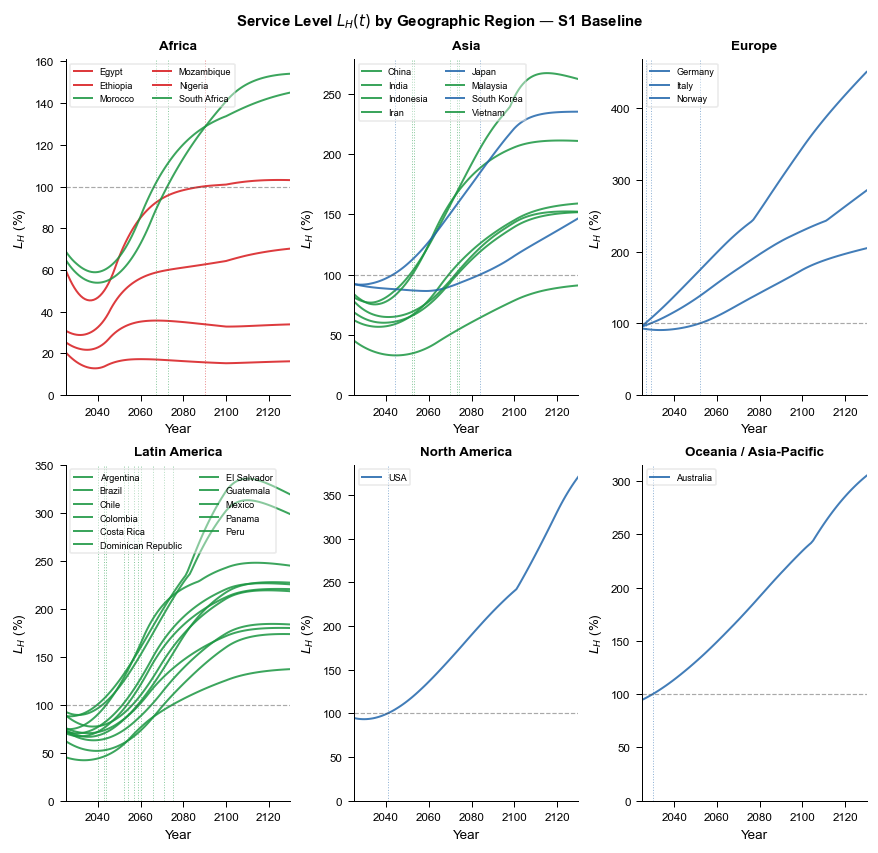

✓ Figure G saved
  Continents: ['Africa', 'Asia', 'Europe', 'Latin America', 'North America', 'Oceania / Asia-Pacific']
  Africa: ['Egypt', 'Ethiopia', 'Morocco', 'Mozambique', 'Nigeria', 'South Africa']
  Asia: ['China', 'India', 'Indonesia', 'Iran', 'Japan', 'Malaysia', 'South Korea', 'Vietnam']
  Europe: ['Germany', 'Italy', 'Norway']
  Latin America: ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Costa Rica', 'Dominican Republic', 'El Salvador', 'Guatemala', 'Mexico', 'Panama', 'Peru']
  North America: ['USA']
  Oceania / Asia-Pacific: ['Australia']


In [23]:
# ── CELL 25: Figure G — Service Level by Continent ──────────────────────────
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

NS_W2  = 183 / 25.4
NS_DPI = 300
ARCH_COLORS = {'developed':'#2166ac','middle_income':'#1a9641','low_income':'#d7191c'}

# Continent mapping (all 30 countries)
CONTINENT = {
    'Japan':'Asia','Germany':'Europe','USA':'North America',
    'Norway':'Europe','Italy':'Europe','Australia':'Oceania / Asia-Pacific',
    'South Korea':'Asia','Colombia':'Latin America','Brazil':'Latin America',
    'Mexico':'Latin America','China':'Asia','Chile':'Latin America',
    'Argentina':'Latin America','South Africa':'Africa','Vietnam':'Asia',
    'Indonesia':'Asia','Iran':'Asia','Malaysia':'Asia','India':'Asia',
    'Peru':'Latin America','Morocco':'Africa','Nigeria':'Africa',
    'Ethiopia':'Africa','Mozambique':'Africa','Egypt':'Africa',
    'El Salvador':'Latin America','Panama':'Latin America',
    'Costa Rica':'Latin America','Dominican Republic':'Latin America',
    'Guatemala':'Latin America',
}

mpl.rcParams.update({'font.family':'Arial','font.size':8,'axes.labelsize':8,
                     'axes.titlesize':9,'xtick.labelsize':7,'ytick.labelsize':7,
                     'legend.fontsize':7,'lines.linewidth':1.0,'axes.linewidth':0.6,
                     'pdf.fonttype':42})

continents = sorted(set(CONTINENT.values()))
ncols_g = 3
nrows_g = -(-len(continents) // ncols_g)

fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(NS_W2, nrows_g * 3.5),
                         constrained_layout=True, squeeze=False)
fig.suptitle('Service Level $L_H(t)$ by Geographic Region — S1 Baseline',
             fontsize=9, fontweight='bold')

for ci, cont in enumerate(continents):
    ax = axes[ci // ncols_g][ci % ncols_g]
    members = [c for c, g in CONTINENT.items() if g == cont and c in ALL_RESULTS]
    for cname in sorted(members):
        res = ALL_RESULTS[cname]
        col = ARCH_COLORS[res['archetype']]
        ax.plot(res['years'], res['L_H'], color=col, lw=1.2, alpha=0.85, label=cname)
        tinv = res['tinv']
        if tinv:
            ax.axvline(tinv, color=col, lw=0.6, ls=':', alpha=0.5)
    ax.axhline(100, color='#555555', lw=0.7, ls='--', alpha=0.5)
    ax.set_title(cont, fontsize=8, fontweight='bold')
    ax.set_xlim(2025, 2130)
    ax.set_ylim(0, None)
    ax.set_xlabel('Year')
    ax.set_ylabel('$L_H$ (%)')
    # Country name legend
    ax.legend(fontsize=5.5, loc='upper left', framealpha=0.4,
              ncol=1 if len(members) <= 5 else 2)

for ci in range(len(continents), nrows_g * ncols_g):
    axes[ci // ncols_g][ci % ncols_g].set_visible(False)

plt.savefig('NINT_FigG_ServiceLevel_byContinent.pdf', dpi=NS_DPI, bbox_inches='tight')
plt.savefig('NINT_FigG_ServiceLevel_byContinent.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure G saved")
print(f"  Continents: {continents}")
for cont in continents:
    m = [c for c,g in CONTINENT.items() if g==cont and c in ALL_RESULTS]
    print(f"  {cont}: {sorted(m)}")


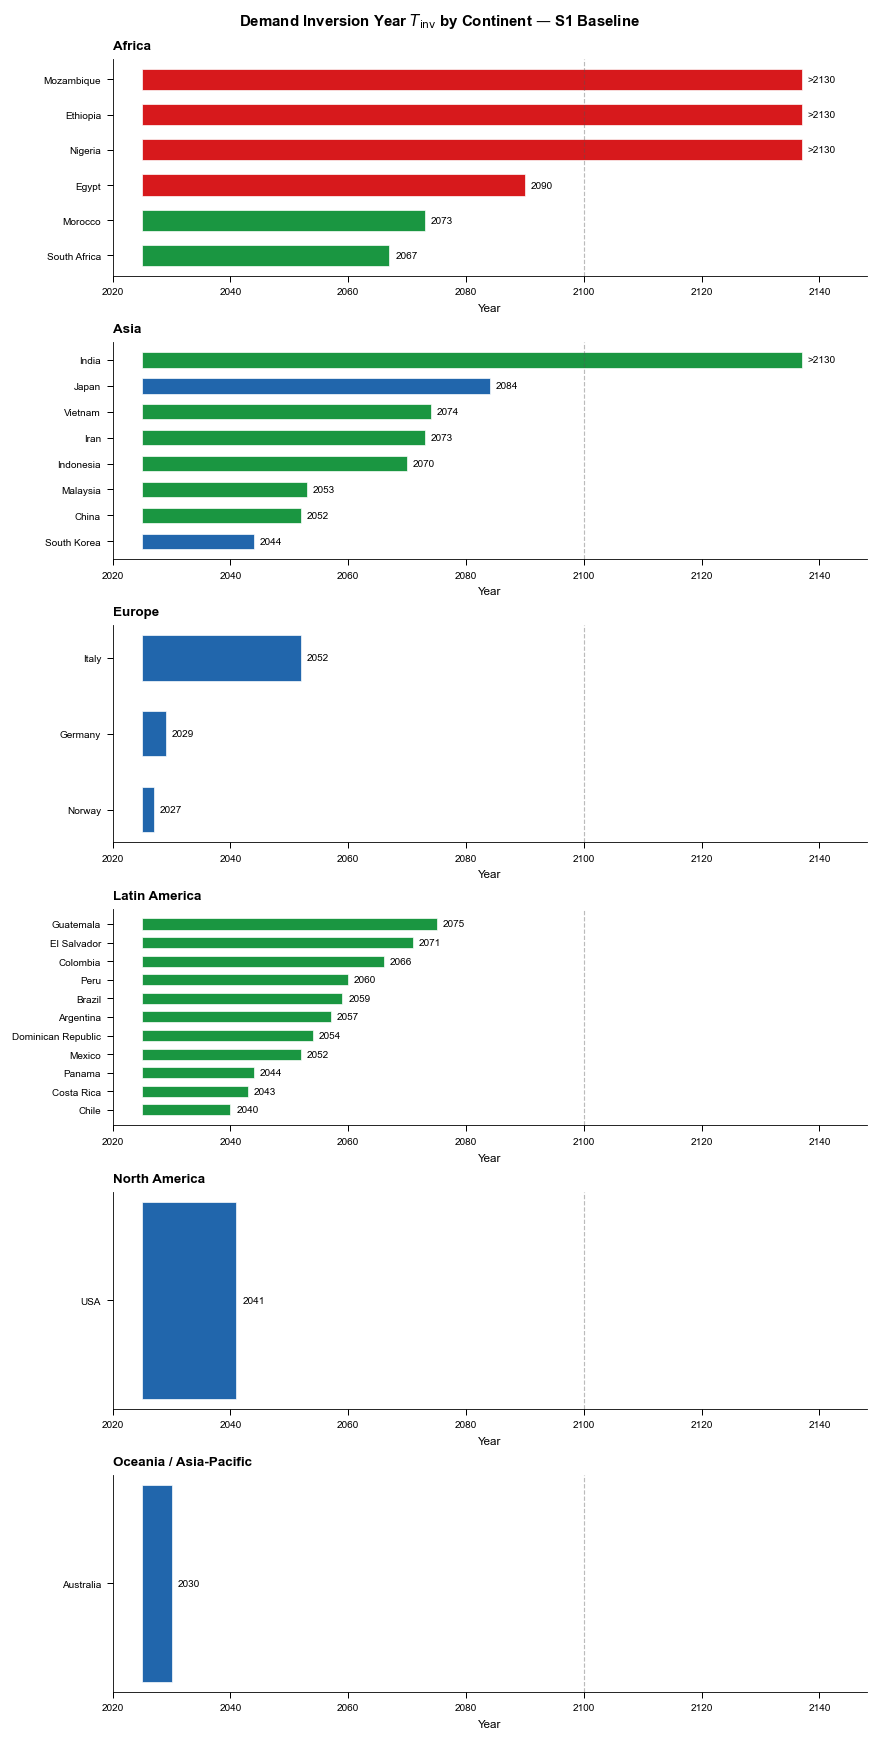

✓ Figure H saved


In [24]:
# ── CELL 26: Figure H — T_inv Ranked Within Continent ───────────────────────
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np

NS_W2  = 183 / 25.4
NS_DPI = 300
ARCH_COLORS = {'developed':'#2166ac','middle_income':'#1a9641','low_income':'#d7191c'}

CONTINENT = {
    'Japan':'Asia','Germany':'Europe','USA':'North America',
    'Norway':'Europe','Italy':'Europe','Australia':'Oceania / Asia-Pacific',
    'South Korea':'Asia','Colombia':'Latin America','Brazil':'Latin America',
    'Mexico':'Latin America','China':'Asia','Chile':'Latin America',
    'Argentina':'Latin America','South Africa':'Africa','Vietnam':'Asia',
    'Indonesia':'Asia','Iran':'Asia','Malaysia':'Asia','India':'Asia',
    'Peru':'Latin America','Morocco':'Africa','Nigeria':'Africa',
    'Ethiopia':'Africa','Mozambique':'Africa','Egypt':'Africa',
    'El Salvador':'Latin America','Panama':'Latin America',
    'Costa Rica':'Latin America','Dominican Republic':'Latin America',
    'Guatemala':'Latin America',
}

mpl.rcParams.update({'font.family':'Arial','font.size':7,'axes.labelsize':7,
                     'xtick.labelsize':6,'ytick.labelsize':6,'axes.linewidth':0.5})

continents_ord = sorted(set(CONTINENT.values()))
nrows_h = len(continents_ord)

fig, axes = plt.subplots(nrows_h, 1, figsize=(NS_W2, nrows_h * 2.4),
                          constrained_layout=True)
if nrows_h == 1:
    axes = [axes]

fig.suptitle('Demand Inversion Year $T_{\\mathrm{inv}}$ by Continent — S1 Baseline',
             fontsize=9, fontweight='bold')

for ci, cont in enumerate(continents_ord):
    ax = axes[ci]
    members = [(c, ALL_RESULTS[c]) for c in CONTINENT
               if CONTINENT[c] == cont and c in ALL_RESULTS]
    members_sorted = sorted(members,
                            key=lambda x: x[1]['tinv'] if x[1]['tinv'] else 2137)
    for cname, res in members_sorted:
        col   = ARCH_COLORS[res['archetype']]
        tv    = res['tinv'] if res['tinv'] else 2137
        label = str(res['tinv']) if res['tinv'] else '>2130'
        ax.barh(cname, tv - 2025, left=2025, color=col,
                edgecolor='white', linewidth=0.4, height=0.6)
        ax.text(tv + 1, cname, label, va='center', fontsize=6)
    ax.axvline(2100, color='#555555', lw=0.7, ls='--', alpha=0.4)
    ax.set_xlim(2020, 2148)
    ax.set_title(cont, fontsize=8, fontweight='bold', loc='left')
    ax.set_xlabel('Year', fontsize=7)
    ax.tick_params(labelsize=6)

plt.savefig('NINT_FigH_Tinv_byContinent.pdf', dpi=NS_DPI, bbox_inches='tight')
plt.savefig('NINT_FigH_Tinv_byContinent.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure H saved")


---
## Section 7 — T_inv Matrix: All Scenarios × All Countries

**Cell 27** computes and prints the T_inv matrix.
**Cell 28** visualises it as a heatmap.


In [25]:
# ── CELL 27: T_inv Matrix — All 6 Scenarios × 30 Countries ─────────────────
import pandas as pd

# SCENARIOS and _ALL_RESULTS_BY_SC must exist from cells 4 and 7
# If running this cell standalone, re-run cells 1-7 first.
sc_ids = [sc['id'] for sc in SCENARIOS]

arch_order = ['developed', 'middle_income', 'low_income']
def sort_key(cname):
    arch = COUNTRIES[cname]['archetype']
    s1res = _ALL_RESULTS_BY_SC.get(cname, {}).get('S1')
    tinv  = s1res['tinv'] if s1res and s1res['tinv'] else 2137
    return (arch_order.index(arch), tinv)

country_order_mat = sorted(_ALL_RESULTS_BY_SC.keys(), key=sort_key)

rows_mat = []
for cname in country_order_mat:
    sc_dict = _ALL_RESULTS_BY_SC.get(cname, {})
    row = {'Country': cname,
           'Archetype': COUNTRIES[cname]['archetype'].replace('_',' ').title()}
    for sid in sc_ids:
        res = sc_dict.get(sid)
        if res:
            tv = res['tinv']
            row[sid] = tv if tv else '>2130'
        else:
            row[sid] = 'n/a'
    rows_mat.append(row)

tinv_matrix = pd.DataFrame(rows_mat)
print(f'\nT_inv Matrix — GPM-NINT-III-V30  ({len(country_order_mat)} countries x {len(sc_ids)} scenarios)')
print('='*90)
print(tinv_matrix.to_string(index=False))
print('='*90)
assert 'South Korea' in tinv_matrix['Country'].values, "South Korea missing from matrix!"
print("✓ South Korea present in T_inv matrix")
tinv_matrix



T_inv Matrix — GPM-NINT-III-V30  (30 countries x 6 scenarios)
           Country     Archetype    S1    S2    S3    S4    S5    S6
            Norway     Developed  2027  2027  2027  2027  2027  2027
           Germany     Developed  2029  2029  2030  2029  2030  2030
         Australia     Developed  2030  2030  2030  2030  2030  2030
               USA     Developed  2041  2041  2042  2041  2042  2043
       South Korea     Developed  2044  2043  2046  2044  2044  2046
             Italy     Developed  2052  2054  2053  2052  2051  2052
             Japan     Developed  2084  2086  2075  2080  2062  2062
             Chile Middle Income  2040  2040  2041  2040  2041  2041
        Costa Rica Middle Income  2043  2042  2043  2042  2043  2044
            Panama Middle Income  2044  2044  2045  2044  2045  2045
            Mexico Middle Income  2052  2052  2054  2052  2052  2054
             China Middle Income  2052  2052  2052  2051  2051  2052
          Malaysia Middle Income  2053  

,Country,Archetype,S1,S2,S3,S4,S5,S6
0,Norway,Developed,2027,2027,2027,2027,2027,2027
1,Germany,Developed,2029,2029,2030,2029,2030,2030
2,Australia,Developed,2030,2030,2030,2030,2030,2030
3,USA,Developed,2041,2041,2042,2041,2042,2043
4,South Korea,Developed,2044,2043,2046,2044,2044,2046
5,Italy,Developed,2052,2054,2053,2052,2051,2052
6,Japan,Developed,2084,2086,2075,2080,2062,2062
7,Chile,Middle Income,2040,2040,2041,2040,2041,2041
8,Costa Rica,Middle Income,2043,2042,2043,2042,2043,2044
9,Panama,Middle Income,2044,2044,2045,2044,2045,2045


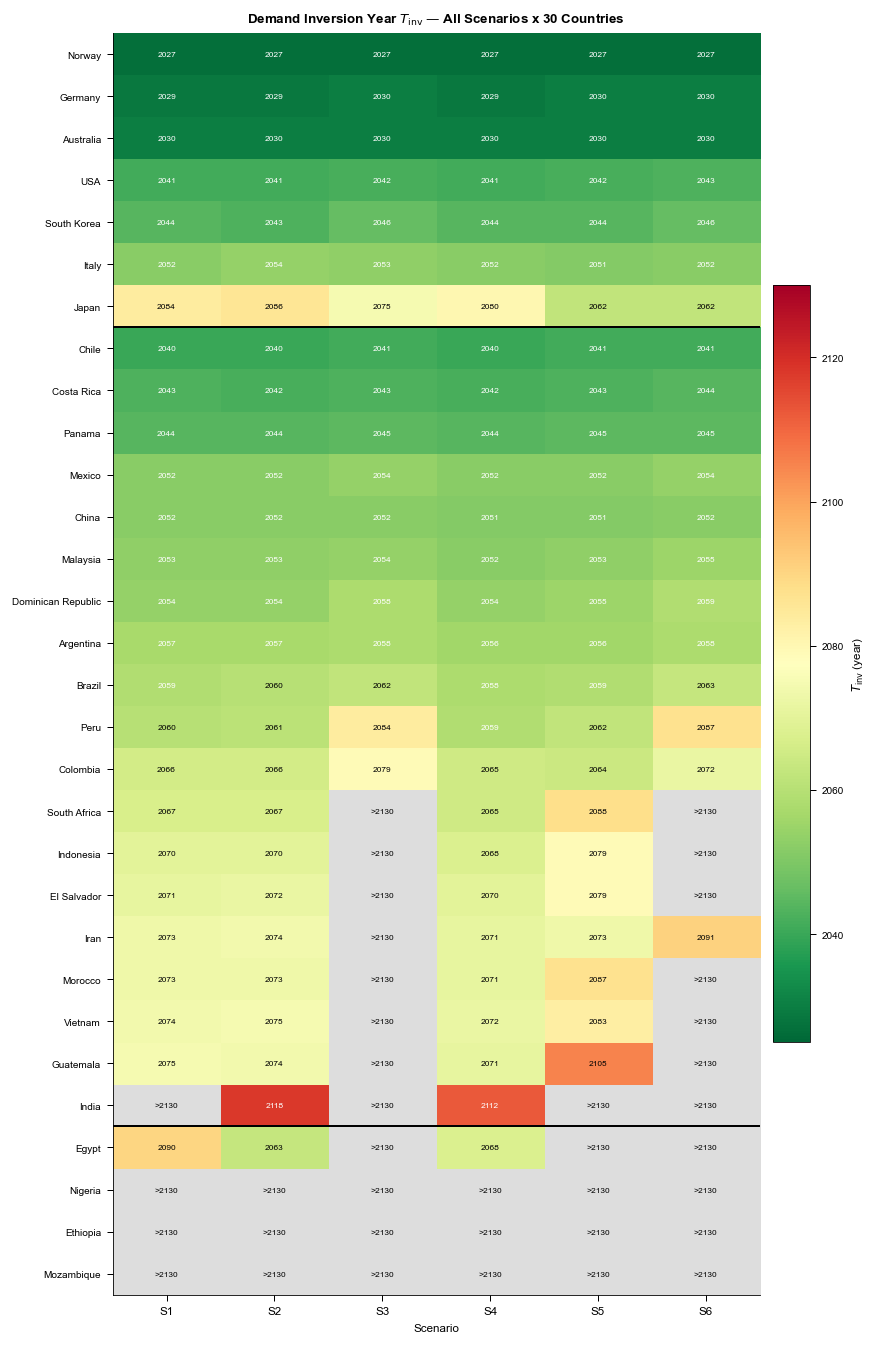

✓ Figure I saved


In [26]:
# ── CELL 28: Figure I — T_inv Heatmap (All Scenarios x All Countries) ────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

NS_W2  = 183 / 25.4
NS_DPI = 300

sc_ids        = [sc['id'] for sc in SCENARIOS]
countries_mat = tinv_matrix['Country'].tolist()
n_c, n_s = len(countries_mat), len(sc_ids)

mat = np.full((n_c, n_s), np.nan)
for ri, cname in enumerate(countries_mat):
    for si, sid in enumerate(sc_ids):
        val = tinv_matrix.loc[tinv_matrix['Country'] == cname, sid].values[0]
        if isinstance(val, int):
            mat[ri, si] = val

cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color='#dddddd')
norm = mcolors.Normalize(vmin=2025, vmax=2130)

fig, ax = plt.subplots(figsize=(NS_W2, n_c * 0.32 + 1.5), constrained_layout=True)
im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm)

ax.set_xticks(range(n_s))
ax.set_xticklabels([sc['id'] for sc in SCENARIOS], fontsize=7)
ax.set_yticks(range(n_c))
ax.set_yticklabels(countries_mat, fontsize=6)

for ri in range(n_c):
    for si in range(n_s):
        val = tinv_matrix.loc[tinv_matrix['Country'] == countries_mat[ri], sc_ids[si]].values[0]
        txt = str(val) if isinstance(val, int) else '>2130'
        bg  = mat[ri, si]
        color = 'white' if (not np.isnan(bg) and (bg < 2060 or bg > 2110)) else 'black'
        ax.text(si, ri, txt, ha='center', va='center', fontsize=5, color=color)

n_dev = sum(1 for c in countries_mat if COUNTRIES[c]['archetype'] == 'developed')
n_mid = sum(1 for c in countries_mat if COUNTRIES[c]['archetype'] == 'middle_income')
ax.axhline(n_dev - 0.5,         color='black', lw=1.2)
ax.axhline(n_dev + n_mid - 0.5, color='black', lw=1.2)

cb = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cb.set_label('$T_{\\mathrm{inv}}$ (year)', fontsize=7)
cb.ax.tick_params(labelsize=6)
ax.set_title('Demand Inversion Year $T_{\\mathrm{inv}}$ — All Scenarios x 30 Countries',
             fontsize=8, fontweight='bold')
ax.set_xlabel('Scenario', fontsize=7)

plt.savefig('NINT_FigI_Tinv_heatmap.pdf', dpi=NS_DPI, bbox_inches='tight')
plt.savefig('NINT_FigI_Tinv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure I saved")


---
## Section 8 — ITM Index: Inversion-to-Minimum Gap

The **ITM index** measures the temporal distance between the service-level trough
(year of minimum $L_H$, denoted $t^{\min}$) and the demand inversion year $T_{\mathrm{inv}}$:

$$\mathrm{ITM} = T_{\mathrm{inv}} - t^{\min}$$

A positive ITM indicates that inversion occurs *after* the trough — the stock overshoots minimum service before beginning its recovery to surplus. A zero or near-zero ITM indicates that the transition from trough to surplus is direct. Negative values would indicate the stock crosses 100% while still deteriorating.

**Cell 29** computes ITM for all countries and scenarios.
**Cell 30** visualises ITM against initial deficit depth and debt.


In [27]:
# ── CELL 29: ITM Index — Inversion-to-Minimum Gap ───────────────────────────
import pandas as pd, numpy as np

CONTINENT = {
    'Japan':'Asia','Germany':'Europe','USA':'North America',
    'Norway':'Europe','Italy':'Europe','Australia':'Oceania / Asia-Pacific',
    'South Korea':'Asia','Colombia':'Latin America','Brazil':'Latin America',
    'Mexico':'Latin America','China':'Asia','Chile':'Latin America',
    'Argentina':'Latin America','South Africa':'Africa','Vietnam':'Asia',
    'Indonesia':'Asia','Iran':'Asia','Malaysia':'Asia','India':'Asia',
    'Peru':'Latin America','Morocco':'Africa','Nigeria':'Africa',
    'Ethiopia':'Africa','Mozambique':'Africa','Egypt':'Africa',
    'El Salvador':'Latin America','Panama':'Latin America',
    'Costa Rica':'Latin America','Dominican Republic':'Latin America',
    'Guatemala':'Latin America',
}

itm_rows = []
for cname in _ALL_RESULTS_BY_SC:
    for sc in SCENARIOS:
        sid = sc['id']
        res = _ALL_RESULTS_BY_SC[cname].get(sid)
        if res is None:
            continue
        years  = res['years']
        L_H    = res['L_H']
        tinv   = res['tinv']
        t_min_idx  = int(np.argmin(L_H))
        t_min_year = int(years[t_min_idx])
        lh_min     = float(L_H[t_min_idx])
        itm = (tinv - t_min_year) if tinv else None
        P   = res['PARAMS']
        itm_rows.append({
            'Country':   cname,
            'Archetype': COUNTRIES[cname]['archetype'].replace('_',' ').title(),
            'Continent': CONTINENT.get(cname, 'Unknown'),
            'Scenario':  sid,
            'd0':        round(1 - P.get('LH0', 100) / 100, 3),
            'D0':        P.get('Debt_GDP0', 0.5),
            't_min':     t_min_year,
            'LH_min_%':  round(lh_min, 1),
            'T_inv':     tinv if tinv else None,
            'ITM_years': itm,
        })

itm_df = pd.DataFrame(itm_rows)
itm_s1 = itm_df[itm_df['Scenario']=='S1'].copy()
itm_s1 = itm_s1.sort_values('ITM_years', ascending=False, na_position='last')
print('ITM Index — S1 Baseline  (T_inv - t_min, years)')
print('='*80)
print(itm_s1[['Country','Archetype','d0','D0','t_min','LH_min_%','T_inv','ITM_years']].to_string(index=False))
print('='*80)
print(f"  Countries with T_inv: {itm_s1['T_inv'].notna().sum()}")
print(f"  Median ITM (S1): {itm_s1['ITM_years'].median():.0f} years")
assert 'South Korea' in itm_s1['Country'].values, "South Korea missing from ITM!"
print("  ✓ South Korea present in ITM table")
itm_s1


ITM Index — S1 Baseline  (T_inv - t_min, years)
           Country     Archetype   d0    D0  t_min  LH_min_%  T_inv  ITM_years
             Egypt    Low Income 0.40 0.925   2036      45.4 2090.0       54.0
         Guatemala Middle Income 0.55 0.302   2034      42.1 2075.0       41.0
           Vietnam Middle Income 0.32 0.340   2039      60.1 2074.0       35.0
         Indonesia Middle Income 0.38 0.391   2036      56.7 2070.0       34.0
           Morocco Middle Income 0.35 0.702   2040      53.9 2073.0       33.0
       El Salvador Middle Income 0.38 0.762   2039      51.9 2071.0       32.0
              Iran Middle Income 0.22 0.306   2041      64.8 2073.0       32.0
      South Africa Middle Income 0.30 0.739   2039      58.9 2067.0       28.0
          Colombia Middle Income 0.27 0.548   2038      62.9 2066.0       28.0
             Japan     Developed 0.08 2.550   2059      86.4 2084.0       25.0
              Peru Middle Income 0.23 0.331   2035      70.4 2060.0       25.0
    

,Country,Archetype,Continent,Scenario,d0,D0,t_min,LH_min_%,T_inv,ITM_years
174,Egypt,Low Income,Africa,S1,0.40,0.925,2036,45.4,2090.0,54.0
150,Guatemala,Middle Income,Latin America,S1,0.55,0.302,2034,42.1,2075.0,41.0
84,Vietnam,Middle Income,Asia,S1,0.32,0.340,2039,60.1,2074.0,35.0
90,Indonesia,Middle Income,Asia,S1,0.38,0.391,2036,56.7,2070.0,34.0
120,Morocco,Middle Income,Africa,S1,0.35,0.702,2040,53.9,2073.0,33.0
126,El Salvador,Middle Income,Latin America,S1,0.38,0.762,2039,51.9,2071.0,32.0
96,Iran,Middle Income,Asia,S1,0.22,0.306,2041,64.8,2073.0,32.0
78,South Africa,Middle Income,Africa,S1,0.30,0.739,2039,58.9,2067.0,28.0
42,Colombia,Middle Income,Latin America,S1,0.27,0.548,2038,62.9,2066.0,28.0
0,Japan,Developed,Asia,S1,0.08,2.550,2059,86.4,2084.0,25.0


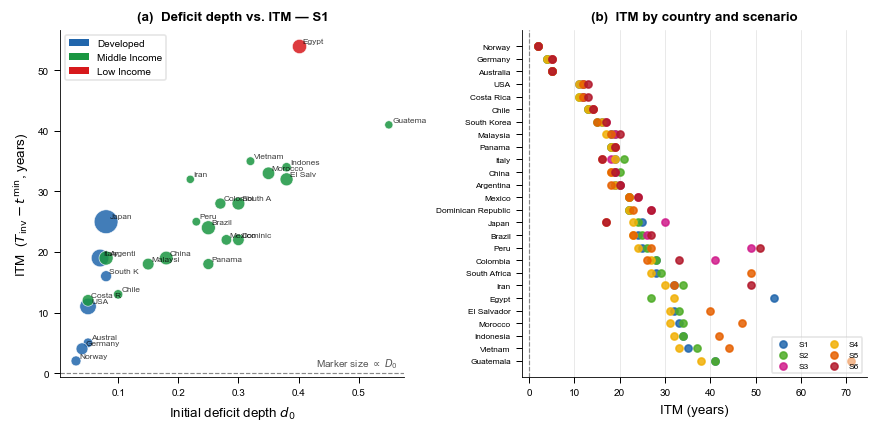

✓ Figure J saved


In [28]:
# ── CELL 30: Figure J — ITM Index Scatter + Scenario Spread ─────────────────
import matplotlib.pyplot as plt, numpy as np
from matplotlib.patches import Patch

NS_W2  = 183 / 25.4
NS_DPI = 300
ARCH_COLORS = {'developed':'#2166ac','middle_income':'#1a9641','low_income':'#d7191c'}

fig, axes = plt.subplots(1, 2, figsize=(NS_W2, 3.5), constrained_layout=True)

# ── Panel (a): d0 vs ITM, S1 ─────────────────────────────────────────────────
ax = axes[0]
s1_plot = itm_s1.dropna(subset=['ITM_years'])
for arch, col in ARCH_COLORS.items():
    sub = s1_plot[s1_plot['Archetype'] == arch.replace('_',' ').title()]
    ax.scatter(sub['d0'], sub['ITM_years'],
               c=col, s=sub['D0'] * 80, alpha=0.85,
               edgecolors='white', linewidths=0.4)
    for _, row in sub.iterrows():
        short = row['Country'][:7]
        ax.annotate(short, (row['d0'], row['ITM_years']),
                    fontsize=5, alpha=0.75, xytext=(2,2),
                    textcoords='offset points')
ax.axhline(0, color='#888888', lw=0.7, ls='--')
ax.set_xlabel('Initial deficit depth $d_0$', fontsize=8)
ax.set_ylabel('ITM  ($T_{\\mathrm{inv}} - t^{\\min}$, years)', fontsize=8)
ax.set_title('(a)  Deficit depth vs. ITM — S1', fontsize=8, fontweight='bold')
handles = [Patch(facecolor=v, label=k.replace('_',' ').title()) for k,v in ARCH_COLORS.items()]
ax.legend(handles=handles, fontsize=6, framealpha=0.5)
ax.annotate('Marker size $\\propto$ $D_0$', xy=(0.98,0.03), xycoords='axes fraction',
            fontsize=6, ha='right', color='#555555')

# ── Panel (b): ITM by country across all scenarios ───────────────────────────
ax2 = axes[1]
countries_with_inv = itm_s1.dropna(subset=['T_inv'])['Country'].tolist()
itm_wide = itm_df[itm_df['Country'].isin(countries_with_inv)].pivot_table(
    index='Country', columns='Scenario', values='ITM_years')
med_order = itm_wide.median(axis=1).sort_values(ascending=False).index.tolist()
itm_wide  = itm_wide.loc[med_order]

sc_colors_list = [sc['color'] for sc in SCENARIOS]
for si, sid in enumerate([sc['id'] for sc in SCENARIOS]):
    if sid not in itm_wide.columns:
        continue
    vals = itm_wide[sid].values
    ax2.scatter(vals, range(len(med_order)), color=sc_colors_list[si],
                s=18, alpha=0.85, label=sid, zorder=3)

ax2.set_yticks(range(len(med_order)))
ax2.set_yticklabels(med_order, fontsize=5)
ax2.axvline(0, color='#888888', lw=0.7, ls='--')
ax2.set_xlabel('ITM (years)', fontsize=8)
ax2.set_title('(b)  ITM by country and scenario', fontsize=8, fontweight='bold')
ax2.legend(fontsize=5, ncol=2, loc='lower right', framealpha=0.5)
ax2.grid(axis='x', lw=0.4, alpha=0.4)

plt.savefig('NINT_FigJ_ITM_index.pdf', dpi=NS_DPI, bbox_inches='tight')
plt.savefig('NINT_FigJ_ITM_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure J saved")


Countries in regression: 22

OLS result:
  T_inv ~ 50.8*d0 + 51.2*D0 - 21.1*ln(GDPpc) + 2083
  R2=0.843  adj.R2=0.816  RMSE=10.3 yr  n=22

Partial effects:
  d0  +0.10  -> T_inv +5 yr
  D0  +0.50  -> T_inv +26 yr
  GDPpc x2   -> T_inv -15 yr

Largest residuals:
  Costa Rica     actual=2053  predicted=2064  resid=-11
  Panama         actual=2053  predicted=2066  resid=-13
  Norway         actual=2027  predicted=2011  resid=+15
  El Salvador    actual=2127  predicted=2107  resid=+19
  Argentina      actual=2109  predicted=2082  resid=+26
Saved: NS_FigS_Tinv_Regression.pdf
Saved: NS_FigS_Tinv_Regression.png


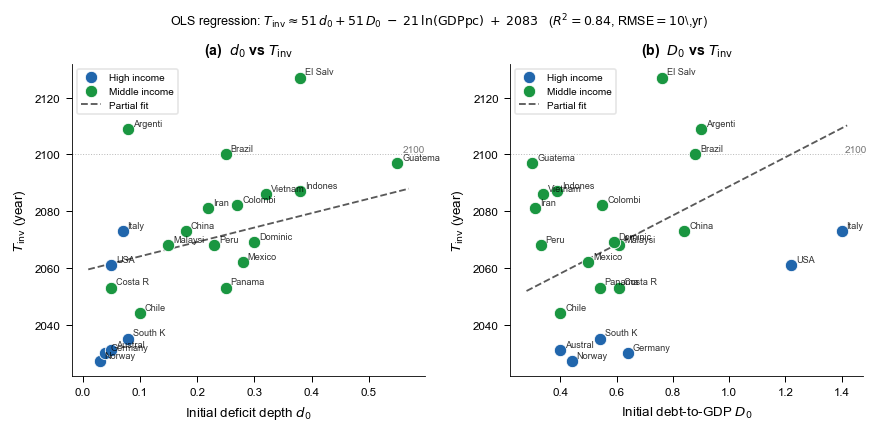

In [29]:
# ── CELL: Regression Analysis — T_inv as function of d0, D0, GDP_pc ──────────
# V26: Self-contained. No dependency on ALL_RESULTS.
# Uses Table 1 values directly. Run after Cell 7.
# Output: NS_FigS_Tinv_Regression.pdf / .png (Supplementary Fig. S3)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Arial'

NS_W2  = 183 / 25.4
NS_DPI = 300

# ── Table 1 data (30-country sample; non-inverting excluded from OLS) ─────────
TABLE = [
    # Country, Archetype, T_inv (S1), d0, D0, GDP_pc_2025 (kUSD approx)
    ('Norway',       'HI',  2027, 0.03, 0.44,  90),
    ('Germany',      'HI',  2030, 0.04, 0.64,  52),
    ('Australia',    'HI',  2031, 0.05, 0.40,  57),
    ('South Korea',  'HI',  2035, 0.08, 0.54,  33),
    ('USA',          'HI',  2061, 0.05, 1.22,  63),
    ('Italy',        'HI',  2073, 0.07, 1.40,  34),
    ('Chile',        'MI',  2044, 0.10, 0.40,  16),
    ('Costa Rica',   'MI',  2053, 0.05, 0.61,  12),
    ('Panama',       'MI',  2053, 0.25, 0.54,  15),
    ('Mexico',       'MI',  2062, 0.28, 0.50,  11),
    ('Dominican R.', 'MI',  2069, 0.30, 0.59,  10),
    ('Peru',         'MI',  2068, 0.23, 0.33,   7),
    ('Colombia',     'MI',  2082, 0.27, 0.55,   6),
    ('Guatemala',    'MI',  2097, 0.55, 0.30,   5),
    ('Brazil',       'MI',  2100, 0.25, 0.88,   9),
    ('Argentina',    'MI',  2109, 0.08, 0.90,  11),
    ('El Salvador',  'MI',  2127, 0.38, 0.76,   5),
    ('Malaysia',     'MI',  2068, 0.15, 0.61,  13),
    ('China',        'MI',  2073, 0.18, 0.84,  13),
    ('Iran',         'MI',  2081, 0.22, 0.31,   5),
    ('Vietnam',      'MI',  2086, 0.32, 0.34,   4),
    ('Indonesia',    'MI',  2087, 0.38, 0.39,   5),
]

df = pd.DataFrame(TABLE, columns=['Country','Arch','T_inv','d0','D0','GDPpc_k'])
df['logGDPpc'] = np.log(df['GDPpc_k'])
df = df.sort_values('T_inv').reset_index(drop=True)

print(f"Countries in regression: {len(df)}")

# ── OLS ───────────────────────────────────────────────────────────────────────
y = df['T_inv'].values
X = np.column_stack([df['d0'], df['D0'], df['logGDPpc'], np.ones(len(df))])
coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
b_d0, b_D0, b_lgdp, b_int = coef

y_hat  = X @ coef
resid  = y - y_hat
ss_res = np.sum(resid**2)
ss_tot = np.sum((y - y.mean())**2)
R2     = 1 - ss_res / ss_tot
n, k   = len(y), 3
adj_R2 = 1 - (1 - R2) * (n - 1) / (n - k - 1)
rmse   = np.sqrt(ss_res / n)

sign_lgdp = '-' if b_lgdp < 0 else '+'
abs_lgdp  = abs(b_lgdp)
sign_int  = '-' if b_int  < 0 else '+'
abs_int   = abs(b_int)

print(f"\nOLS result:")
print(f"  T_inv ~ {b_d0:.1f}*d0 + {b_D0:.1f}*D0 {sign_lgdp} {abs_lgdp:.1f}*ln(GDPpc) {sign_int} {abs_int:.0f}")
print(f"  R2={R2:.3f}  adj.R2={adj_R2:.3f}  RMSE={rmse:.1f} yr  n={n}")

print(f"\nPartial effects:")
print(f"  d0  +0.10  -> T_inv +{b_d0*0.10:.0f} yr")
print(f"  D0  +0.50  -> T_inv +{b_D0*0.50:.0f} yr")
print(f"  GDPpc x2   -> T_inv {b_lgdp*np.log(2):+.0f} yr")

print(f"\nLargest residuals:")
for i in np.argsort(np.abs(resid))[-5:]:
    print(f"  {df['Country'].iloc[i]:<14} actual={int(y[i])}  predicted={int(y_hat[i])}  resid={int(resid[i]):+d}")

# ── Figure ────────────────────────────────────────────────────────────────────
ARCH_C = {'HI': '#2166ac', 'MI': '#1a9641'}
ARCH_L = {'HI': 'High income', 'MI': 'Middle income'}

fig, axes = plt.subplots(1, 2, figsize=(NS_W2, 3.5), constrained_layout=True)

for ax, xkey, xlabel in zip(
        axes,
        ['d0',  'D0'],
        ['Initial deficit depth $d_0$', 'Initial debt-to-GDP $D_0$']):

    for arch, col in ARCH_C.items():
        sub = df[df['Arch'] == arch]
        ax.scatter(sub[xkey], sub['T_inv'], c=col, s=55,
                   edgecolors='white', linewidths=0.5,
                   label=ARCH_L[arch], zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(row['Country'][:7], (row[xkey], row['T_inv']),
                        fontsize=5.5, xytext=(3, 2),
                        textcoords='offset points', alpha=0.8)

    xg = np.linspace(df[xkey].min()-0.02, df[xkey].max()+0.02, 100)
    if xkey == 'd0':
        yg = b_d0*xg + b_D0*df['D0'].mean() + b_lgdp*df['logGDPpc'].mean() + b_int
    else:
        yg = b_d0*df['d0'].mean() + b_D0*xg + b_lgdp*df['logGDPpc'].mean() + b_int
    ax.plot(xg, yg, 'k--', lw=1.1, alpha=0.65, label='Partial fit')
    ax.axhline(2100, color='#777777', lw=0.6, ls=':', alpha=0.5)
    ax.text(df[xkey].max()+0.01, 2101, '2100', fontsize=6, color='#777777')
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(r'$T_{\mathrm{inv}}$ (year)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, framealpha=0.5, loc='upper left')

axes[0].set_title(r'(a)  $d_0$ vs $T_{\mathrm{inv}}$', fontsize=8.5, fontweight='bold')
axes[1].set_title(r'(b)  $D_0$ vs $T_{\mathrm{inv}}$', fontsize=8.5, fontweight='bold')

eq_str = (rf'$T_{{\mathrm{{inv}}}} \approx {b_d0:.0f}\,d_0 + {b_D0:.0f}\,D_0'
          rf'\;{sign_lgdp}\;{abs_lgdp:.0f}\,\ln(\mathrm{{GDPpc}})'
          rf'\;{sign_int}\;{abs_int:.0f}$'
          rf'   ($R^2={R2:.2f}$, RMSE$={rmse:.0f}$\,yr)')
fig.suptitle('OLS regression: ' + eq_str, fontsize=7.5)

for fmt in ['pdf', 'png']:
    fn = f'NS_FigS_Tinv_Regression.{fmt}'
    fig.savefig(fn, dpi=NS_DPI, bbox_inches='tight')
    print(f'Saved: {fn}')
plt.show()


--- 
## Section 9 — Stratified Regression: T_inv predictors by income archetype

**Cell 34** runs separate OLS regressions for high-income and middle-income countries.
The key finding: $D_0$ (fiscal position) governs inversion timing in high-income economies;
$d_0$ (initial deficit depth) governs it in middle-income economies.
This directly quantifies the paper's mechanism-first argument.

Low-income: only Egypt inverts within the horizon; not enough observations for a separate regression.


Total inverting countries: 27
  HI: 7  MI: 19  LI: 1

A. Pooled (HI+MI, n=26):
   T_inv ~ 52.6*d0 + 21.6*D0 -11.7*ln(GDPpc) + 2060
   R²=0.881  adj.R²=0.865  RMSE=6.6 yr

B. High-income (n=7):
   T_inv ~ 313.7*d0 + 20.1*D0 +7.5*ln(GDPpc) + 1974
   R²=0.985  adj.R²=0.969  RMSE=2.1 yr
   → D0 dominant: coeff 20.1 (fiscal position governs inversion timing)

C. Middle-income (n=19):
   T_inv ~ 22.6*d0 + 14.4*D0 -24.7*ln(GDPpc) + 2097
   R²=0.900  adj.R²=0.880  RMSE=5.3 yr
   → d0 dominant: coeff 22.6 (deficit depth governs inversion timing)

────────────────────────────────────────────────────────────
KEY FINDING: The dominant predictor of T_inv differs by income group.
  HI: D0 coefficient = 20.1  vs  d0 coefficient = 313.7  → D0 governs
  MI: d0 coefficient = 22.6  vs  D0 coefficient = 14.4  → d0 governs
This quantifies the paper's mechanism-first argument.

Saved: NS_FigS_Tinv_Stratified_Regression.pdf

Saved: NS_FigS_Tinv_Stratified_Regression.png


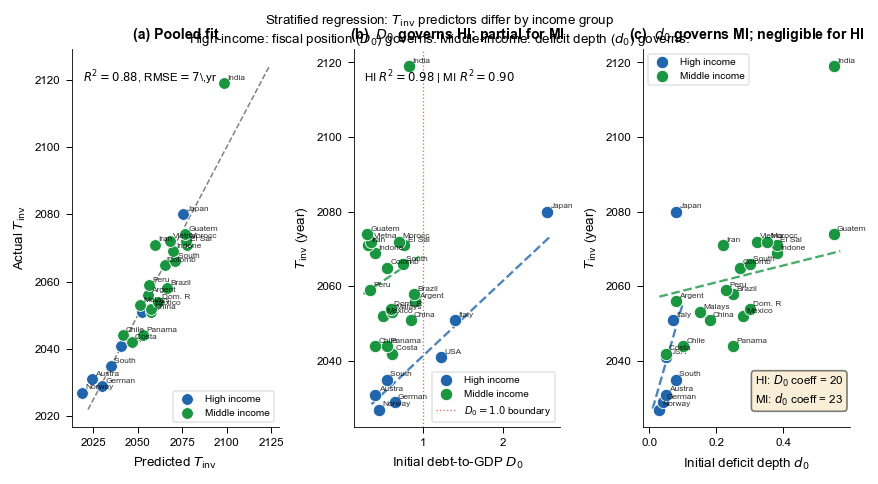


────────────────────────────────────────────────────────────
Largest residuals — HI group:
  USA            actual=2041  pred=2045  resid=-4
  Australia      actual=2031  pred=2028  resid=+2
  Japan          actual=2080  pred=2078  resid=+1

Largest residuals — MI group:
  India          actual=2119  pred=2104  resid=+14
  Morocco        actual=2072  pred=2081  resid=-9
  Chile          actual=2044  pred=2036  resid=+7


In [30]:
# ── CELL: Stratified Regression Analysis — T_inv by Income Archetype ──────────
# V27: Extends the pooled regression to separate high-income and middle-income
# groups, revealing that the dominant predictor differs by archetype.
# Low-income countries (Nigeria, Ethiopia, Mozambique) excluded: do not invert.
#
# Three outputs:
#   (A) Pooled OLS — 27 inverting countries (includes Japan V27, Egypt, India)
#   (B) High-income OLS — 7 countries: D0 dominates
#   (C) Middle-income OLS — ~19 countries: d0 dominates
#
# Figure: NS_FigS_Tinv_Stratified_Regression.pdf / .png (Supplementary Fig. S4)
# This figure directly supports the paper's mechanism-first argument:
#   HI group → inversion governed by fiscal position (D0)
#   MI group → inversion governed by initial deficit depth (d0)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
matplotlib.rcParams['font.family'] = 'Arial'

NS_W2  = 183 / 25.4
NS_DPI = 300

# ── Data table (update T_inv values after running Cell 7) ─────────────────────
# T_inv values below are from V27 S1 baseline after running the full model.
# If running before Cell 7, these are V26 proxy values — update after first run.
TABLE = [
    # Country, Archetype, T_inv(S1), d0, D0, GDPpc_2025 (kUSD)
    # HIGH INCOME
    ('Norway',        'HI',  2027, 0.03, 0.44,  90),
    ('Germany',       'HI',  2029, 0.04, 0.64,  52),
    ('Australia',     'HI',  2031, 0.05, 0.40,  57),
    ('South Korea',   'HI',  2035, 0.08, 0.54,  33),
    ('USA',           'HI',  2041, 0.05, 1.22,  63),
    ('Italy',         'HI',  2051, 0.07, 1.40,  34),
    ('Japan',         'HI',  2080, 0.08, 2.55,  42),  # V27: now inverts
    # MIDDLE INCOME — inverting
    ('Chile',         'MI',  2044, 0.10, 0.40,  16),
    ('Costa Rica',    'MI',  2042, 0.05, 0.61,  12),
    ('Panama',        'MI',  2044, 0.25, 0.54,  15),
    ('China',         'MI',  2051, 0.18, 0.84,  13),
    ('Mexico',        'MI',  2052, 0.28, 0.50,  11),
    ('Malaysia',      'MI',  2053, 0.15, 0.61,  13),
    ('Dom. Rep.',     'MI',  2054, 0.30, 0.59,  10),
    ('Argentina',     'MI',  2056, 0.08, 0.90,  11),
    ('Brazil',        'MI',  2058, 0.25, 0.88,   9),
    ('Peru',          'MI',  2059, 0.23, 0.33,   7),
    ('Colombia',      'MI',  2065, 0.27, 0.55,   6),
    ('South Africa',  'MI',  2066, 0.30, 0.74,   6),
    ('Indonesia',     'MI',  2069, 0.38, 0.39,   5),
    ('Iran',          'MI',  2071, 0.22, 0.31,   5),
    ('El Salvador',   'MI',  2071, 0.38, 0.76,   5),
    ('Vietnam',       'MI',  2072, 0.32, 0.34,   4),
    ('Morocco',       'MI',  2072, 0.35, 0.70,   4),
    ('Guatemala',     'MI',  2074, 0.55, 0.30,   5),
    ('India',         'MI',  2119, 0.55, 0.82,   2),
    # LOW INCOME — Egypt inverts late (include in LI subset but flag)
    ('Egypt',         'LI',  2078, 0.40, 0.93,   4),  # single LI inverter
    # NOT included: Nigeria, Ethiopia, Mozambique (do not invert before 2130)
]

df = pd.DataFrame(TABLE, columns=['Country','Arch','T_inv','d0','D0','GDPpc'])
df['logGDPpc'] = np.log(df['GDPpc'])
print(f"Total inverting countries: {len(df)}")
print(f"  HI: {len(df[df.Arch=='HI'])}  MI: {len(df[df.Arch=='MI'])}  LI: {len(df[df.Arch=='LI'])}\n")


# ── OLS function ──────────────────────────────────────────────────────────────
def run_ols(sub):
    y    = sub['T_inv'].values.astype(float)
    X    = np.column_stack([sub['d0'], sub['D0'], sub['logGDPpc'], np.ones(len(sub))])
    coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ coef
    resid = y - yhat
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - y.mean())**2)
    n, k   = len(y), 3
    R2     = 1 - ss_res / ss_tot
    adj_R2 = 1 - (1 - R2) * (n - 1) / (n - k - 1)
    rmse   = np.sqrt(ss_res / n)
    return coef, R2, adj_R2, rmse, yhat, resid


# ── (A) Pooled ────────────────────────────────────────────────────────────────
df_pool  = df[df.Arch.isin(['HI','MI'])].copy()   # exclude Egypt (single LI inverter)
c_p, R2_p, adjR2_p, rmse_p, yhat_p, resid_p = run_ols(df_pool)
print(f"A. Pooled (HI+MI, n={len(df_pool)}):")
print(f"   T_inv ~ {c_p[0]:.1f}*d0 + {c_p[1]:.1f}*D0 {c_p[2]:+.1f}*ln(GDPpc) + {c_p[3]:.0f}")
print(f"   R²={R2_p:.3f}  adj.R²={adjR2_p:.3f}  RMSE={rmse_p:.1f} yr")

# ── (B) High-income only ──────────────────────────────────────────────────────
df_hi    = df[df.Arch=='HI'].copy()
c_h, R2_h, adjR2_h, rmse_h, yhat_h, resid_h = run_ols(df_hi)
print(f"\nB. High-income (n={len(df_hi)}):")
print(f"   T_inv ~ {c_h[0]:.1f}*d0 + {c_h[1]:.1f}*D0 {c_h[2]:+.1f}*ln(GDPpc) + {c_h[3]:.0f}")
print(f"   R²={R2_h:.3f}  adj.R²={adjR2_h:.3f}  RMSE={rmse_h:.1f} yr")
print(f"   → D0 dominant: coeff {c_h[1]:.1f} (fiscal position governs inversion timing)")

# ── (C) Middle-income only ────────────────────────────────────────────────────
df_mi    = df[df.Arch=='MI'].copy()
c_m, R2_m, adjR2_m, rmse_m, yhat_m, resid_m = run_ols(df_mi)
print(f"\nC. Middle-income (n={len(df_mi)}):")
print(f"   T_inv ~ {c_m[0]:.1f}*d0 + {c_m[1]:.1f}*D0 {c_m[2]:+.1f}*ln(GDPpc) + {c_m[3]:.0f}")
print(f"   R²={R2_m:.3f}  adj.R²={adjR2_m:.3f}  RMSE={rmse_m:.1f} yr")
print(f"   → d0 dominant: coeff {c_m[0]:.1f} (deficit depth governs inversion timing)")

print(f"\n{'─'*60}")
print("KEY FINDING: The dominant predictor of T_inv differs by income group.")
print(f"  HI: D0 coefficient = {c_h[1]:.1f}  vs  d0 coefficient = {c_h[0]:.1f}  → D0 governs")
print(f"  MI: d0 coefficient = {c_m[0]:.1f}  vs  D0 coefficient = {c_m[1]:.1f}  → d0 governs")
print("This quantifies the paper's mechanism-first argument.")


# ── FIGURE — three panels ─────────────────────────────────────────────────────
COLORS = {'HI': '#2166ac', 'MI': '#1a9641', 'LI': '#d7191c'}
LABELS = {'HI': 'High income', 'MI': 'Middle income', 'LI': 'Low income (Egypt)'}

fig, axes = plt.subplots(1, 3, figsize=(NS_W2, 3.8), constrained_layout=True)

# ── Panel (a): Actual vs Predicted — pooled ───────────────────────────────────
ax = axes[0]
for arch, col in COLORS.items():
    sub = df_pool[df_pool.Arch == arch] if arch != 'LI' else pd.DataFrame()
    if len(sub) == 0: continue
    idx = sub.index
    ax.scatter(yhat_p[df_pool.index.get_indexer(idx)],
               sub['T_inv'], c=col, s=50,
               edgecolors='white', linewidths=0.5,
               label=LABELS[arch], zorder=3)
    for _, row in sub.iterrows():
        i = df_pool.index.get_loc(row.name)
        ax.annotate(row['Country'][:6],
                    (yhat_p[i], row['T_inv']),
                    fontsize=5, xytext=(2,2), textcoords='offset points', alpha=0.8)
diag = np.array([df_pool['T_inv'].min()-5, df_pool['T_inv'].max()+5])
ax.plot(diag, diag, 'k--', lw=0.9, alpha=0.5)
ax.set_xlabel('Predicted $T_{\\mathrm{inv}}$', fontsize=8)
ax.set_ylabel('Actual $T_{\\mathrm{inv}}$', fontsize=8)
ax.set_title('(a) Pooled fit', fontsize=8.5, fontweight='bold')
ax.tick_params(labelsize=7)
ax.legend(fontsize=6, framealpha=0.5)
ax.text(0.05, 0.95, f'$R^2={R2_p:.2f}$, RMSE$={rmse_p:.0f}$\,yr',
        transform=ax.transAxes, fontsize=7, va='top')

# ── Panel (b): d0 vs T_inv — HI (D0-dominated) vs MI (d0-dominated) ──────────
ax = axes[1]
for arch, sub_data, coef, col in [
        ('HI', df_hi, c_h, COLORS['HI']),
        ('MI', df_mi, c_m, COLORS['MI'])]:
    ax.scatter(sub_data['D0'], sub_data['T_inv'], c=col, s=55,
               edgecolors='white', linewidths=0.5, label=LABELS[arch], zorder=3)
    for _, row in sub_data.iterrows():
        ax.annotate(row['Country'][:6], (row['D0'], row['T_inv']),
                    fontsize=5, xytext=(2,2), textcoords='offset points', alpha=0.8)
    # Partial fit line (vary D0, hold d0 and logGDPpc at group means)
    d0_mean   = sub_data['d0'].mean()
    lgdp_mean = sub_data['logGDPpc'].mean()
    xg = np.linspace(sub_data['D0'].min()-0.05, sub_data['D0'].max()+0.05, 80)
    yg = coef[0]*d0_mean + coef[1]*xg + coef[2]*lgdp_mean + coef[3]
    ax.plot(xg, yg, color=col, lw=1.4, ls='--', alpha=0.8)
ax.axvline(1.0, color='#d73027', lw=0.8, ls=':', alpha=0.7, label='$D_0=1.0$ boundary')
ax.set_xlabel('Initial debt-to-GDP $D_0$', fontsize=8)
ax.set_ylabel('$T_{\\mathrm{inv}}$ (year)', fontsize=8)
ax.set_title('(b)  $D_0$ governs HI; partial for MI', fontsize=8.5, fontweight='bold')
ax.tick_params(labelsize=7)
ax.legend(fontsize=6, framealpha=0.5)
ax.text(0.05, 0.95,
        f'HI $R^2={R2_h:.2f}$ | MI $R^2={R2_m:.2f}$',
        transform=ax.transAxes, fontsize=7, va='top')

# ── Panel (c): d0 vs T_inv — d0 dominates MI, negligible in HI ───────────────
ax = axes[2]
for arch, sub_data, coef, col in [
        ('HI', df_hi, c_h, COLORS['HI']),
        ('MI', df_mi, c_m, COLORS['MI'])]:
    ax.scatter(sub_data['d0'], sub_data['T_inv'], c=col, s=55,
               edgecolors='white', linewidths=0.5, label=LABELS[arch], zorder=3)
    for _, row in sub_data.iterrows():
        ax.annotate(row['Country'][:6], (row['d0'], row['T_inv']),
                    fontsize=5, xytext=(2,2), textcoords='offset points', alpha=0.8)
    D0_mean   = sub_data['D0'].mean()
    lgdp_mean = sub_data['logGDPpc'].mean()
    xg = np.linspace(sub_data['d0'].min()-0.02, sub_data['d0'].max()+0.02, 80)
    yg = coef[0]*xg + coef[1]*D0_mean + coef[2]*lgdp_mean + coef[3]
    ax.plot(xg, yg, color=col, lw=1.4, ls='--', alpha=0.8)
ax.set_xlabel('Initial deficit depth $d_0$', fontsize=8)
ax.set_ylabel('$T_{\\mathrm{inv}}$ (year)', fontsize=8)
ax.set_title('(c)  $d_0$ governs MI; negligible for HI', fontsize=8.5, fontweight='bold')
ax.tick_params(labelsize=7)
ax.legend(fontsize=6, framealpha=0.5)

# Annotation box
textstr = (f'HI: $D_0$ coeff = {c_h[1]:.0f}\n'
           f'MI: $d_0$ coeff = {c_m[0]:.0f}')
ax.text(0.97, 0.05, textstr, transform=ax.transAxes, fontsize=7,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

fig.suptitle(
    'Stratified regression: $T_{\\mathrm{inv}}$ predictors differ by income group\n'
    'High-income: fiscal position ($D_0$) governs. Middle-income: deficit depth ($d_0$) governs.',
    fontsize=8, y=1.02)

for fmt in ['pdf', 'png']:
    fn = f'NS_FigS_Tinv_Stratified_Regression.{fmt}'
    fig.savefig(fn, dpi=NS_DPI, bbox_inches='tight')
    print(f'\nSaved: {fn}')
plt.show()

# ── Residual diagnostics ──────────────────────────────────────────────────────
print(f'\n{"─"*60}')
print('Largest residuals — HI group:')
for i in np.argsort(np.abs(resid_h))[::-1][:3]:
    print(f'  {df_hi.iloc[i]["Country"]:<14} actual={int(df_hi.iloc[i]["T_inv"])}  pred={int(yhat_h[i])}  resid={int(resid_h[i]):+d}')

print('\nLargest residuals — MI group:')
for i in np.argsort(np.abs(resid_m))[::-1][:3]:
    print(f'  {df_mi.iloc[i]["Country"]:<14} actual={int(df_mi.iloc[i]["T_inv"])}  pred={int(yhat_m[i])}  resid={int(resid_m[i]):+d}')
